In [355]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [356]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

#colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']
#colors = ["#FFD600", "#FF6D00", "#D50000", "#2962FF", "#AA00FF", "#C51162"]
colors = ["#00C853", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]
#colors = ['tab:green', 'tab:yellow', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
#colors = ["#4CAF50", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * stats.sem(values)

In [ ]:
# LIB: Significance Testing

significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    for _index, row in aov.iterrows():
        aov_str = "" + str(row["Source"]) + " & (" + str(row["ddof1"]) + ", " + str(row["ddof2"]) + ") & " + str(round(row["F"], 2)) + " & " 
        p_val = row[p_unc] if p_corr not in aov.columns or np.isnan(row[p_corr]) else row[p_corr]
        if row[significance_key] == "✅":
            aov_str += "\\textbf{" + str(round(p_val, 6)) + "}"
        else:
            aov_str += str(round(p_val, 6))
        aov_str+= " & " + str(round(row["ng2"], 4)) + " \\\\"
        print(aov_str)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

        for _index, row in valid_pairwise.iterrows():
            pairwise_str = "" + str(row["Contrast"]) + " " + str(row["B"]) + "-" + str(row["A"]) + " & " + str(int(row["dof"])) + " & " + str(round(row["T"] * -1, 2)) + " & "
            p_val = row[p_unc] if np.isnan(row[p_corr]) else row[p_corr]
            if row[significance_key] == "✅":
                pairwise_str += "\\textbf{" + str(round(p_val, 6)) + "}"
            else:
                pairwise_str += str(round(p_val, 6))
            pairwise_str+= " & " + str(round(row["hedges"] * -1, 4)) + " \\\\"
            print(pairwise_str)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def plot_significance_brackets(ax, ylim, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (ylim[1] - ylim[0]) / 10
    bracket_height = offset_step * 0.25
    barplot_height = np.max(barheights)
    current_height = barplot_height + offset_step * 0.5

    for bracket in brackets:
        left = bracket[0]
        right = bracket[1]
        p_value = bracket[2]

        if(p_value < 0.1):
            color = "black" if p_value < 0.05 else "gray"
            text = "+"
            if(p_value < 0.05): text = "*"
            if(p_value < 0.005): text = "**"
            if(p_value < 0.0005): text = "***"
            if(p_value < 0.00005): text = "****"

            left_x = n_bars[left]
            right_x = n_bars[right]

            bottom_y = current_height
            top_y = current_height + bracket_height

            bracket_pts_x = [left_x, left_x, right_x, right_x]
            bracket_pts_y = [bottom_y, top_y, top_y, bottom_y]

            bracket_center_x = (left_x + right_x) / 2

            ax.plot(bracket_pts_x, bracket_pts_y, c=color)
            ax.text(bracket_center_x, top_y, text, color=color, ha='center', va='bottom')

            current_height += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([ylim[0], np.max([current_height, ylim[1]])])

def plot_values(axs, idx, values, labels, scale, ylim, title, brackets, plot_colors):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    axs_first = axs[0, idx]
    axs_second = axs[1, idx]

    # Bar Plot
    axs_first.bar(labels, means, yerr=conf, capsize=6, color=plot_colors, edgecolor='black')
    axs_first.set_title(title)

    if scale is not None:
        yticks = range(scale[0], scale[1]+1)
        axs_first.set_yticks(yticks)
        axs_first.set_ylim(scale[0], scale[1])
        axs_second.set_yticks(yticks)
        yrange = scale[1]-scale[0]
        yrange_offset = yrange * 0.05
        axs_second.set_ylim([scale[0]-yrange_offset, scale[1]+yrange_offset])
    elif ylim is not None:
        axs_first.set_ylim(ylim)
        axs_second.set_ylim(ylim)

    #Box Plot
    boxplot = axs_second.boxplot(values, showfliers=True, widths=0.2)

    #Violin Plot
    n_bars = np.arange(len(labels))
    violin = axs_second.violinplot(values, showmeans=False, showextrema=False, showmedians=False)
    axs_second.set_xticks([y + 1 for y in n_bars], labels=labels)

    for idx, b in enumerate(violin['bodies']):
        # Get the center of the plot
        m = np.mean(b.get_paths()[0].vertices[:, 1])
        # Modify it so we only see the upper half of the violin plot
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], idx+1, idx+2)
        # Change to the desired color
        b.set_color(plot_colors[idx])

    #Scatter Plot
    for idx, features in enumerate(values):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .8)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
        x = out
        axs_second.scatter(x, features, c=plot_colors[idx], alpha=0.2)

    #Significance brackets
    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])
    plot_significance_brackets(axs_first, axs_first.get_ylim(), barheights, brackets)

def plot_experiment(df, e, key, title, scale, ylabel, ylim, two_way_tests, one_way_tests):
    fig, axs = plt.subplots(2, 3, figsize=(20, 8), width_ratios=[2, 3, 6])
    #fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for _index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, devices, scale, ylim, "Device", brackets=device_brackets, plot_colors=[colors[0], colors[3]])

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for _index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scalings, scale, ylim, "Scaling", brackets=scaling_brackets, plot_colors=[colors[0], colors[1], colors[2]])

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    # condition_brackets = []
    # for _index, row in one_way_tests.iterrows():
    #     a = condition_dict[row["A"]]
    #     b = condition_dict[row["B"]]
    #     p_value = row["p-corr"]
    #     if(np.isnan(p_value)):
    #         p_value = row["p-unc"]
    #     condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, conditions, scale, ylim, "Condition", brackets=[], plot_colors=colors)

    if ylabel is not None:
        axs[0][0].set_ylabel(ylabel)
        axs[1][0].set_ylabel(ylabel)

    # Adjust all ylims to match between columns
    for i in range(2): #Rows
        row = axs[i]

        minima = []
        maxima = []
        for j in range (3): #Columns
            ylim = row[j].get_ylim()
            minima.append(ylim[0])
            maxima.append(ylim[1])

        minimum = min(minima)
        maximum = max(maxima)

        for j in range (3): #Columns
            row[j].set_ylim([minimum, maximum])

    fig.tight_layout()
    plt.show()

def report_experiment_core(df, e, key, title, scale, ylabel, ylim):

    print('\033[1m' + "------ " + "["+e+"] " + title + " ------")

    #Descriptive statistics
    #device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    #scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    decimals = 2

    means_str = "Mean"
    # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), device_values))))
    # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), scaling_values))))
    means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), condition_values))))
    means_str += " \\\\"
    print(means_str)

    stddev_str = "Standard Deviation"
    # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), device_values))))
    # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), scaling_values))))
    stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), condition_values))))
    stddev_str += " \\\\"
    print(stddev_str)

    min_str = "Minimum"
    # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), device_values))))
    # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), scaling_values))))
    min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), condition_values))))
    min_str += " \\\\"
    print(min_str)

    max_str = "Maximum"
    # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), device_values))))
    # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), scaling_values))))
    max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), condition_values))))
    max_str += " \\\\"
    print(max_str)

    two_way_result = rm_anova(df, key, two_way=True)
    #one_way_result = rm_anova(df, key, two_way=False)

    two_way_sig_pairwise = get_semi_significant_entries(two_way_result[pairwise_key])
    #one_way_sig_pairwise = get_semi_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, scale, ylabel, ylim, two_way_sig_pairwise, None)

    return two_way_result

def get_eff_sizes_ttests(df, key):
    eff_sizes = []
    if not (df['Contrast'] == 'Device').any():
        eff_sizes.append(0) # Missing Device entry
    for _index, row in df.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[key] * -1) #Flip hedges effect size sign, since we flip comparison to be more intuitive when plotting
        else:
            eff_sizes.append(0)
    if not (df['Contrast'] == 'Scaling').any():
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry

    # Swap last and second last list element (better ordering for plotting)
    temp = eff_sizes[-2]
    eff_sizes[-2] = eff_sizes[-1]
    eff_sizes[-1] = temp

    return eff_sizes
    

def plot_splits_core(ax, splits_values, splits_labels, title, column_labels, column_colors, ylabel):
    width = 1 / (len(column_labels)+2)  # the width of the bars
    multiplier = 1
    x = np.arange(len(splits_labels))  # the label locations
    for i in range(len(column_labels)):
        values = list(map(lambda x: x[i], splits_values))
        offset = width * (multiplier + 0.5)
        ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
        multiplier += 1
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x + 0.5, splits_labels)
    ax.set_xlim([0, len(splits_labels)])

def report_comparison(splits, aovs, split_labels, title, ylabel):
    fig, axs = plt.subplots(1, 2, figsize=(20, 5), width_ratios=[2, 1])
    eff_size_labels = ["Device P-C", "Scaling 1-0", "Scaling 2-1", "Scaling 2-0"]
    eff_size_colors = [colors[3], colors[1], colors[2], colors[5]]
    eff_sizes = list(map(lambda x: get_eff_sizes_ttests(x[pairwise_key], "hedges"), aovs))

    plot_splits_core(axs[0], splits, split_labels, title, conditions, colors, ylabel)
    axs[0].legend(loc='upper left', ncols=6)
    plot_splits_core(axs[1], eff_sizes, split_labels, title + ' Effect Size', eff_size_labels, eff_size_colors, 'Hedges\' g')
    axs[1].legend(loc='upper left', ncols=4)

    # Make legend always fit
    for ax in axs:
        curr_ylim = ax.get_ylim()
        dist = curr_ylim[1]-curr_ylim[0]
        ax.set_ylim(curr_ylim[0], curr_ylim[1] + dist * 0.1)

    fig.tight_layout()
    plt.show()

In [358]:
# Notebook Defs

borg_cr = "How physically challenging was the experience?"
sp_fatigue = "How fatigued where you after the experience?"

general_1 = "I felt the weight of the object, while i was grabbing it"
general_2 = "The weight of the object, while i was grabbing it, felt realistic"
general_custom = [general_1, general_2]

shovel_1 = "I felt the weight of the shovel increasing when loading it"
shovel_2 = "I felt the weight of the shovel decreasing when unloading it"
shovel_3 = "After the shovel had been loaded, it required more effort to manipulate"
shovel_4 = "After the shovel had been unloaded, it required less effort to manipulate"
shovel_custom = [shovel_1, shovel_2, shovel_3, shovel_4]

fps_1 = "  My sense of being in the virtual world was like being in a real place."
fps_2 = "During the experience, I felt the virtual world was reality for me. "
fps_3 = "I felt like I was actually there in the virtual world. "
fps_4 = "I felt present in the virtual world. "
fps_5 = "I felt I could control my actions within the virtual world. "
fps_6 = "I felt the virtual world was responsive to my actions. "
fps_7 = "I felt I could move or manipulate objects easily in the virtual world. "
fps_8 = "I felt involved in the virtual world experience. "
fps_9 = "I could concentrate on the virtual activities rather than the controls to perform them. "
fps_10 = "When something happened to my virtual body, I felt it happened to my real body. "
fps = [fps_1, fps_2, fps_3, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9, fps_10]

relevant_keys = [condition_key, task, borg_cr, sp_fatigue] + general_custom + shovel_custom + fps

def get_df(name):
    path = './questionnaires/' + name + '.csv'
    df = pd.read_csv(path).filter(items=relevant_keys)

    df[device_key] = df[condition_key].str[0]
    df[scaling_key] = df[condition_key].str[1:]

    df.insert(0, 'No', range(0, 0 + len(df)))
    df[subject_key] = df.apply(lambda x: int(x['No'] / 12) + 1, axis=1)

    return df

def report_exeriment(data, e, key, title, scale):
    df = data[data[task] == e]
    return report_experiment_core(df, e, key, title, scale, None, None)

In [359]:
data = get_df('experiments')
data.tail(3)

,No,Condition,Task,How physically challenging was the experience?,How fatigued where you after the experience?,"I felt the weight of the object, while i was grabbing it","The weight of the object, while i was grabbing it, felt realistic",I felt the weight of the shovel increasing when loading it,I felt the weight of the shovel decreasing when unloading it,"After the shovel had been loaded, it required more effort to manipulate",...,I felt present in the virtual world.,I felt I could control my actions within the virtual world.,I felt the virtual world was responsive to my actions.,I felt I could move or manipulate objects easily in the virtual world.,I felt involved in the virtual world experience.,I could concentrate on the virtual activities rather than the controls to perform them.,"When something happened to my virtual body, I felt it happened to my real body.",Device,Scaling,Subject
501,501,C1,Shovel,1 - Very light,1 - Very alert and fully awake,2,1,1.0,1.0,2.0,...,5,5,5,3,4,3,3,C,1,42
502,502,C2,Shovel,1 - Very light,1 - Very alert and fully awake,3,1,1.0,1.0,1.0,...,5,4,5,3,4,2,3,C,2,42
503,503,P2,Shovel,1 - Very light,1 - Very alert and fully awake,7,7,2.0,2.0,2.0,...,5,5,3,6,4,7,3,P,2,42


------ [Cube] FPS Total Presence Score ------
Mean & 5.37 & 5.29 & 5.19 & 5.69 & 5.48 & 5.48 \\
Standard Deviation & 0.83 & 0.86 & 0.84 & 0.82 & 0.97 & 0.85 \\
Minimum & 3.2 & 3.0 & 3.3 & 3.6 & 2.7 & 3.3 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 6.8 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.426825,1,41,4.426825,14.084486,0.000542,0.000542,0.022965,1.000000,✅
1,Scaling,1.721667,2,82,0.860833,7.364458,0.001144,0.001338,0.009059,0.963042,✅
2,Device * Scaling,0.183889,2,82,0.091944,0.886704,0.415925,0.407850,0.000975,0.912055,❌


Device & (1, 41) & 14.08 & \textbf{0.000542} & 0.023 \\
Scaling & (2, 82) & 7.36 & \textbf{0.001338} & 0.0091 \\
Device * Scaling & (2, 82) & 0.89 & 0.40785 & 0.001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.752930,41.0,two-sided,0.000542,NaN,NaN,52.009,-0.315717,✅
1,Scaling,-,0,1,True,True,2.855850,41.0,two-sided,0.006708,0.013415,holm,5.647,0.171268,✅
2,Scaling,-,0,2,True,True,3.384854,41.0,two-sided,0.001579,0.004738,holm,20.04,0.240954,✅
3,Scaling,-,1,2,True,True,1.028305,41.0,two-sided,0.309835,0.309835,holm,0.273,0.060756,❌


Device P-C & 41 & 3.75 & \textbf{0.000542} & 0.3157 \\
Scaling 1-0 & 41 & -2.86 & \textbf{0.013415} & -0.1713 \\
Scaling 2-0 & 41 & -3.38 & \textbf{0.004738} & -0.241 \\
Scaling 2-1 & 41 & -1.03 & 0.309835 & -0.0608 \\


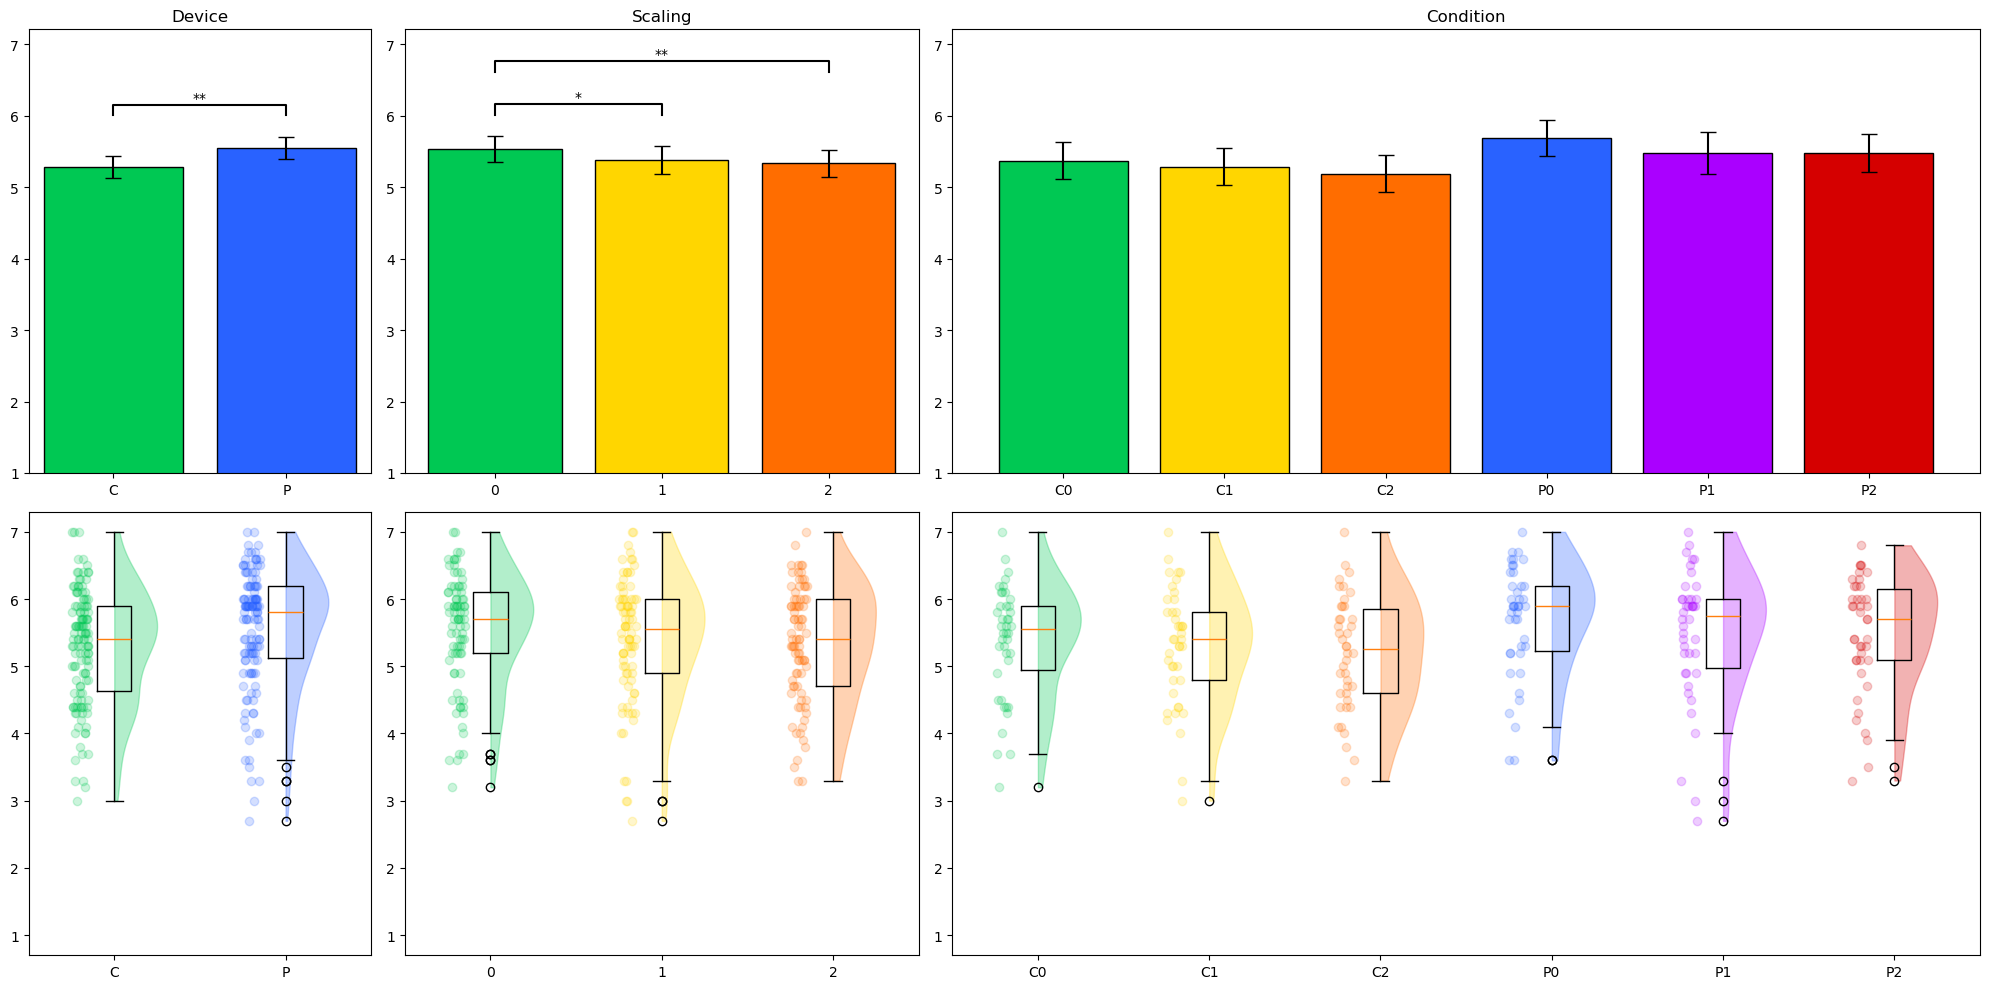

------ [Shovel] FPS Total Presence Score ------
Mean & 5.39 & 5.33 & 5.05 & 5.79 & 5.58 & 5.46 \\
Standard Deviation & 0.81 & 0.78 & 1.02 & 0.74 & 0.87 & 0.86 \\
Minimum & 3.2 & 3.7 & 3.1 & 4.2 & 3.2 & 3.6 \\
Maximum & 6.8 & 6.7 & 7.0 & 7.0 & 6.9 & 6.8 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.000040,1,41,8.000040,13.310875,0.000738,0.000738,0.041843,1.000000,✅
1,Scaling,4.818810,2,82,2.409405,9.571696,0.000184,0.000446,0.025631,0.849113,✅
2,Device * Scaling,0.341032,2,82,0.170516,0.758576,0.471591,0.471565,0.001858,0.999785,❌


Device & (1, 41) & 13.31 & \textbf{0.000738} & 0.0418 \\
Scaling & (2, 82) & 9.57 & \textbf{0.000446} & 0.0256 \\
Device * Scaling & (2, 82) & 0.76 & 0.471565 & 0.0019 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.648407,41.0,two-sided,0.000738,NaN,NaN,39.46,-0.461301,✅
1,Scaling,-,0,1,True,True,2.056606,41.0,two-sided,0.046125,0.074067,holm,1.119,0.197769,🟨
2,Scaling,-,0,2,True,True,4.781158,41.0,two-sided,0.000023,0.000068,holm,937.501,0.430108,✅
3,Scaling,-,1,2,True,True,2.155623,41.0,two-sided,0.037033,0.074067,holm,1.338,0.248632,🟨


Device P-C & 41 & 3.65 & \textbf{0.000738} & 0.4613 \\
Scaling 1-0 & 41 & -2.06 & 0.074067 & -0.1978 \\
Scaling 2-0 & 41 & -4.78 & \textbf{6.8e-05} & -0.4301 \\
Scaling 2-1 & 41 & -2.16 & 0.074067 & -0.2486 \\


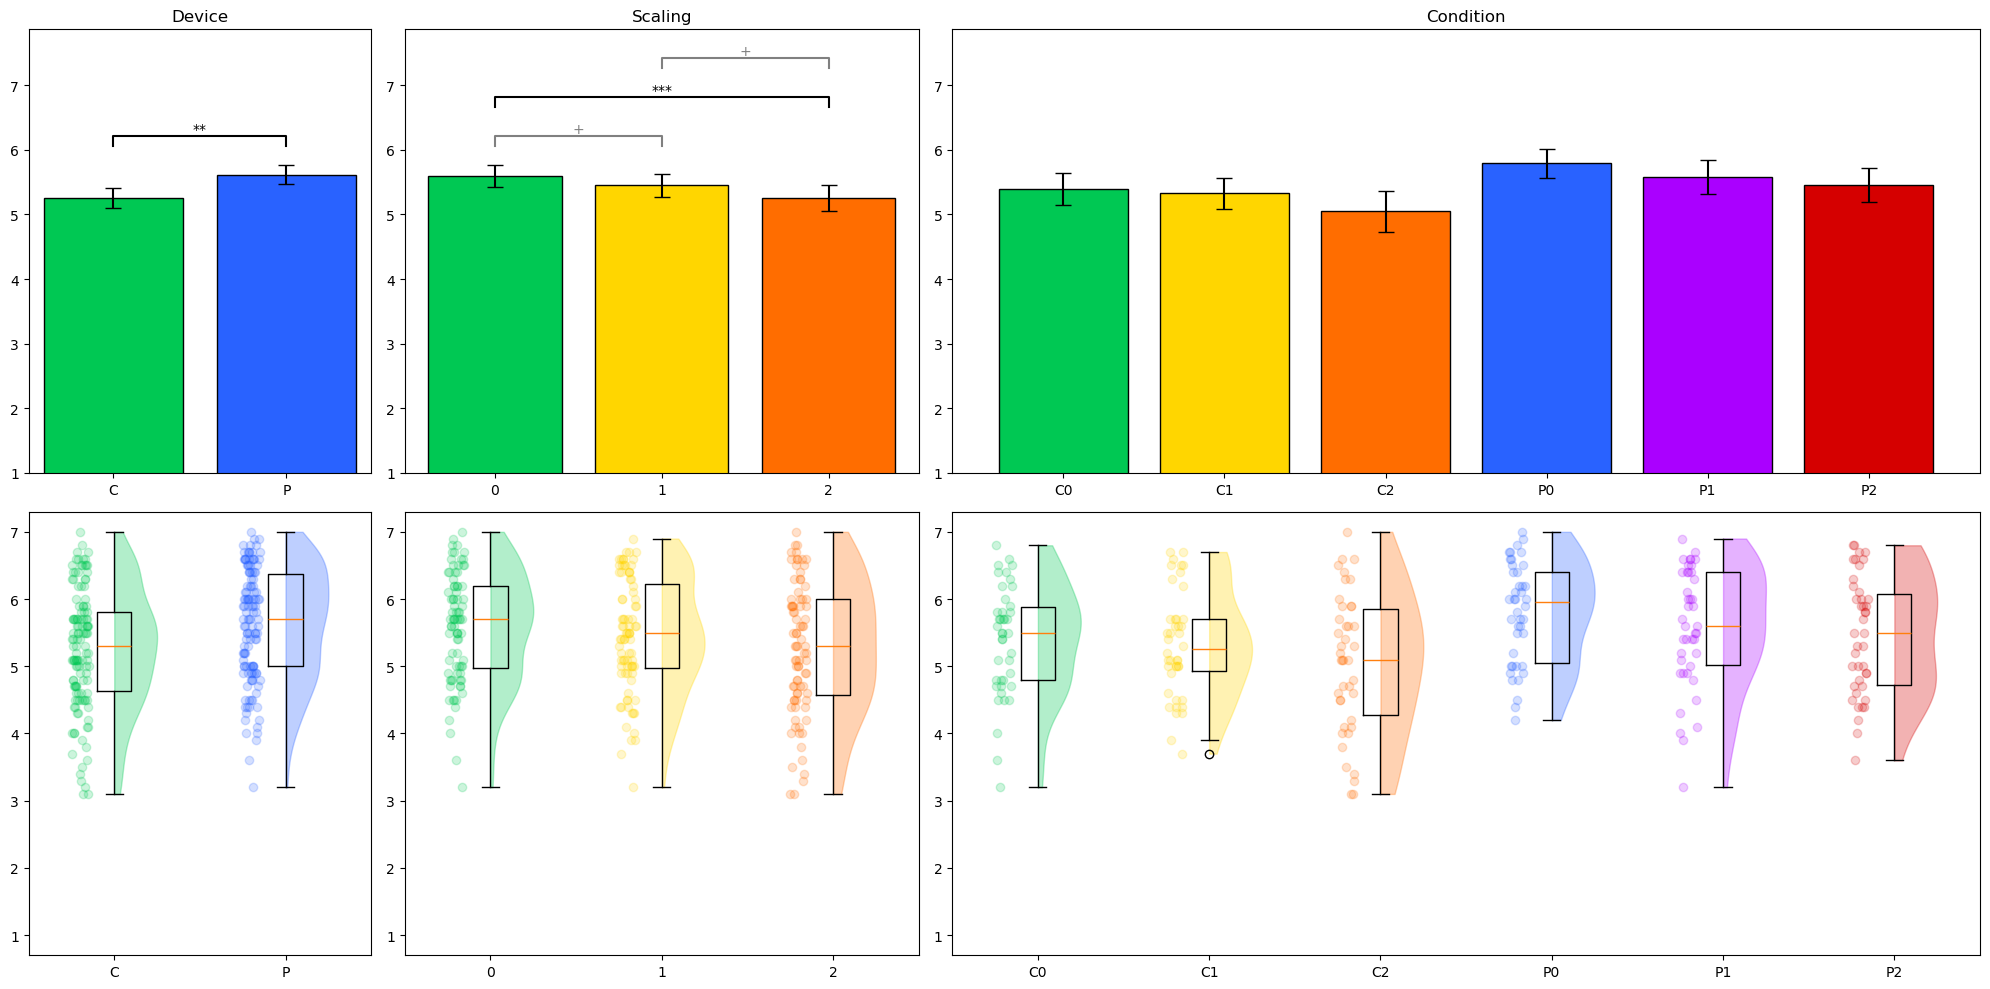

In [360]:
fps_total = 'fps_total'
#Total Presence Score: (FPS1-10) / 10
data[fps_total] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9] + x[fps_10]) / 10,
    axis = 1)

title = 'FPS Total Presence Score'
score = fps_total
scale = [1,7]
cube_fps_total = report_exeriment(data, cube, score, title, scale)
shovel_fps_total = report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Interaction Presence Score ------
Mean & 5.55 & 5.44 & 5.33 & 5.8 & 5.61 & 5.57 \\
Standard Deviation & 0.77 & 0.82 & 0.83 & 0.79 & 0.95 & 0.8 \\
Minimum & 3.38 & 3.25 & 3.5 & 3.62 & 2.75 & 3.75 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 6.88 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.055804,1,41,3.055804,9.148981,0.004282,0.004282,0.017454,1.000000,✅
1,Scaling,2.226314,2,82,1.113157,8.588649,0.000411,0.000470,0.012777,0.973888,✅
2,Device * Scaling,0.091890,2,82,0.045945,0.444771,0.642508,0.611625,0.000534,0.853719,❌


Device & (1, 41) & 9.15 & \textbf{0.004282} & 0.0175 \\
Scaling & (2, 82) & 8.59 & \textbf{0.00047} & 0.0128 \\
Device * Scaling & (2, 82) & 0.44 & 0.611625 & 0.0005 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.024728,41.0,two-sided,0.004282,NaN,NaN,8.337,-0.276774,✅
1,Scaling,-,0,1,True,True,2.922249,41.0,two-sided,0.005631,0.011263,holm,6.57,0.188613,✅
2,Scaling,-,0,2,True,True,3.812223,41.0,two-sided,0.000455,0.001364,holm,60.935,0.297352,✅
3,Scaling,-,1,2,True,True,1.364829,41.0,two-sided,0.179751,0.179751,holm,0.394,0.094289,❌


Device P-C & 41 & 3.02 & \textbf{0.004282} & 0.2768 \\
Scaling 1-0 & 41 & -2.92 & \textbf{0.011263} & -0.1886 \\
Scaling 2-0 & 41 & -3.81 & \textbf{0.001364} & -0.2974 \\
Scaling 2-1 & 41 & -1.36 & 0.179751 & -0.0943 \\


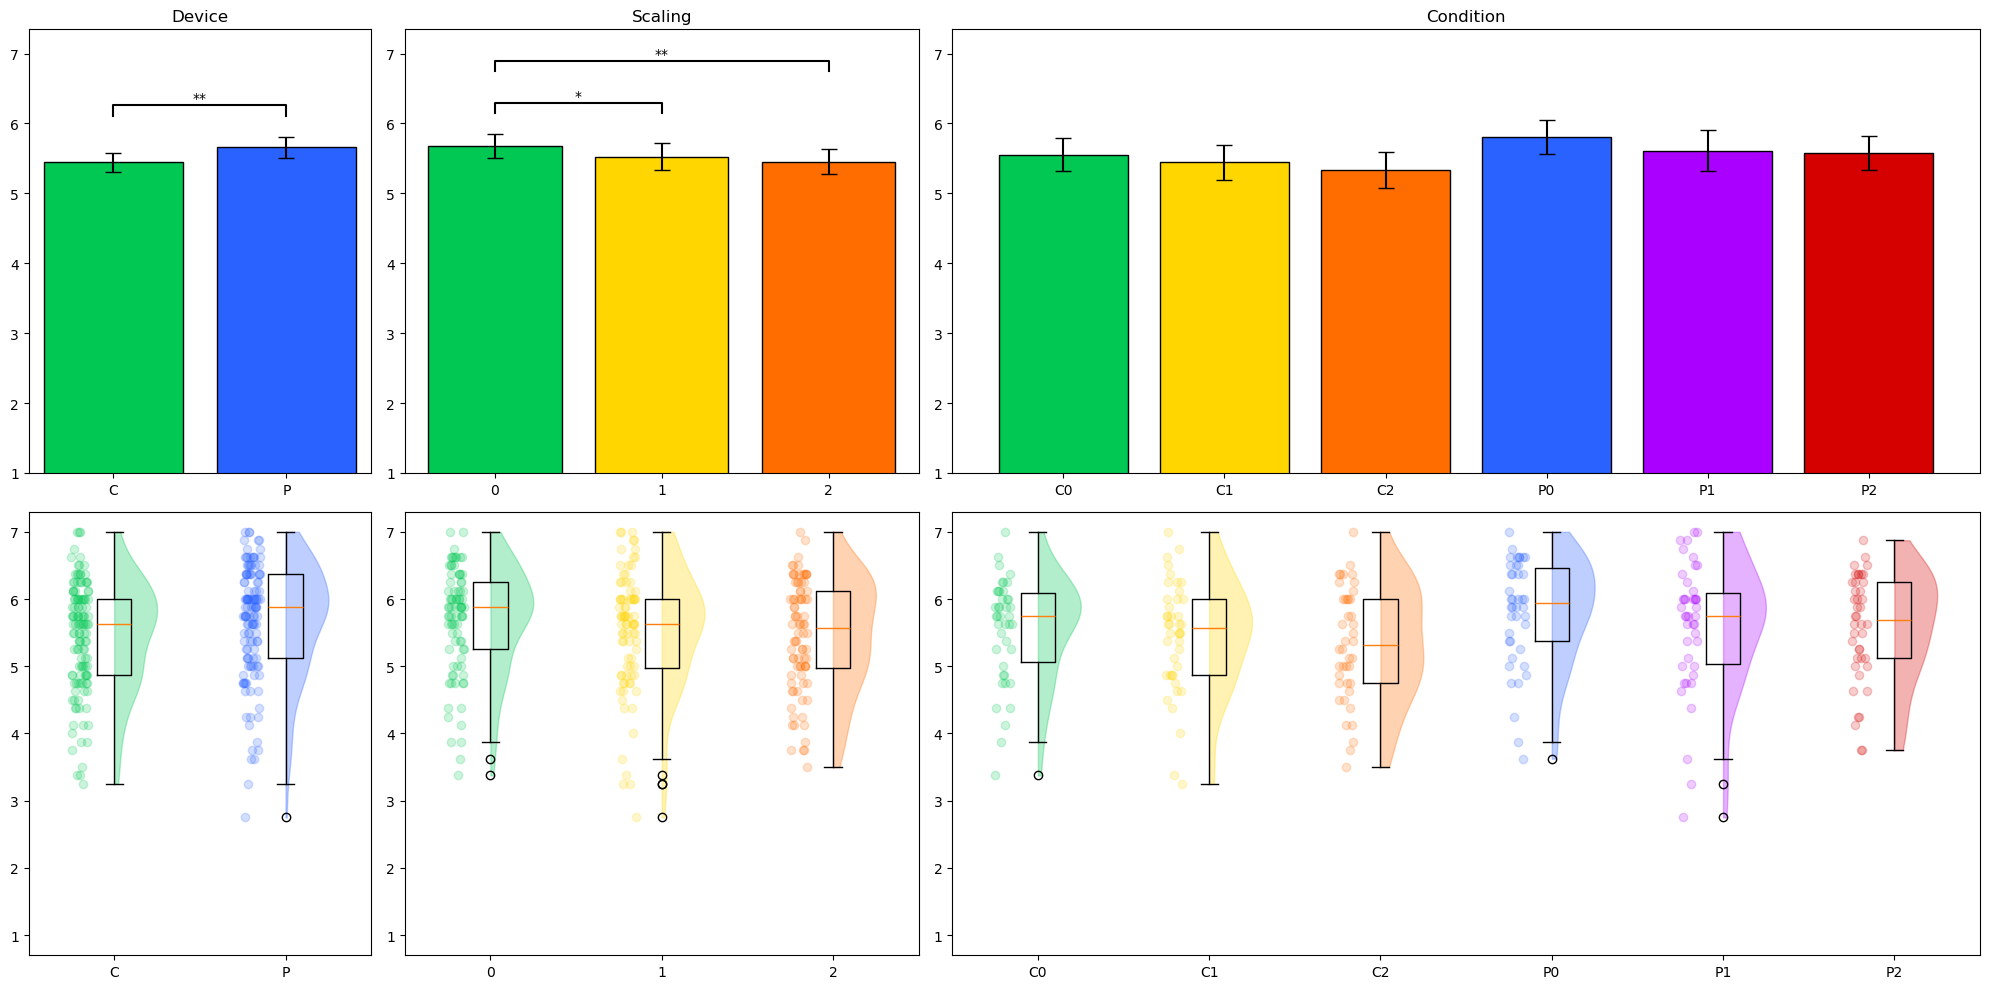

------ [Shovel] FPS Interaction Presence Score ------
Mean & 5.55 & 5.45 & 5.15 & 5.95 & 5.71 & 5.6 \\
Standard Deviation & 0.81 & 0.77 & 1.03 & 0.71 & 0.9 & 0.86 \\
Minimum & 3.12 & 3.88 & 3.0 & 4.62 & 3.38 & 3.75 \\
Maximum & 6.88 & 6.88 & 7.0 & 7.0 & 7.0 & 6.88 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.580357,1,41,8.580357,13.458924,0.000696,0.000696,0.044863,1.000000,✅
1,Scaling,5.972594,2,82,2.986297,9.577053,0.000183,0.000479,0.031660,0.836687,✅
2,Device * Scaling,0.368676,2,82,0.184338,0.738249,0.481100,0.480730,0.002014,0.997010,❌


Device & (1, 41) & 13.46 & \textbf{0.000696} & 0.0449 \\
Scaling & (2, 82) & 9.58 & \textbf{0.000479} & 0.0317 \\
Device * Scaling & (2, 82) & 0.74 & 0.48073 & 0.002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.668641,41.0,two-sided,0.000696,NaN,NaN,41.614,-0.490650,✅
1,Scaling,-,0,1,True,True,2.279956,41.0,two-sided,0.027881,0.055763,holm,1.689,0.250442,🟨
2,Scaling,-,0,2,True,True,4.842182,41.0,two-sided,0.000019,0.000056,holm,1121.736,0.489464,✅
3,Scaling,-,1,2,True,True,2.000481,41.0,two-sided,0.052100,0.055763,holm,1.015,0.258621,🟨


Device P-C & 41 & 3.67 & \textbf{0.000696} & 0.4907 \\
Scaling 1-0 & 41 & -2.28 & 0.055763 & -0.2504 \\
Scaling 2-0 & 41 & -4.84 & \textbf{5.6e-05} & -0.4895 \\
Scaling 2-1 & 41 & -2.0 & 0.055763 & -0.2586 \\


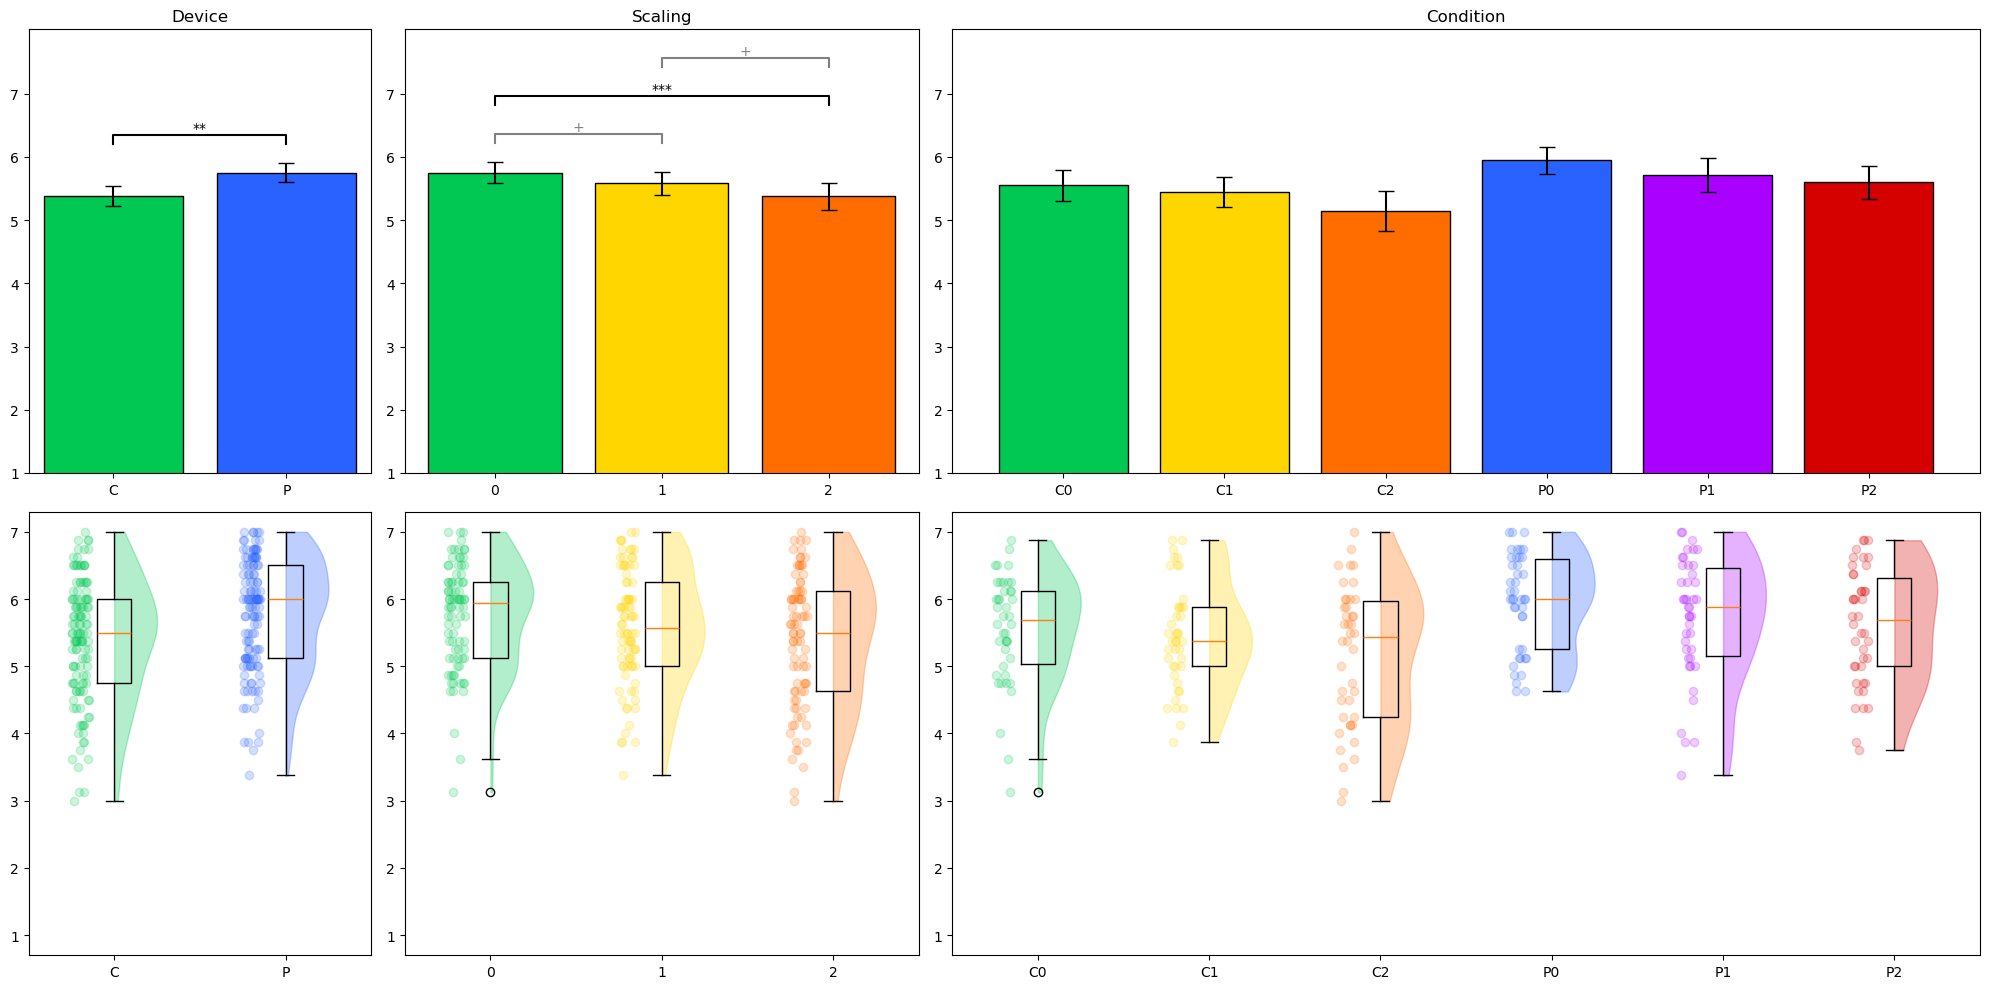

In [361]:
fps_interaction = 'fps_interaction'
#Interaction Presence Score: (FPS-1 + FPS-2 + FPS-4 + FPS-5 + FPS-6 + FPS-7 + FPS-8 + FPS-9) / 8
data[fps_interaction] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9]) / 8,
    axis = 1)

title = 'FPS Interaction Presence Score'
score = fps_interaction
scale = [1,7]
cube_fps_interaction = report_exeriment(data, cube, score, title,scale)
shovel_fps_interaction = report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Scenario Presence Score ------
Mean & 5.54 & 5.43 & 5.44 & 5.79 & 5.61 & 5.63 \\
Standard Deviation & 1.07 & 1.14 & 1.13 & 1.17 & 1.24 & 1.18 \\
Minimum & 3.33 & 3.0 & 3.33 & 2.0 & 2.0 & 1.67 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.682540,1,41,2.682540,4.395644,0.042243,0.042243,0.007872,1.000000,✅
1,Scaling,1.006173,2,82,0.503086,2.167694,0.120955,0.126884,0.002967,0.896207,❌
2,Device * Scaling,0.050265,2,82,0.025132,0.183251,0.832899,0.789457,0.000149,0.819015,❌


Device & (1, 41) & 4.4 & \textbf{0.042243} & 0.0079 \\
Scaling & (2, 82) & 2.17 & 0.126884 & 0.003 \\
Device * Scaling & (2, 82) & 0.18 & 0.789457 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.096579,41.0,two-sided,0.042243,NaN,NaN,1.202,-0.182775,✅


Device P-C & 41 & 2.1 & \textbf{0.042243} & 0.1828 \\


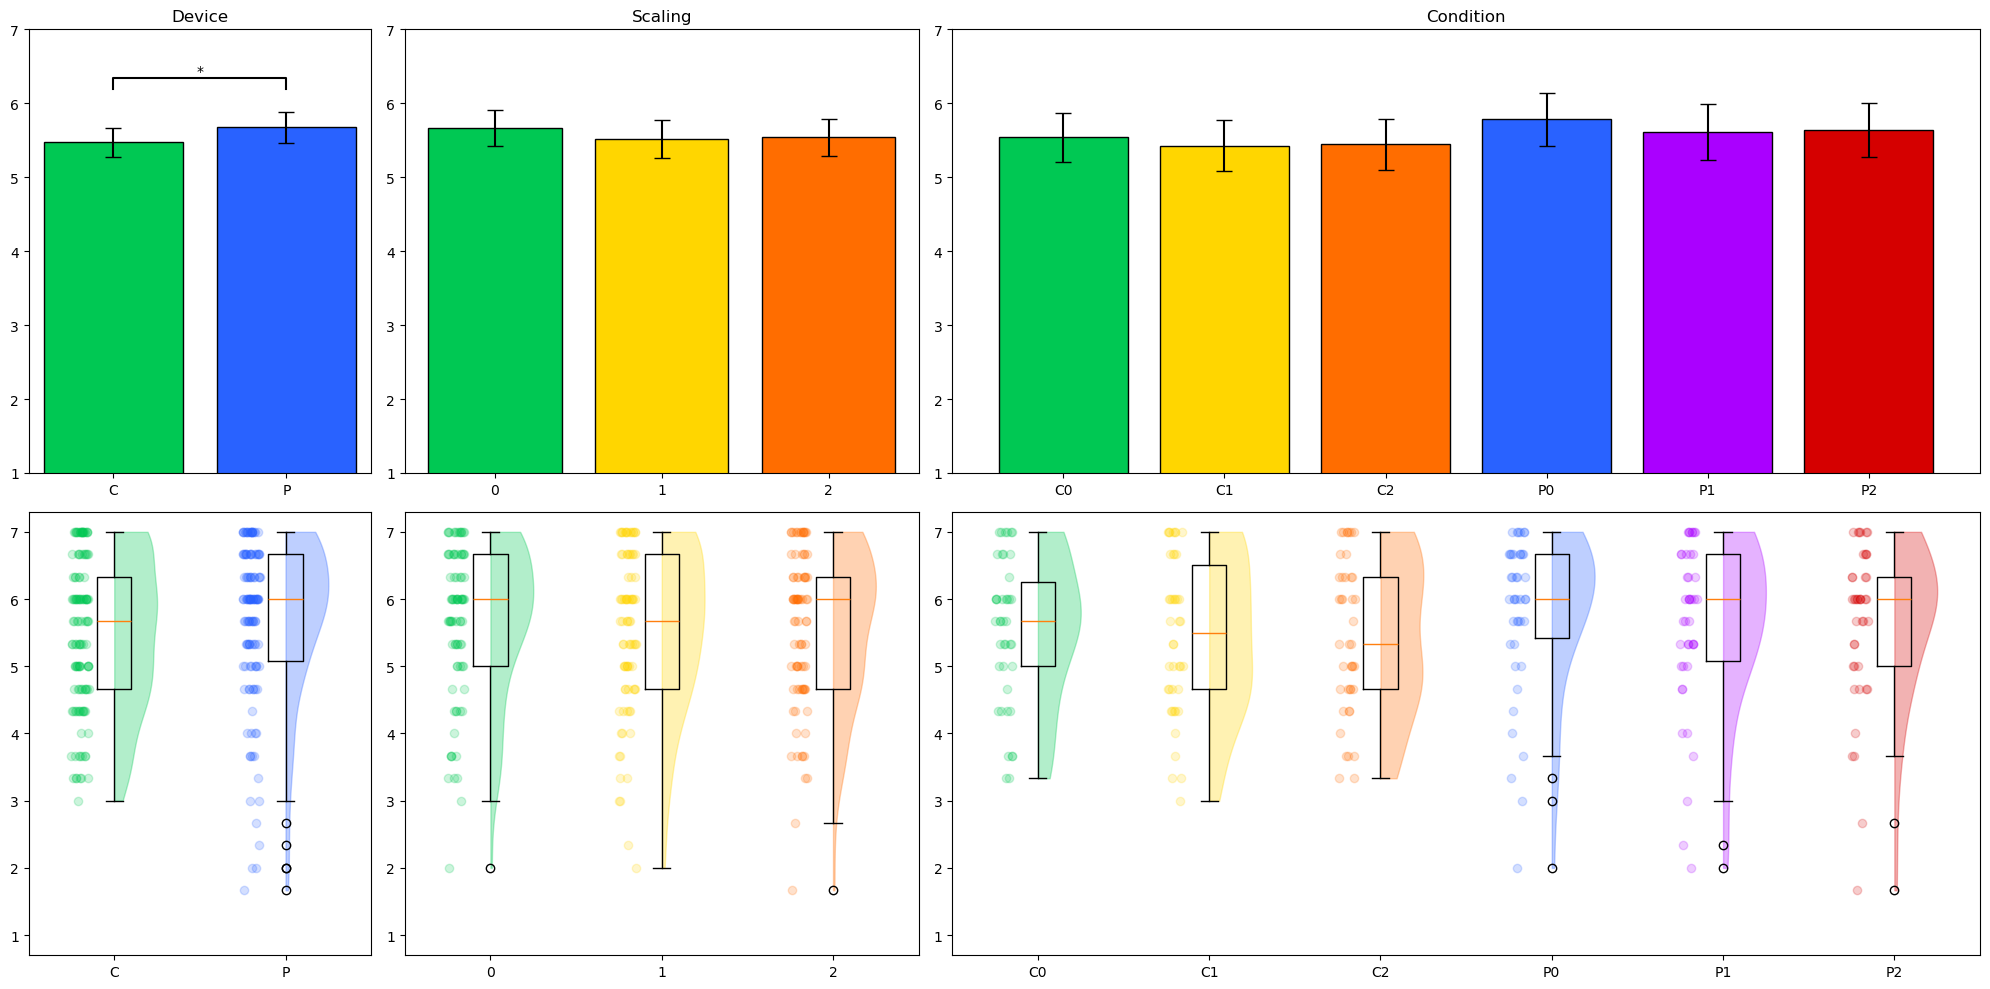

------ [Shovel] FPS Scenario Presence Score ------
Mean & 5.61 & 5.63 & 5.47 & 5.97 & 5.88 & 5.75 \\
Standard Deviation & 1.06 & 0.87 & 1.09 & 0.91 & 0.95 & 1.02 \\
Minimum & 3.33 & 4.0 & 3.67 & 4.0 & 3.67 & 3.33 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.432540,1,41,5.432540,7.956670,0.007351,0.007351,0.021698,1.000000,✅
1,Scaling,1.597884,2,82,0.798942,3.288712,0.042279,0.047499,0.006481,0.904702,✅
2,Device * Scaling,0.137566,2,82,0.068783,0.337449,0.714575,0.695876,0.000561,0.916398,❌


Device & (1, 41) & 7.96 & \textbf{0.007351} & 0.0217 \\
Scaling & (2, 82) & 3.29 & \textbf{0.047499} & 0.0065 \\
Device * Scaling & (2, 82) & 0.34 & 0.695876 & 0.0006 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.820757,41.0,two-sided,0.007351,NaN,NaN,5.218,-0.316189,✅
1,Scaling,-,0,1,True,True,0.507601,41.0,two-sided,0.614453,0.614453,holm,0.188,0.037078,❌
2,Scaling,-,0,2,True,True,2.208195,41.0,two-sided,0.032881,0.098643,holm,1.475,0.191918,🟨
3,Scaling,-,1,2,True,True,1.855072,41.0,two-sided,0.070786,0.141572,holm,0.796,0.163603,❌


Device P-C & 41 & 2.82 & \textbf{0.007351} & 0.3162 \\
Scaling 1-0 & 41 & -0.51 & 0.614453 & -0.0371 \\
Scaling 2-0 & 41 & -2.21 & 0.098643 & -0.1919 \\
Scaling 2-1 & 41 & -1.86 & 0.141572 & -0.1636 \\


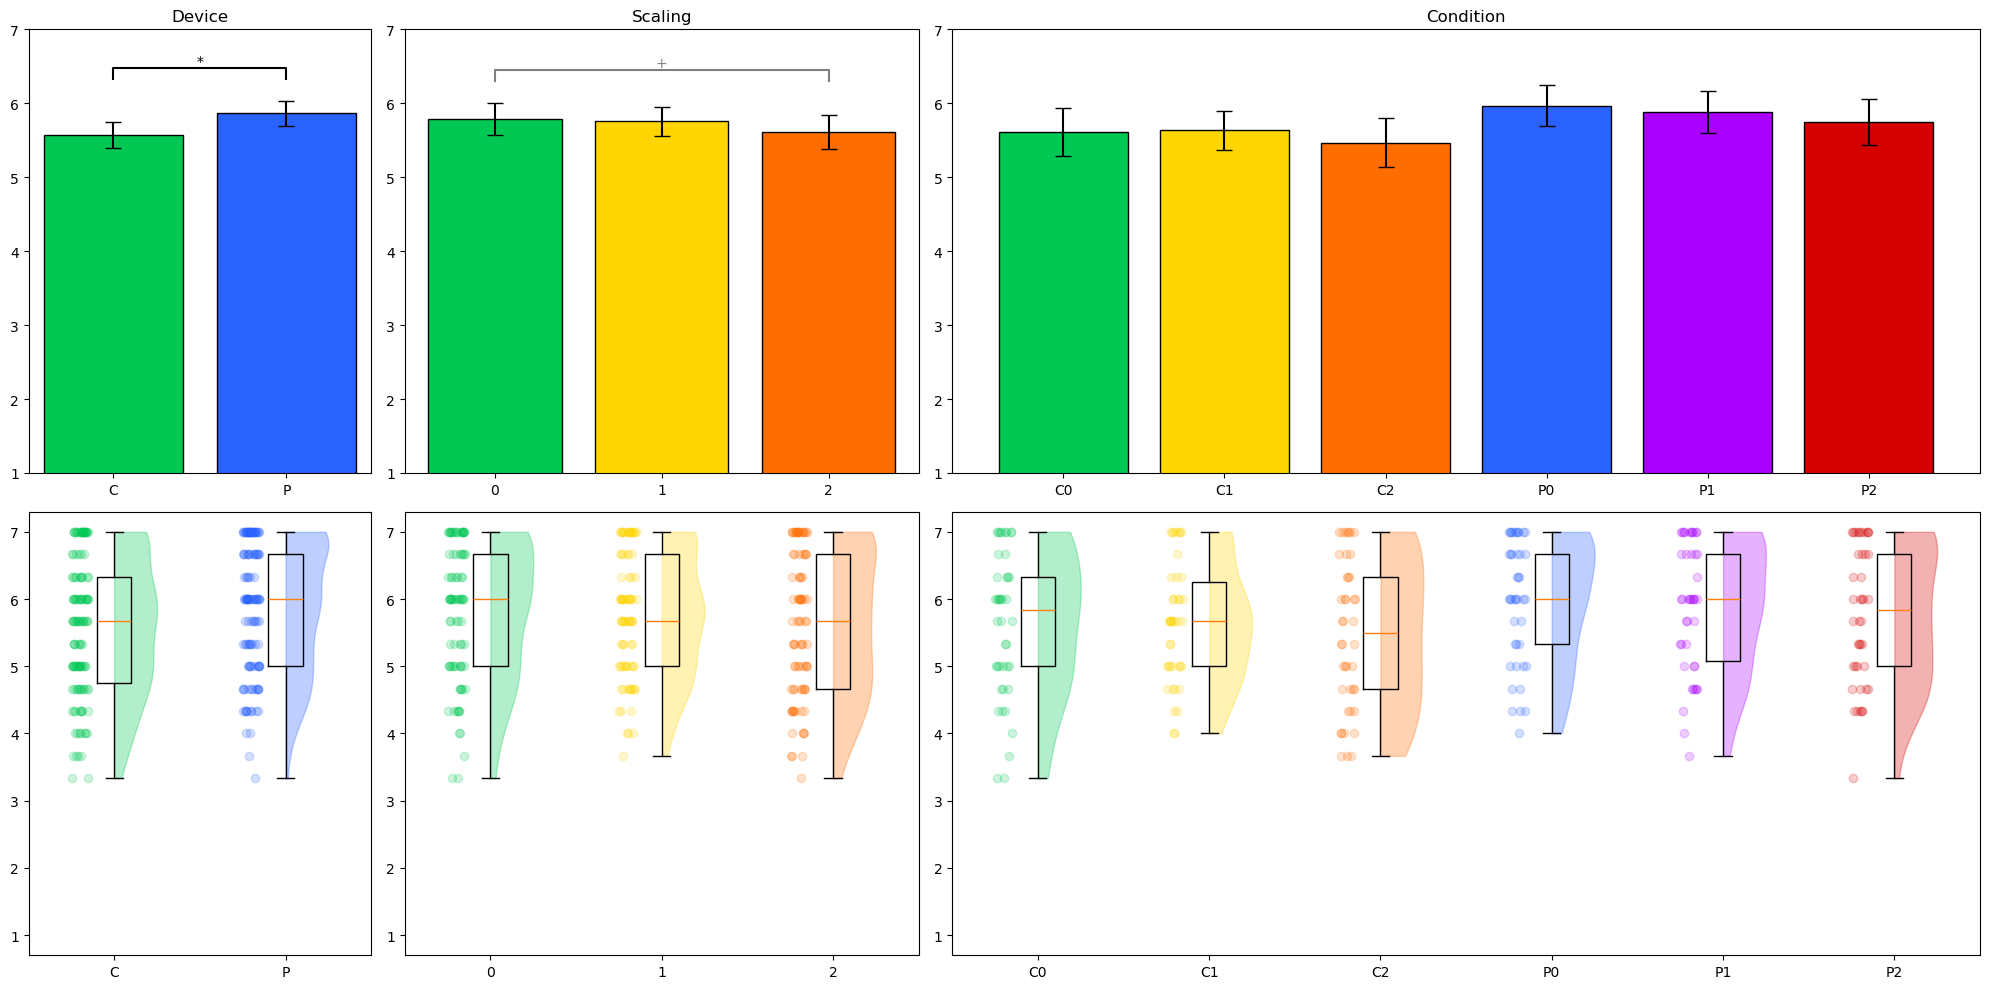

In [362]:
fps_scenario = 'fps_scenario'
#Scenario Presence Score: (FPS-3 + FPS-4 + FPS-8) / 3
data[fps_scenario] = data.apply(lambda x: 
    (x[fps_3] + x[fps_4] + x[fps_8]) / 3,
    axis = 1)

title = 'FPS Scenario Presence Score'
score = fps_scenario
scale = [1,7]
cube_fps_scenario = report_exeriment(data, cube, score, title,scale)
shovel_fps_scenario = report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Display Presence Score ------
Mean & 5.15 & 5.12 & 5.02 & 5.48 & 5.3 & 5.32 \\
Standard Deviation & 0.95 & 0.98 & 0.97 & 0.95 & 1.09 & 1.0 \\
Minimum & 3.0 & 2.57 & 3.0 & 2.86 & 2.43 & 2.43 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 6.71 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.587302,1,41,4.587302,12.982157,0.000843,0.000843,0.018135,1.000000,✅
1,Scaling,0.952543,2,82,0.476271,3.066800,0.051948,0.056541,0.003821,0.920506,🟨
2,Device * Scaling,0.255750,2,82,0.127875,0.900140,0.410491,0.401181,0.001029,0.896042,❌


Device & (1, 41) & 12.98 & \textbf{0.000843} & 0.0181 \\
Scaling & (2, 82) & 3.07 & 0.056541 & 0.0038 \\
Device * Scaling & (2, 82) & 0.9 & 0.401181 & 0.001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.603076,41.0,two-sided,0.000843,NaN,NaN,35.051,-0.280199,✅


Device P-C & 41 & 3.6 & \textbf{0.000843} & 0.2802 \\


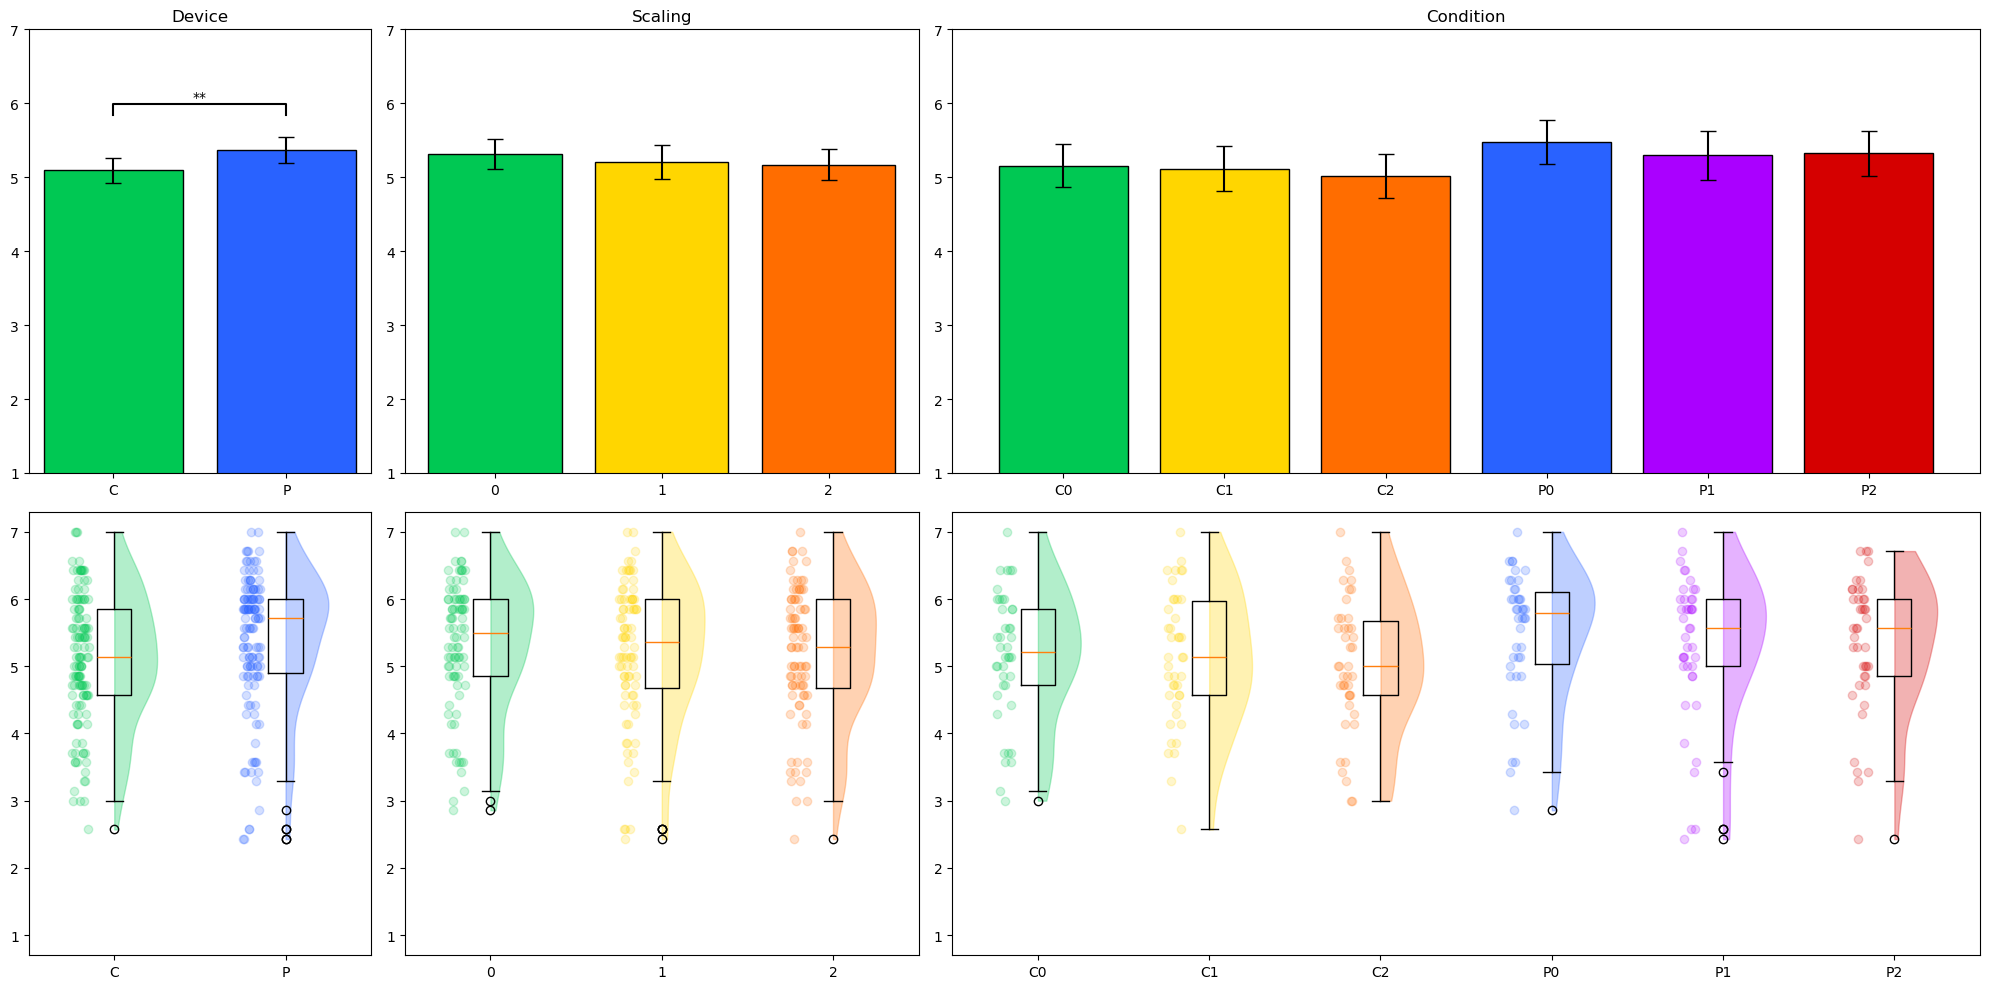

------ [Shovel] FPS Display Presence Score ------
Mean & 5.25 & 5.25 & 5.03 & 5.62 & 5.46 & 5.36 \\
Standard Deviation & 0.88 & 0.81 & 1.07 & 0.86 & 0.88 & 0.91 \\
Minimum & 3.43 & 3.71 & 3.0 & 3.43 & 3.29 & 3.43 \\
Maximum & 6.71 & 6.71 & 7.0 & 7.0 & 6.86 & 6.86 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.773324,1,41,5.773324,9.517922,0.003636,0.003636,0.027364,1.000000,✅
1,Scaling,2.429057,2,82,1.214529,6.245894,0.002987,0.004845,0.011698,0.857978,✅
2,Device * Scaling,0.275510,2,82,0.137755,0.780127,0.461719,0.460377,0.001341,0.988165,❌


Device & (1, 41) & 9.52 & \textbf{0.003636} & 0.0274 \\
Scaling & (2, 82) & 6.25 & \textbf{0.004845} & 0.0117 \\
Device * Scaling & (2, 82) & 0.78 & 0.460377 & 0.0013 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.085113,41.0,two-sided,0.003636,NaN,NaN,9.616,-0.355841,✅
1,Scaling,-,0,1,True,True,1.469643,41.0,two-sided,0.149291,0.149291,holm,0.451,0.102868,❌
2,Scaling,-,0,2,True,True,3.443105,41.0,two-sided,0.001338,0.004013,holm,23.221,0.275082,✅
3,Scaling,-,1,2,True,True,1.984281,41.0,two-sided,0.053945,0.107891,holm,0.987,0.184645,❌


Device P-C & 41 & 3.09 & \textbf{0.003636} & 0.3558 \\
Scaling 1-0 & 41 & -1.47 & 0.149291 & -0.1029 \\
Scaling 2-0 & 41 & -3.44 & \textbf{0.004013} & -0.2751 \\
Scaling 2-1 & 41 & -1.98 & 0.107891 & -0.1846 \\


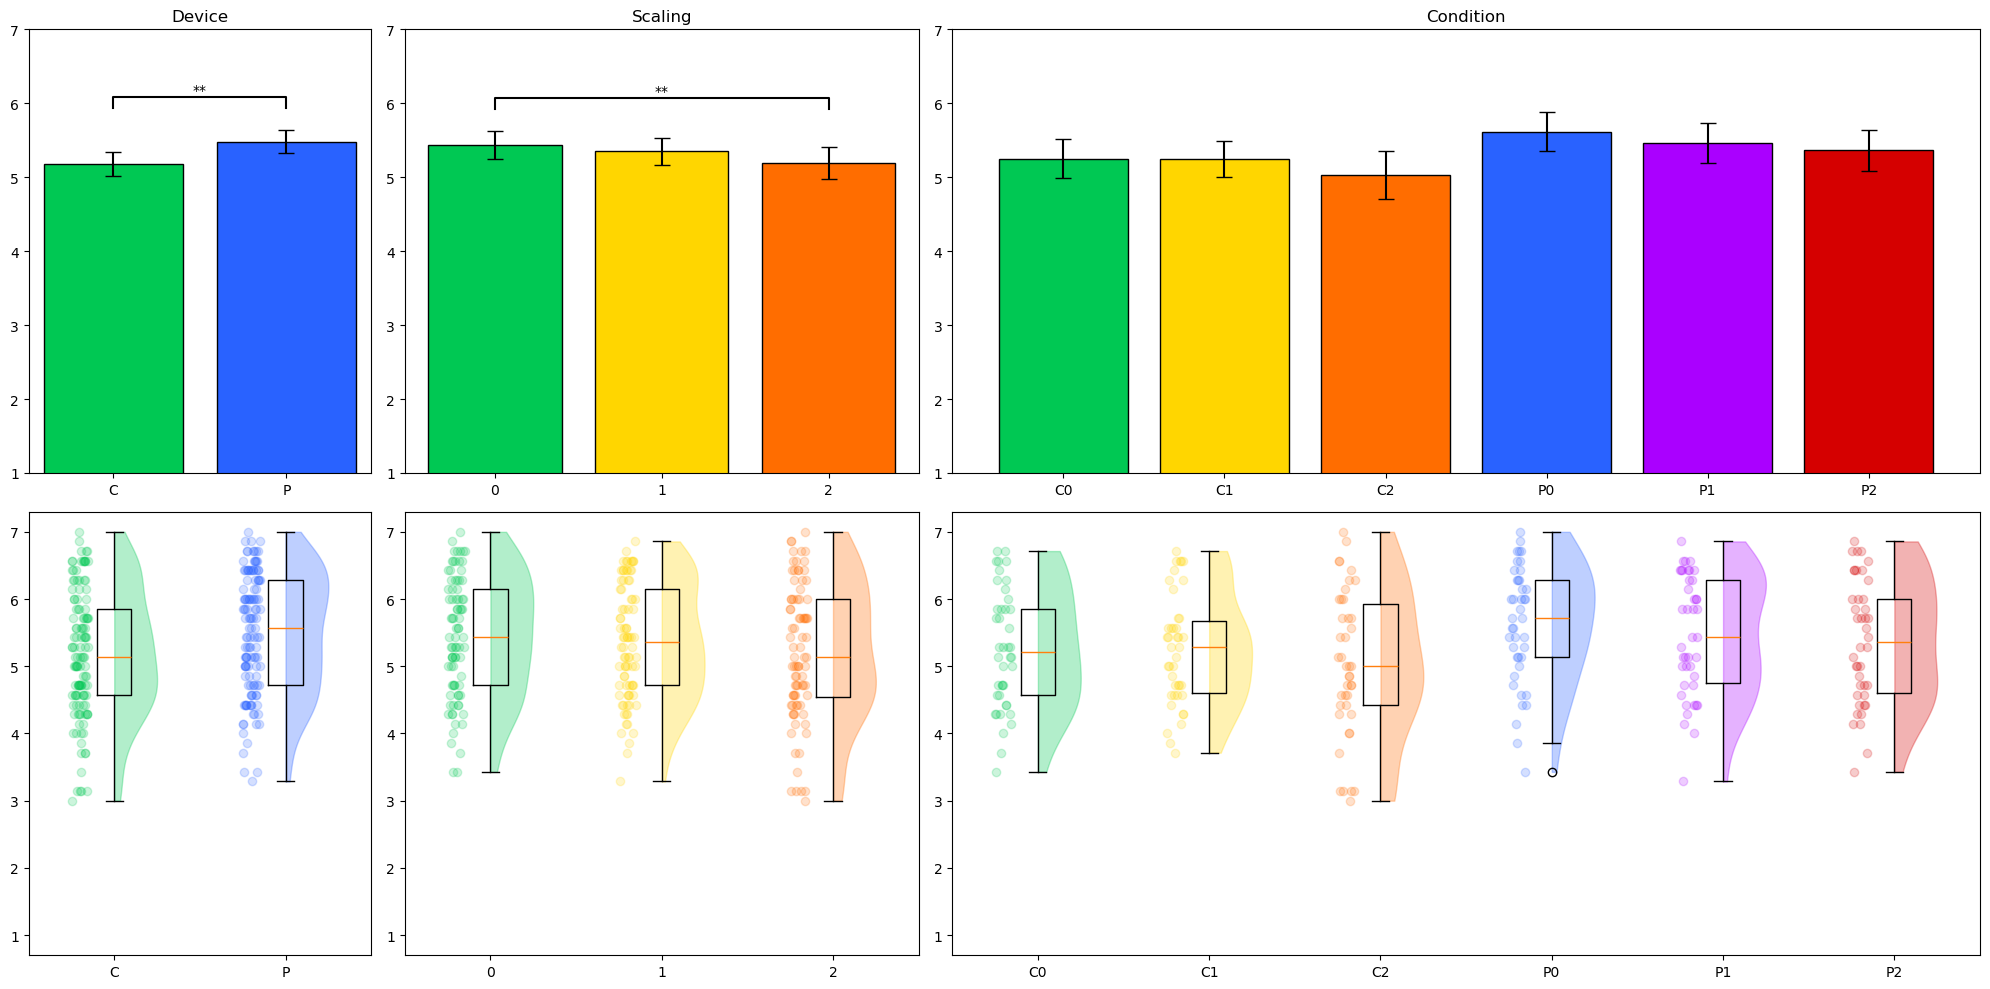

In [363]:
fps_display = 'fps_display'
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
data[fps_display] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_7] + x[fps_8] + x[fps_10]) / 7,
    axis = 1)

title = 'FPS Display Presence Score'
score = fps_display
scale = [1,7]
cube_fps_display = report_exeriment(data, cube, score, title,scale)
shovel_fps_display = report_exeriment(data, shovel, score, title, scale)

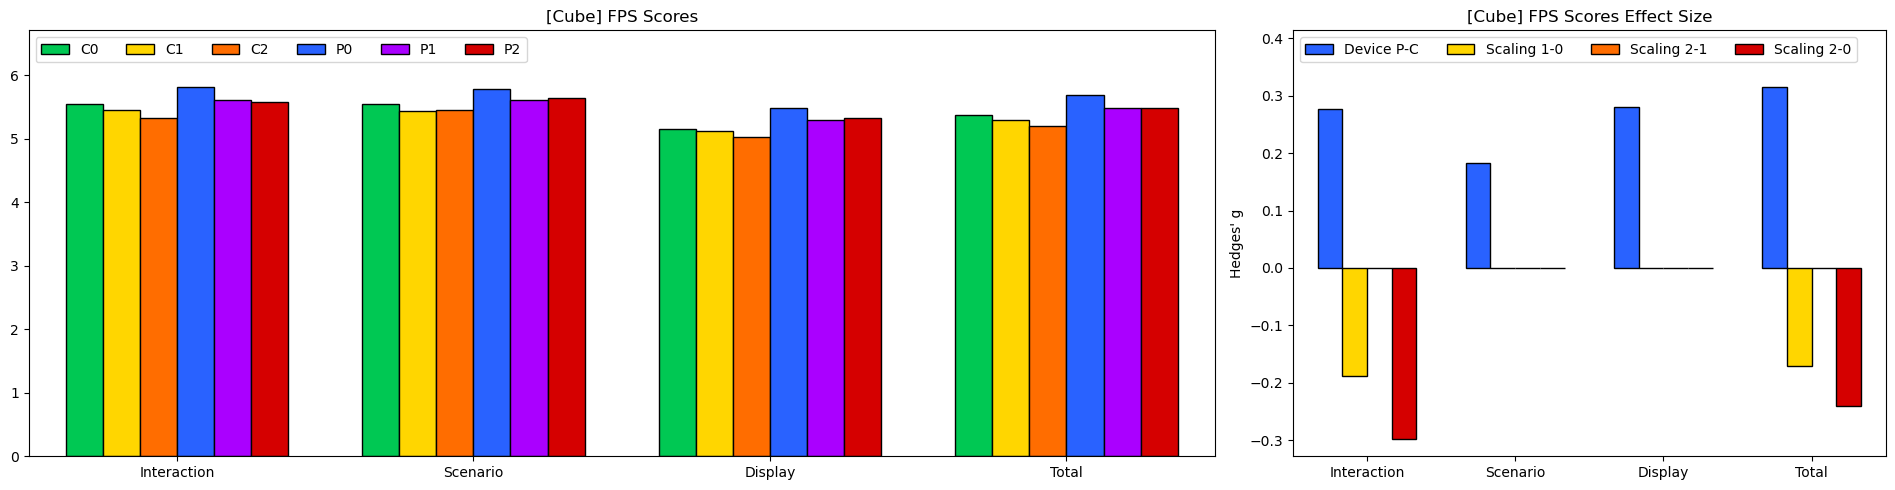

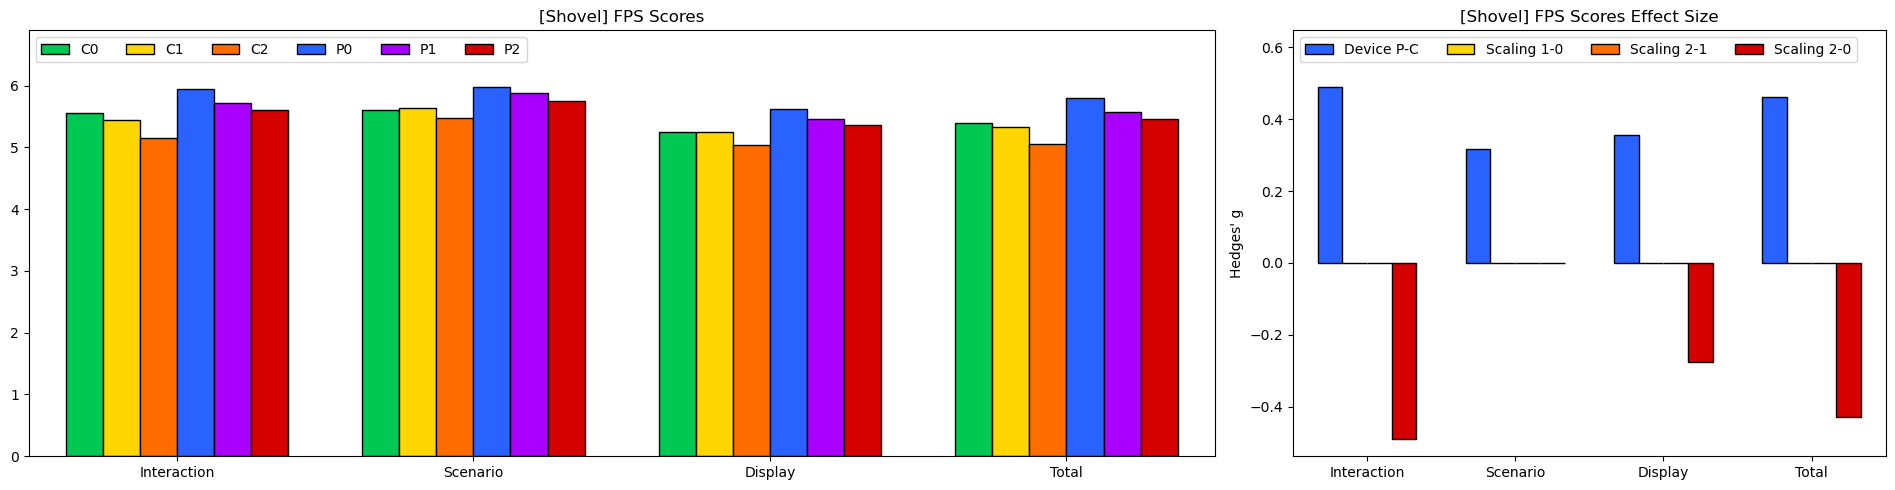

In [364]:
def get_fps_splits(data, e):
    exp_data = data[data[task] == e]
    total_means = []
    interaction_means = []
    scenario_means = []
    display_means = []

    for c in conditions:
        condition_data = exp_data[exp_data[condition_key] == c]
        total_means.append(np.mean(condition_data[fps_total]))
        interaction_means.append(np.mean(condition_data[fps_interaction]))
        scenario_means.append(np.mean(condition_data[fps_scenario]))
        display_means.append(np.mean(condition_data[fps_display]))

    return [interaction_means, scenario_means, display_means, total_means]

labels = ["Interaction", "Scenario", "Display", "Total"]
ylabel = ''
cube_title = "[Cube] FPS Scores"
cube_fps_splits = get_fps_splits(data, cube)
cube_fps_aovs = [cube_fps_interaction, cube_fps_scenario, cube_fps_display, cube_fps_total]
report_comparison(cube_fps_splits, cube_fps_aovs, labels, cube_title, ylabel)

shovel_title = "[Shovel] FPS Scores"
shovel_fps_splits = get_fps_splits(data, shovel)
shovel_fps_aovs = [shovel_fps_interaction, shovel_fps_scenario, shovel_fps_display, shovel_fps_total]
report_comparison(shovel_fps_splits, shovel_fps_aovs, labels, shovel_title, ylabel)

------ [Cube] Borg Challenge Rating (CR10) ------
Mean & 1.0 & 1.0 & 1.02 & 1.17 & 1.33 & 1.29 \\
Standard Deviation & 0.76 & 0.79 & 0.71 & 0.72 & 0.81 & 0.76 \\
Minimum & 0 & 0 & 0 & 0 & 0 & 0 \\
Maximum & 3 & 3 & 2 & 3 & 3 & 3 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.063492,1,41,4.063492,18.642984,0.000097,0.000097,0.027312,1.000000,✅
1,Scaling,0.341270,2,82,0.170635,0.933298,0.397391,0.391804,0.002353,0.930110,❌
2,Device * Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.408023,0.002025,0.881868,❌


Device & (1, 41) & 18.64 & \textbf{9.7e-05} & 0.0273 \\
Scaling & (2, 82) & 0.93 & 0.391804 & 0.0024 \\
Device * Scaling & (2, 82) & 0.88 & 0.408023 & 0.002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.317752,41.0,two-sided,0.000097,NaN,NaN,246.064,-0.366425,✅


Device P-C & 41 & 4.32 & \textbf{9.7e-05} & 0.3664 \\


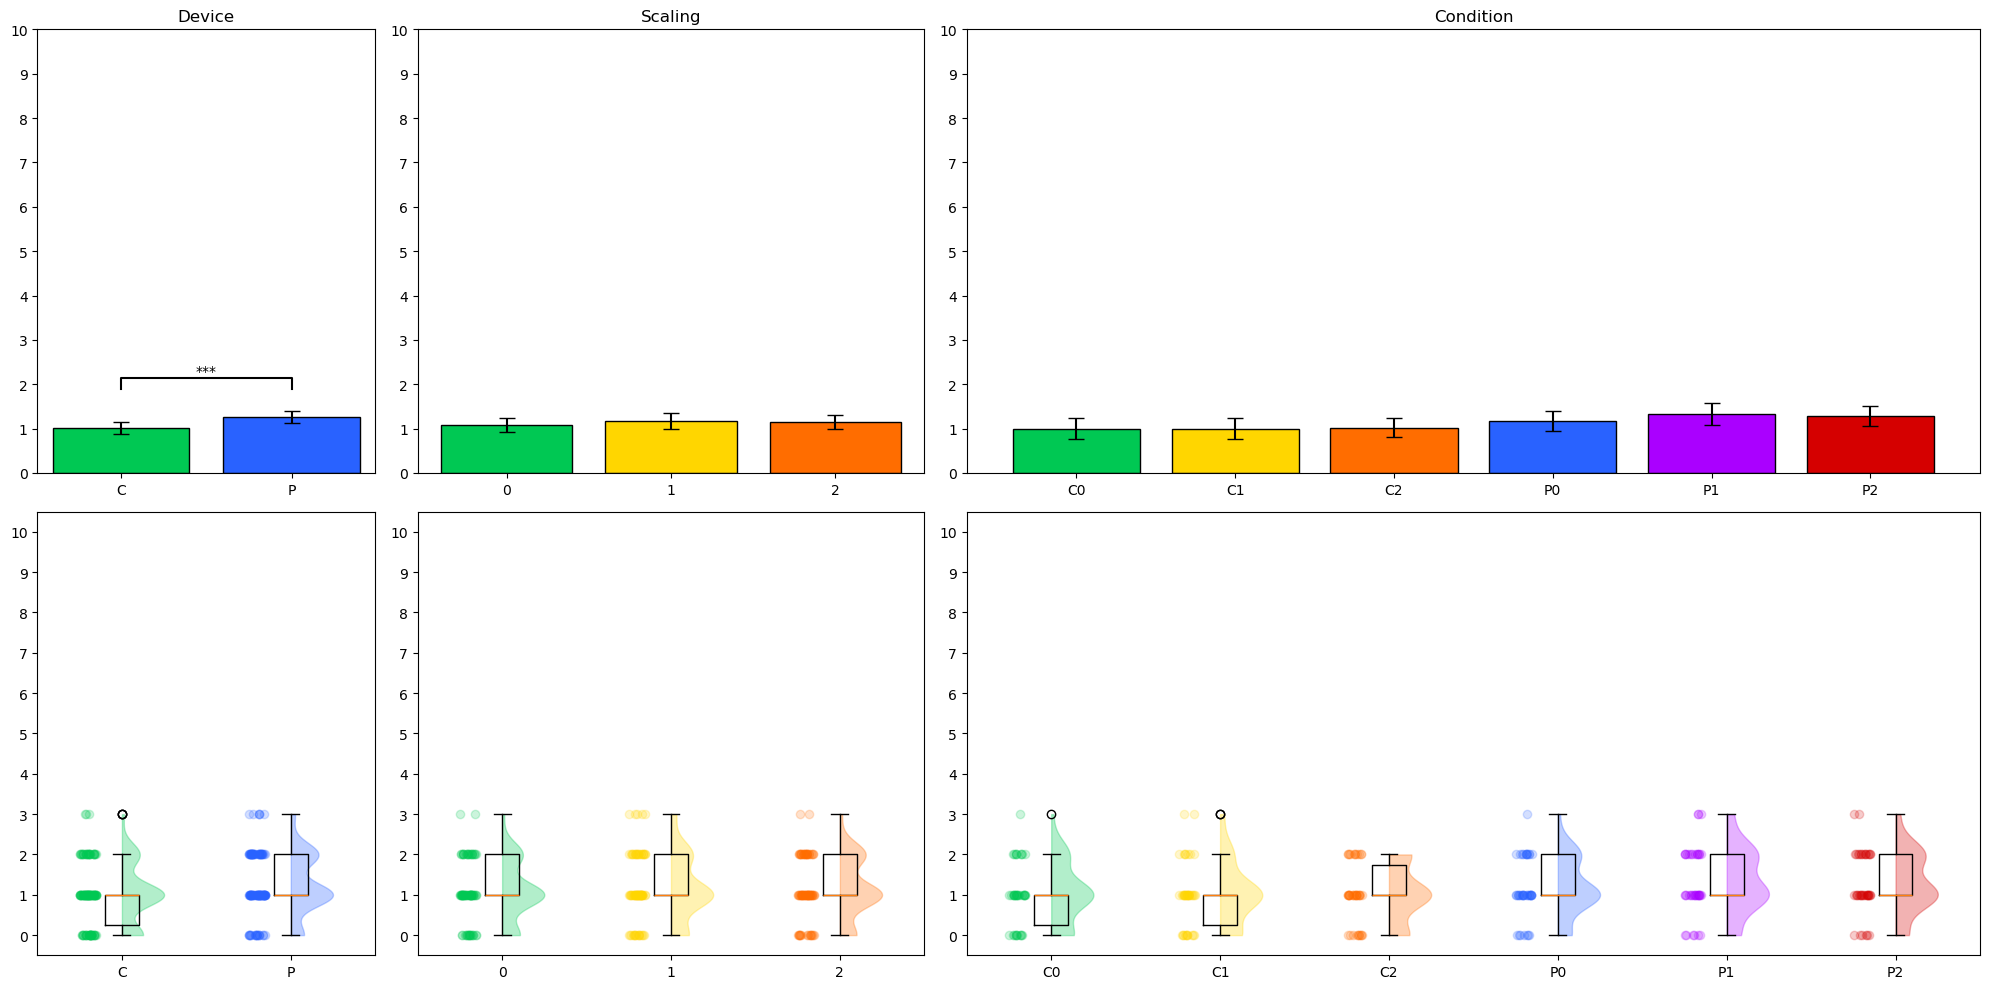

------ [Shovel] Borg Challenge Rating (CR10) ------
Mean & 1.9 & 2.0 & 2.1 & 2.31 & 2.33 & 2.38 \\
Standard Deviation & 0.97 & 0.95 & 1.02 & 0.94 & 0.94 & 1.11 \\
Minimum & 0 & 0 & 0 & 1 & 1 & 0 \\
Maximum & 4 & 4 & 4 & 4 & 5 & 5 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,7.337302,1,41,7.337302,26.949520,0.000006,0.000006,0.028797,1.000000,✅
1,Scaling,0.722222,2,82,0.361111,1.460274,0.238146,0.239129,0.002910,0.899140,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.481161,0.619799,0.603025,0.000609,0.914342,❌


Device & (1, 41) & 26.95 & \textbf{6e-06} & 0.0288 \\
Scaling & (2, 82) & 1.46 & 0.239129 & 0.0029 \\
Device * Scaling & (2, 82) & 0.48 & 0.603025 & 0.0006 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-5.191293,41.0,two-sided,0.000006,NaN,NaN,3167.411,-0.362265,✅


Device P-C & 41 & 5.19 & \textbf{6e-06} & 0.3623 \\


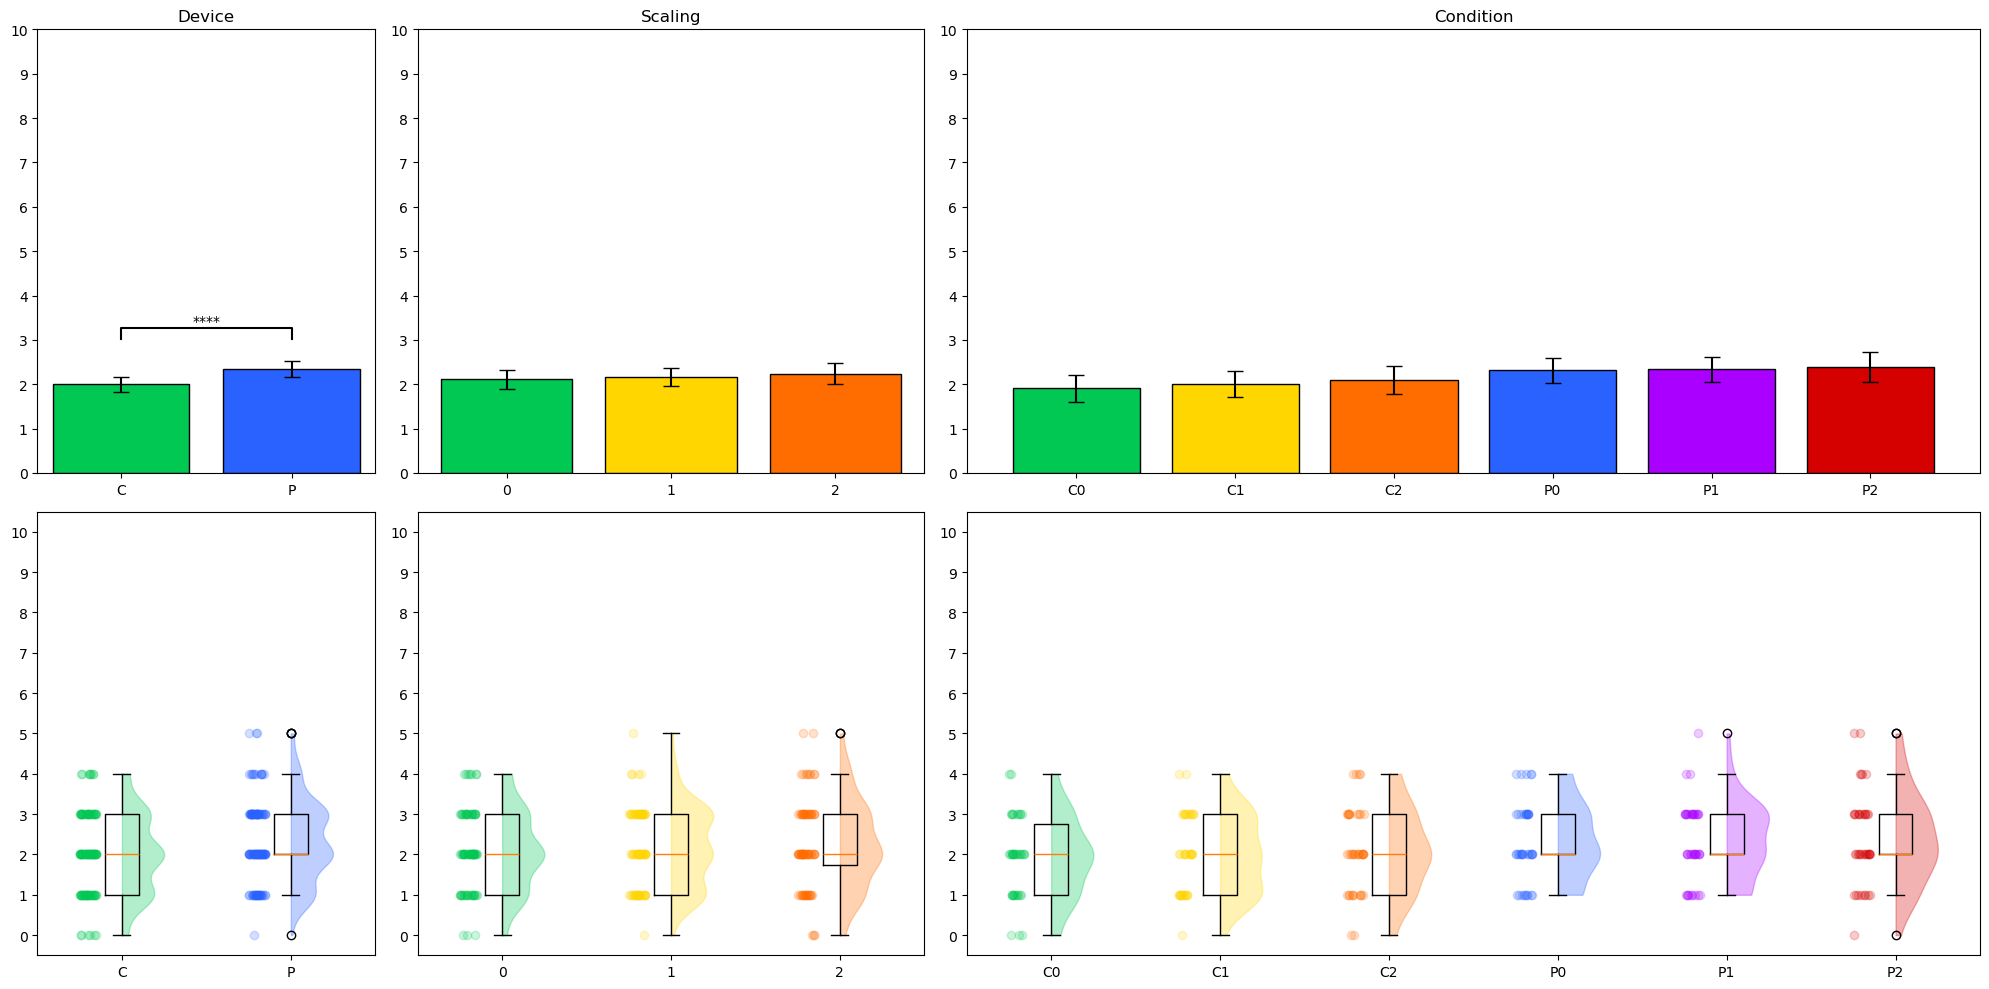

In [365]:
borg_cr_numeric = 'borg_cr_numeric'
#Format: X(X) - ...
data[borg_cr_numeric] = data.apply(lambda x: int(x[borg_cr].split()[0]), axis = 1)

title = 'Borg Challenge Rating (CR10)'
score = borg_cr_numeric
scale = [0,10]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

fps_display = 'fps_display'
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
data[fps_display] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_7] + x[fps_8] + x[fps_10]) / 7,
    axis = 1)

------ [Cube] Samn-Perelli Fatigue Level ------
Mean & 1.57 & 1.6 & 1.57 & 1.64 & 1.69 & 1.81 \\
Standard Deviation & 0.76 & 0.69 & 0.76 & 0.72 & 0.77 & 0.91 \\
Minimum & 1 & 1 & 1 & 1 & 1 & 1 \\
Maximum & 3 & 3 & 3 & 3 & 3 & 5 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.146825,1,41,1.146825,8.783543,0.005044,0.005044,0.007598,1.000000,✅
1,Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.386302,0.001957,0.697315,❌
2,Device * Scaling,0.341270,2,82,0.170635,1.448644,0.240836,0.241104,0.002273,0.686872,❌


Device & (1, 41) & 8.78 & \textbf{0.005044} & 0.0076 \\
Scaling & (2, 82) & 0.88 & 0.386302 & 0.002 \\
Device * Scaling & (2, 82) & 1.45 & 0.241104 & 0.0023 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.963704,41.0,two-sided,0.005044,NaN,NaN,7.23,-0.186481,✅


Device P-C & 41 & 2.96 & \textbf{0.005044} & 0.1865 \\


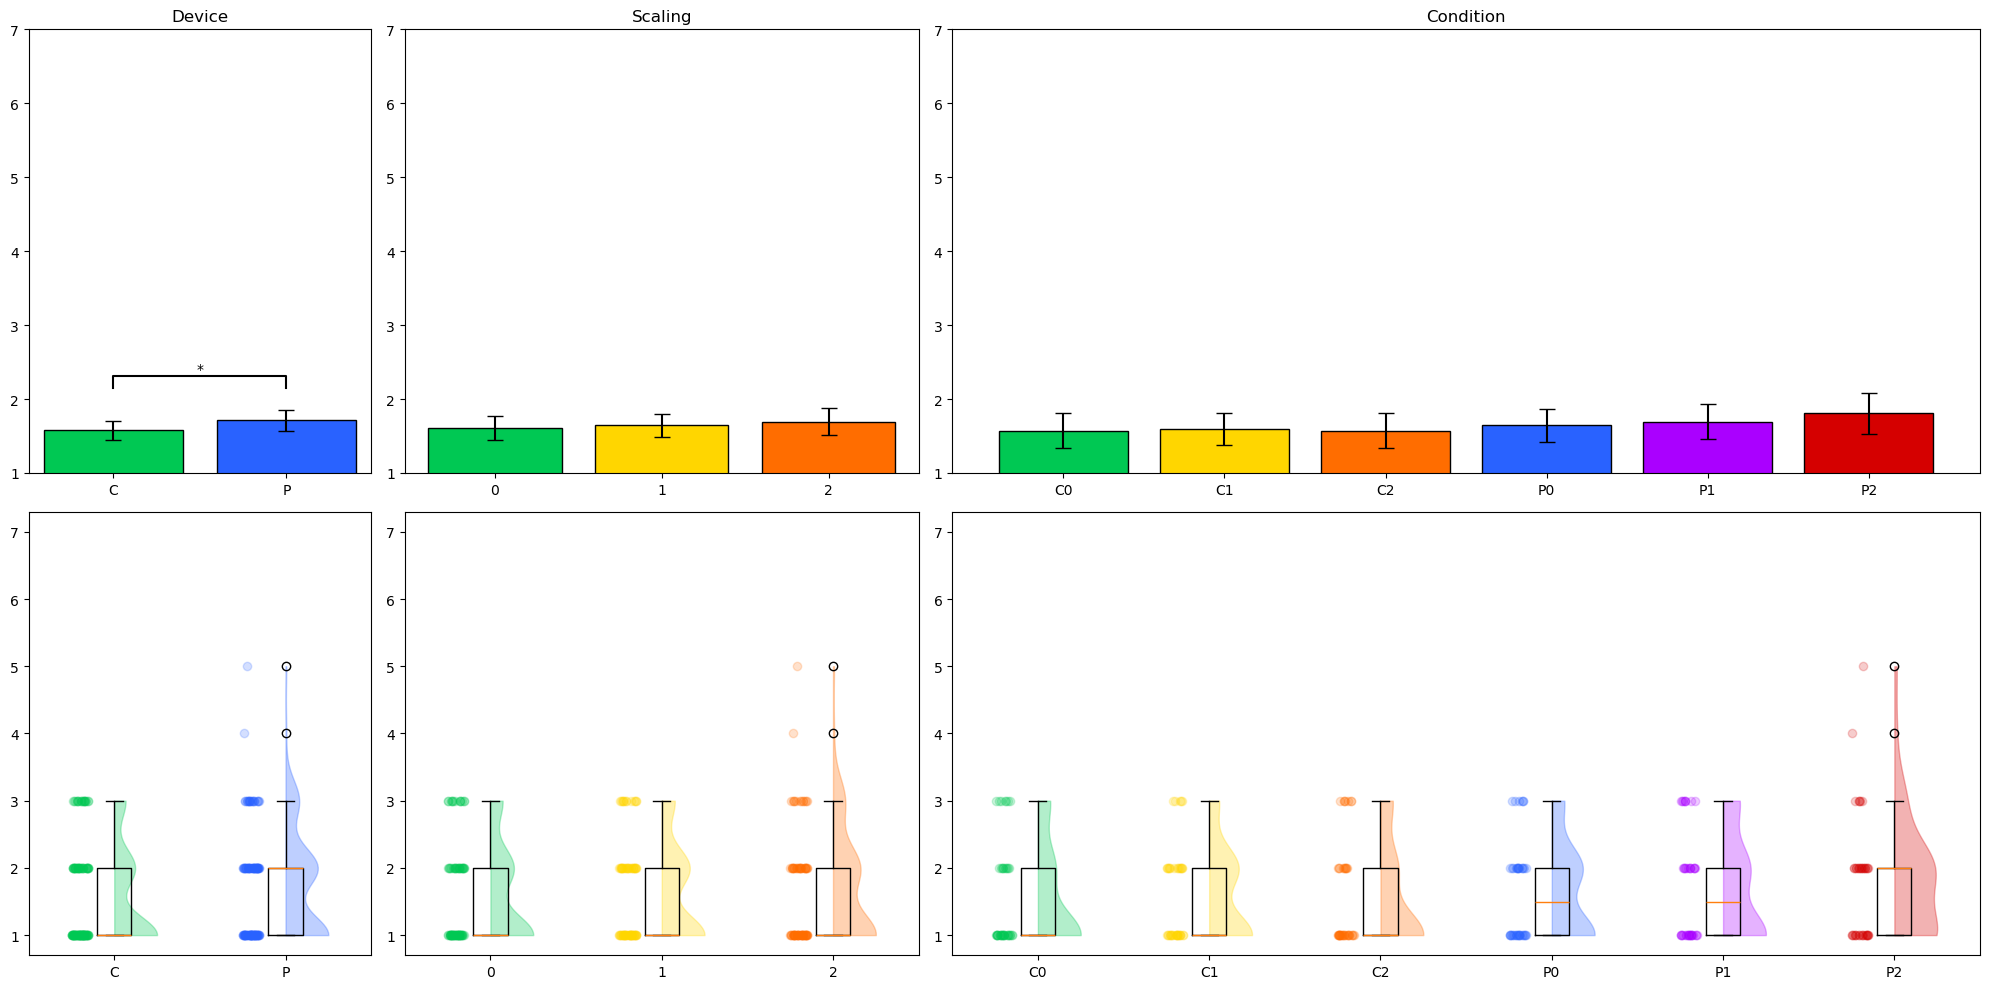

------ [Shovel] Samn-Perelli Fatigue Level ------
Mean & 2.24 & 2.33 & 2.48 & 2.43 & 2.67 & 2.6 \\
Standard Deviation & 1.0 & 1.06 & 1.12 & 1.09 & 1.17 & 1.18 \\
Minimum & 1 & 1 & 1 & 1 & 1 & 1 \\
Maximum & 5 & 5 & 5 & 5 & 6 & 6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.892857,1,41,2.892857,9.165593,0.004251,0.004251,0.009330,1.000000,✅
1,Scaling,1.960317,2,82,0.980159,4.221342,0.017991,0.023958,0.006341,0.848962,✅
2,Device * Scaling,0.500000,2,82,0.250000,1.069565,0.347896,0.338439,0.001625,0.830403,❌


Device & (1, 41) & 9.17 & \textbf{0.004251} & 0.0093 \\
Scaling & (2, 82) & 4.22 & \textbf{0.023958} & 0.0063 \\
Device * Scaling & (2, 82) & 1.07 & 0.338439 & 0.0016 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.027473,41.0,two-sided,0.004251,NaN,NaN,8.391,-0.203055,✅
1,Scaling,-,0,1,True,True,-2.553963,41.0,two-sided,0.014464,0.043392,holm,2.926,-0.159560,✅
2,Scaling,-,0,2,True,True,-2.283185,41.0,two-sided,0.027673,0.055346,holm,1.7,-0.190844,🟨
3,Scaling,-,1,2,True,True,-0.534212,41.0,two-sided,0.596080,0.596080,holm,0.191,-0.032587,❌


Device P-C & 41 & 3.03 & \textbf{0.004251} & 0.2031 \\
Scaling 1-0 & 41 & 2.55 & \textbf{0.043392} & 0.1596 \\
Scaling 2-0 & 41 & 2.28 & 0.055346 & 0.1908 \\
Scaling 2-1 & 41 & 0.53 & 0.59608 & 0.0326 \\


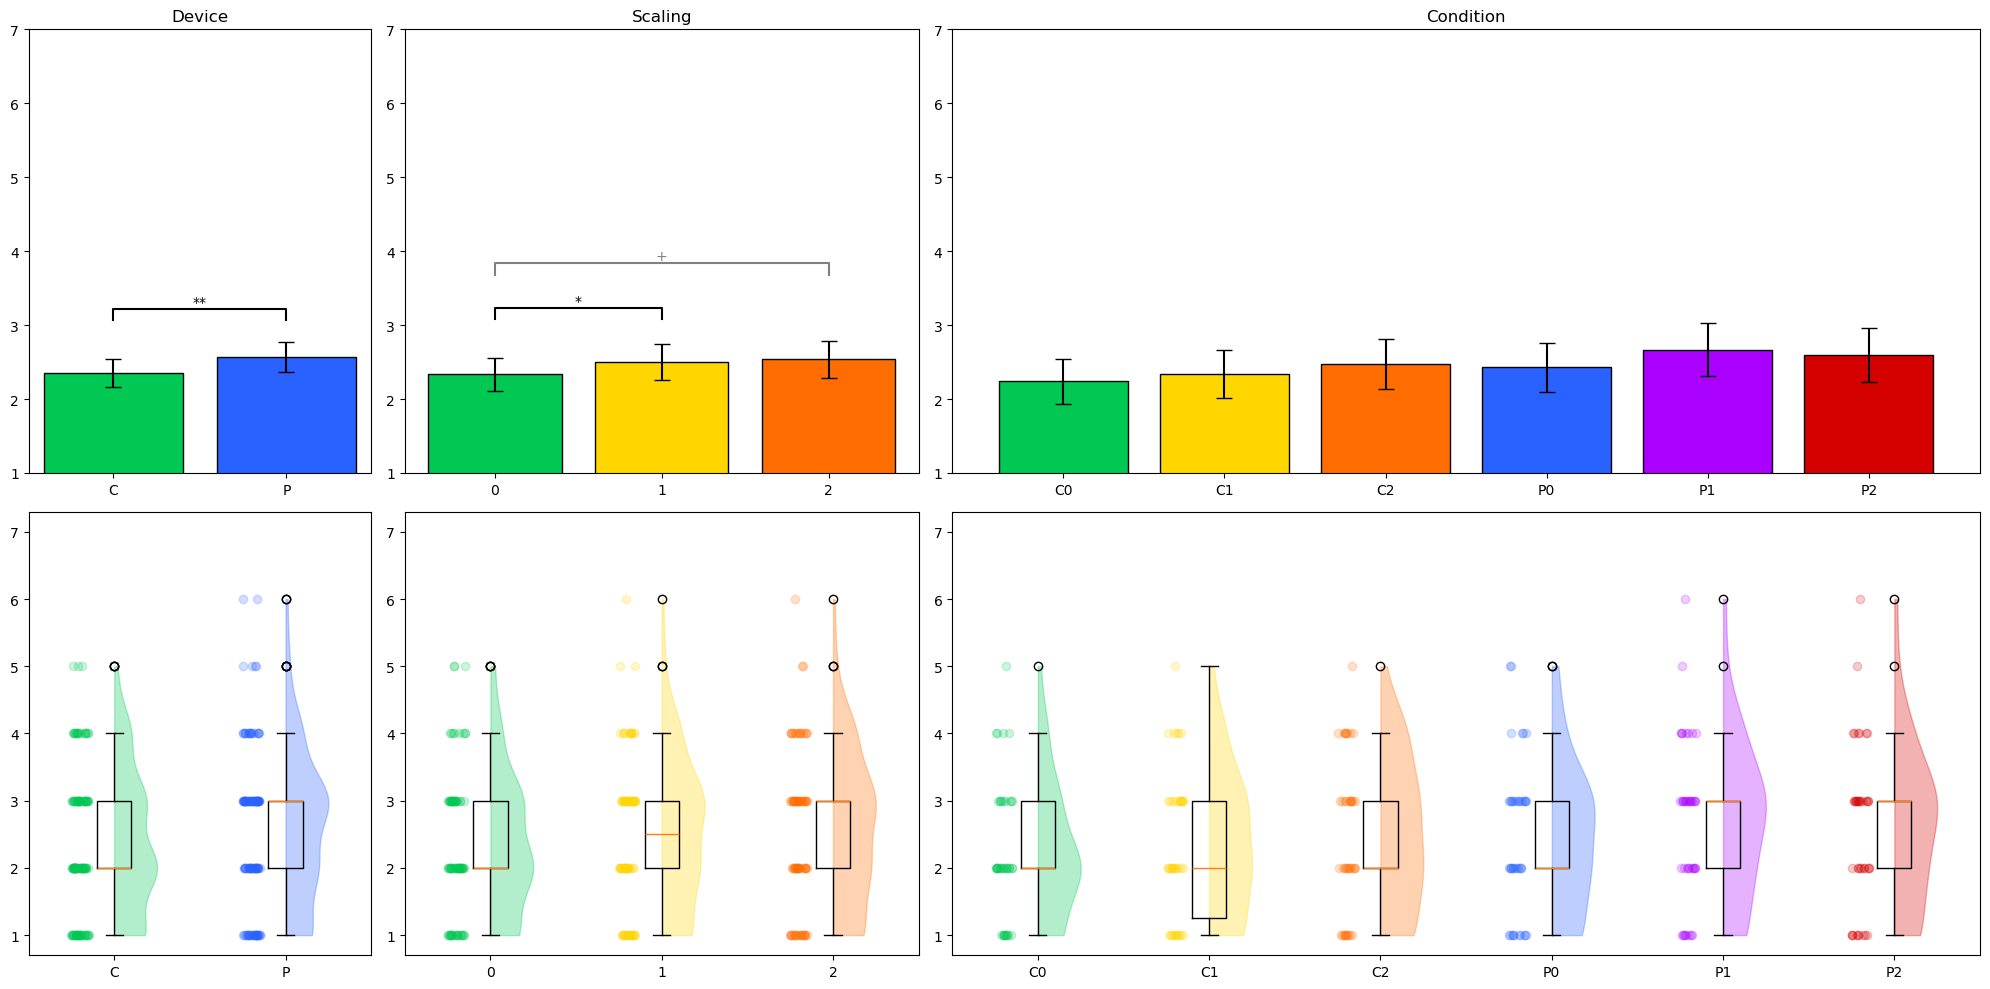

{'aov':              Source        SS  ddof1  ddof2        MS         F     p-unc  \
 0            Device  2.892857      1     41  2.892857  9.165593  0.004251   
 1           Scaling  1.960317      2     82  0.980159  4.221342  0.017991   
 2  Device * Scaling  0.500000      2     82  0.250000  1.069565  0.347896   
 
    p-GG-corr       ng2       eps Significance  
 0   0.004251  0.009330  1.000000            ✅  
 1   0.023958  0.006341  0.848962            ✅  
 2   0.338439  0.001625  0.830403            ❌  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -3.027473  41.0   two-sided   
 1  Scaling      -  0  1   True       True -2.553963  41.0   two-sided   
 2  Scaling      -  0  2   True       True -2.283185  41.0   two-sided   
 3  Scaling      -  1  2   True       True -0.534212  41.0   two-sided   
 
       p-unc    p-corr p-adjust   BF10    hedges Significance  
 0  0.004251       NaN      NaN  8

In [366]:
sp_fatigue_numeric = 'sp_fatigue_numeric'
#Format: X - ...
data[sp_fatigue_numeric] = data.apply(lambda x: int(x[sp_fatigue].split()[0]), axis = 1)

title = 'Samn-Perelli Fatigue Level'
score = sp_fatigue_numeric
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Perceived Weight ------
Mean & 2.81 & 2.67 & 2.74 & 6.14 & 6.29 & 6.21 \\
Standard Deviation & 1.56 & 1.63 & 1.63 & 1.37 & 1.18 & 1.04 \\
Minimum & 1 & 1 & 1 & 1 & 1 & 3 \\
Maximum & 7 & 7 & 7 & 7 & 7 & 7 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,761.285714,1,41,761.285714,178.650041,1.556154e-16,1.556154e-16,0.599438,1.000000,✅
1,Scaling,0.000000,2,82,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.965876,❌
2,Device * Scaling,0.857143,2,82,0.428571,0.584323,5.597873e-01,5.290503e-01,0.001682,0.827061,❌


Device & (1, 41) & 178.65 & \textbf{0.0} & 0.5994 \\
Scaling & (2, 82) & 0.0 & 1.0 & 0.0 \\
Device * Scaling & (2, 82) & 0.58 & 0.52905 & 0.0017 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-13.366003,41.0,two-sided,1.556154e-16,NaN,NaN,3.837e+13,-2.739345,✅


Device P-C & 41 & 13.37 & \textbf{0.0} & 2.7393 \\


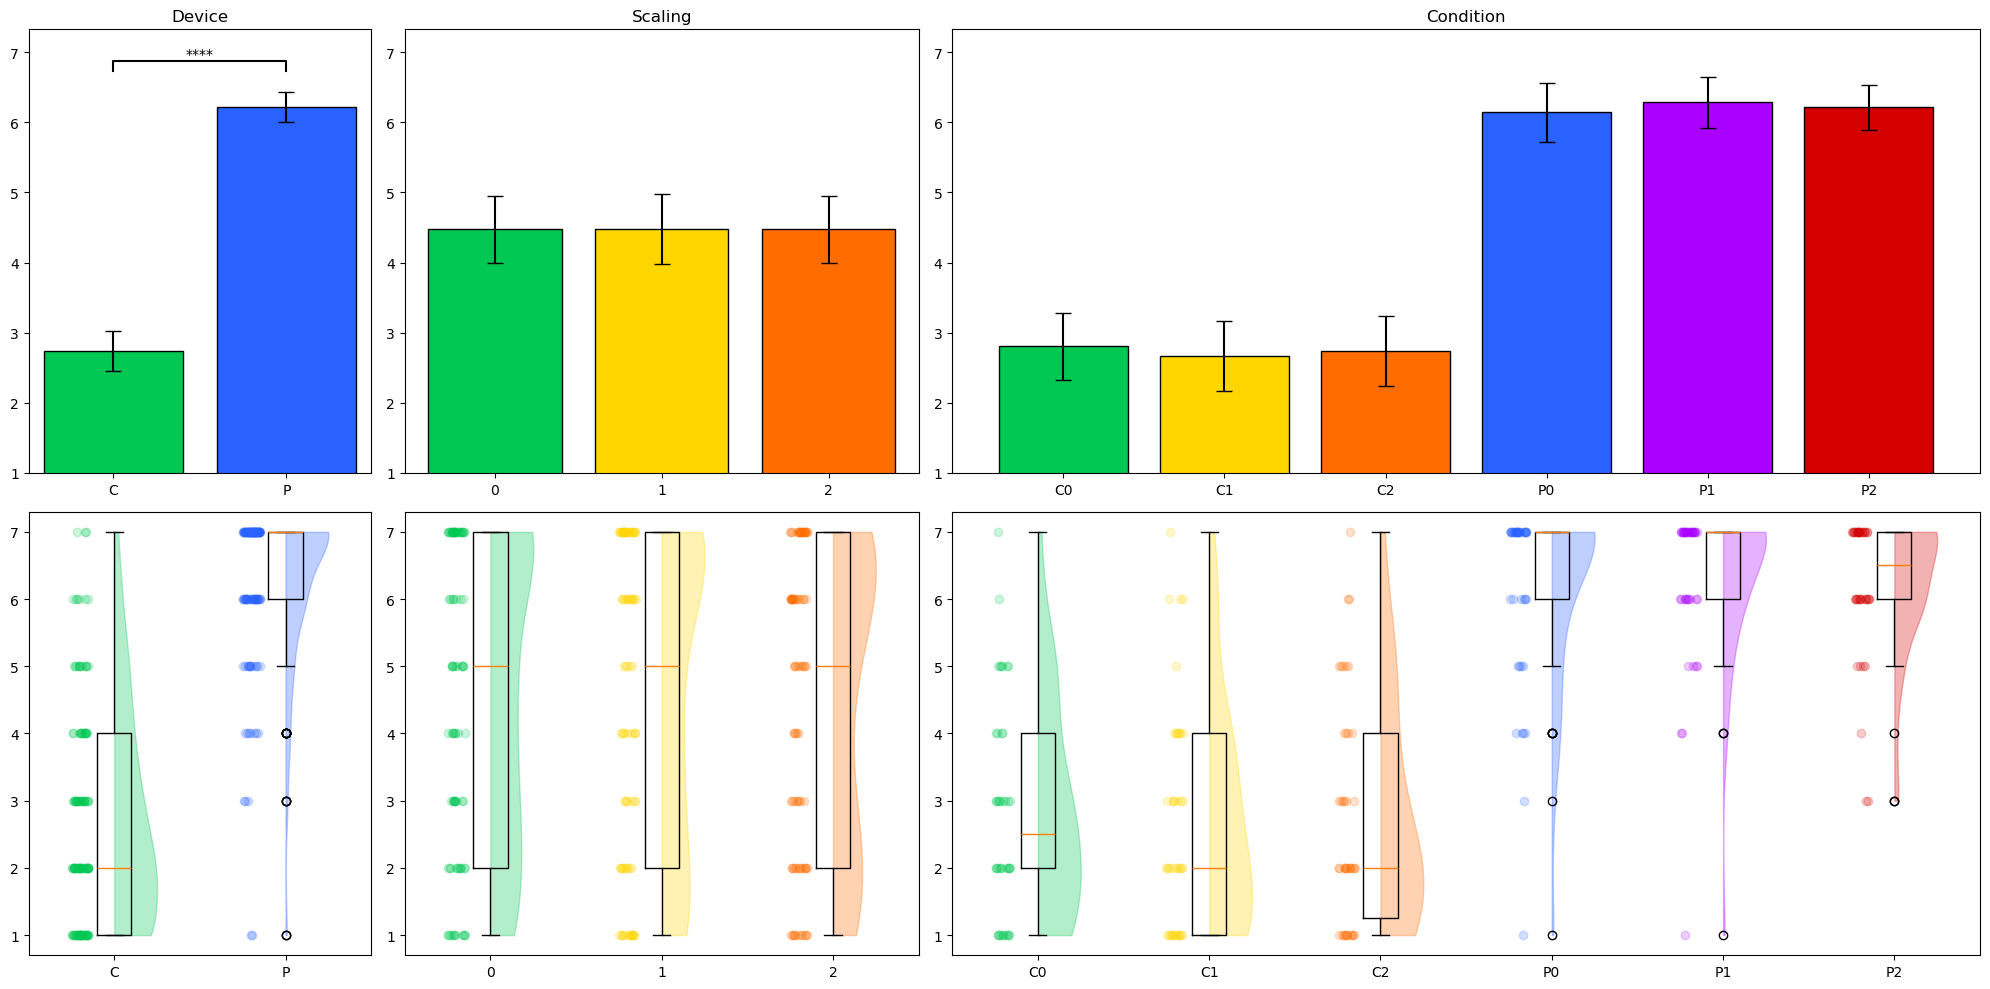

------ [Shovel] Perceived Weight ------
Mean & 2.69 & 2.83 & 2.79 & 5.67 & 5.88 & 5.88 \\
Standard Deviation & 1.41 & 1.56 & 1.61 & 1.86 & 1.75 & 1.71 \\
Minimum & 1 & 1 & 1 & 1 & 1 & 1 \\
Maximum & 6 & 7 & 7 & 7 & 7 & 7 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,582.099206,1,41,582.099206,100.389741,1.385897e-12,1.385897e-12,0.457581,1.00000,✅
1,Scaling,1.579365,2,82,0.789683,1.182635,3.116421e-01,2.988463e-01,0.002284,0.69193,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.107493,8.982094e-01,8.568303e-01,0.000218,0.80601,❌


Device & (1, 41) & 100.39 & \textbf{0.0} & 0.4576 \\
Scaling & (2, 82) & 1.18 & 0.298846 & 0.0023 \\
Device * Scaling & (2, 82) & 0.11 & 0.85683 & 0.0002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-10.019468,41.0,two-sided,1.385897e-12,NaN,NaN,6.071e+09,-1.965267,✅


Device P-C & 41 & 10.02 & \textbf{0.0} & 1.9653 \\


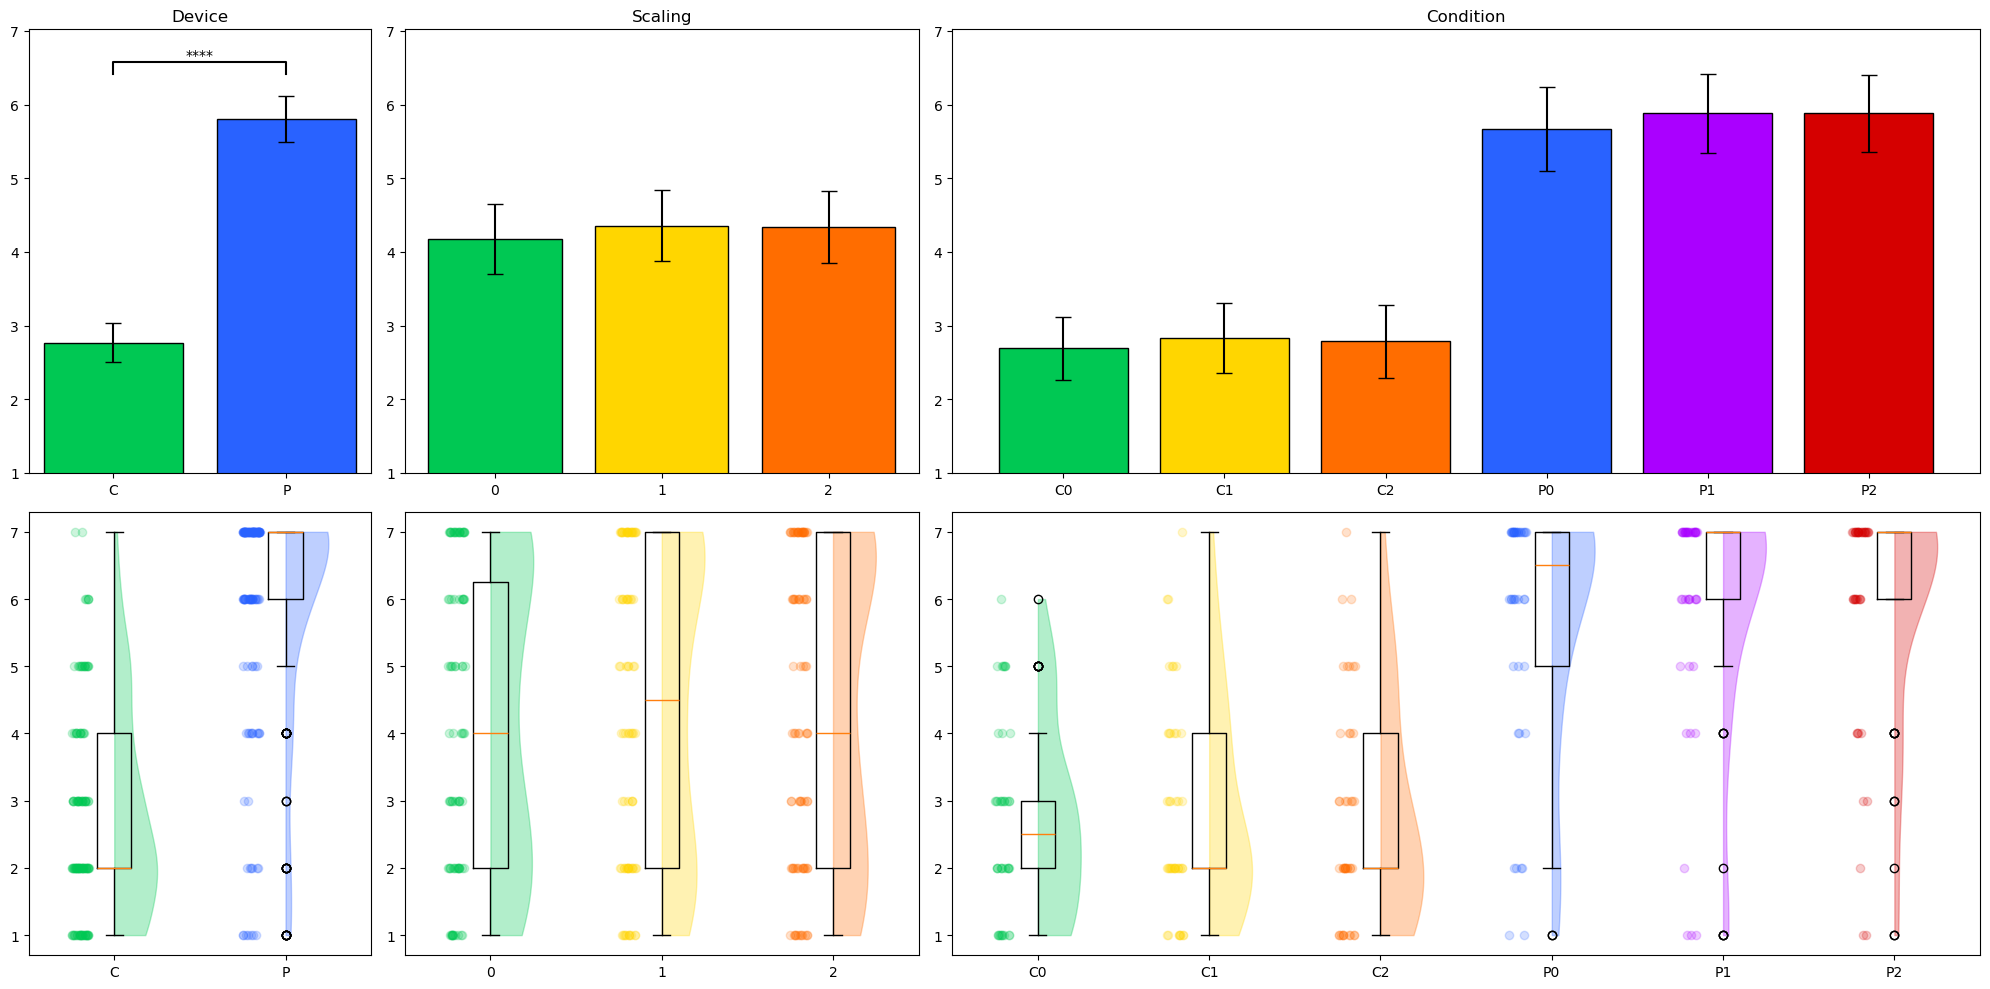

------ [Cube] Perceived Weight Realism ------
Mean & 2.74 & 2.79 & 2.76 & 6.12 & 6.1 & 6.07 \\
Standard Deviation & 1.59 & 1.75 & 1.63 & 1.31 & 1.23 & 1.24 \\
Minimum & 1 & 1 & 1 & 1 & 2 & 2 \\
Maximum & 7 & 7 & 7 & 7 & 7 & 7 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,700.000000,1,41,700.000000,188.402626,6.357494e-17,6.357494e-17,0.561069,1.000000,✅
1,Scaling,0.023810,2,82,0.011905,0.011908,9.881641e-01,9.854520e-01,0.000043,0.946549,❌
2,Device * Scaling,0.071429,2,82,0.035714,0.042694,9.582263e-01,9.522768e-01,0.000130,0.948907,❌


Device & (1, 41) & 188.4 & \textbf{0.0} & 0.5611 \\
Scaling & (2, 82) & 0.01 & 0.985452 & 0.0 \\
Device * Scaling & (2, 82) & 0.04 & 0.952277 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-13.725984,41.0,two-sided,6.357494e-17,NaN,NaN,9.107e+13,-2.599694,✅


Device P-C & 41 & 13.73 & \textbf{0.0} & 2.5997 \\


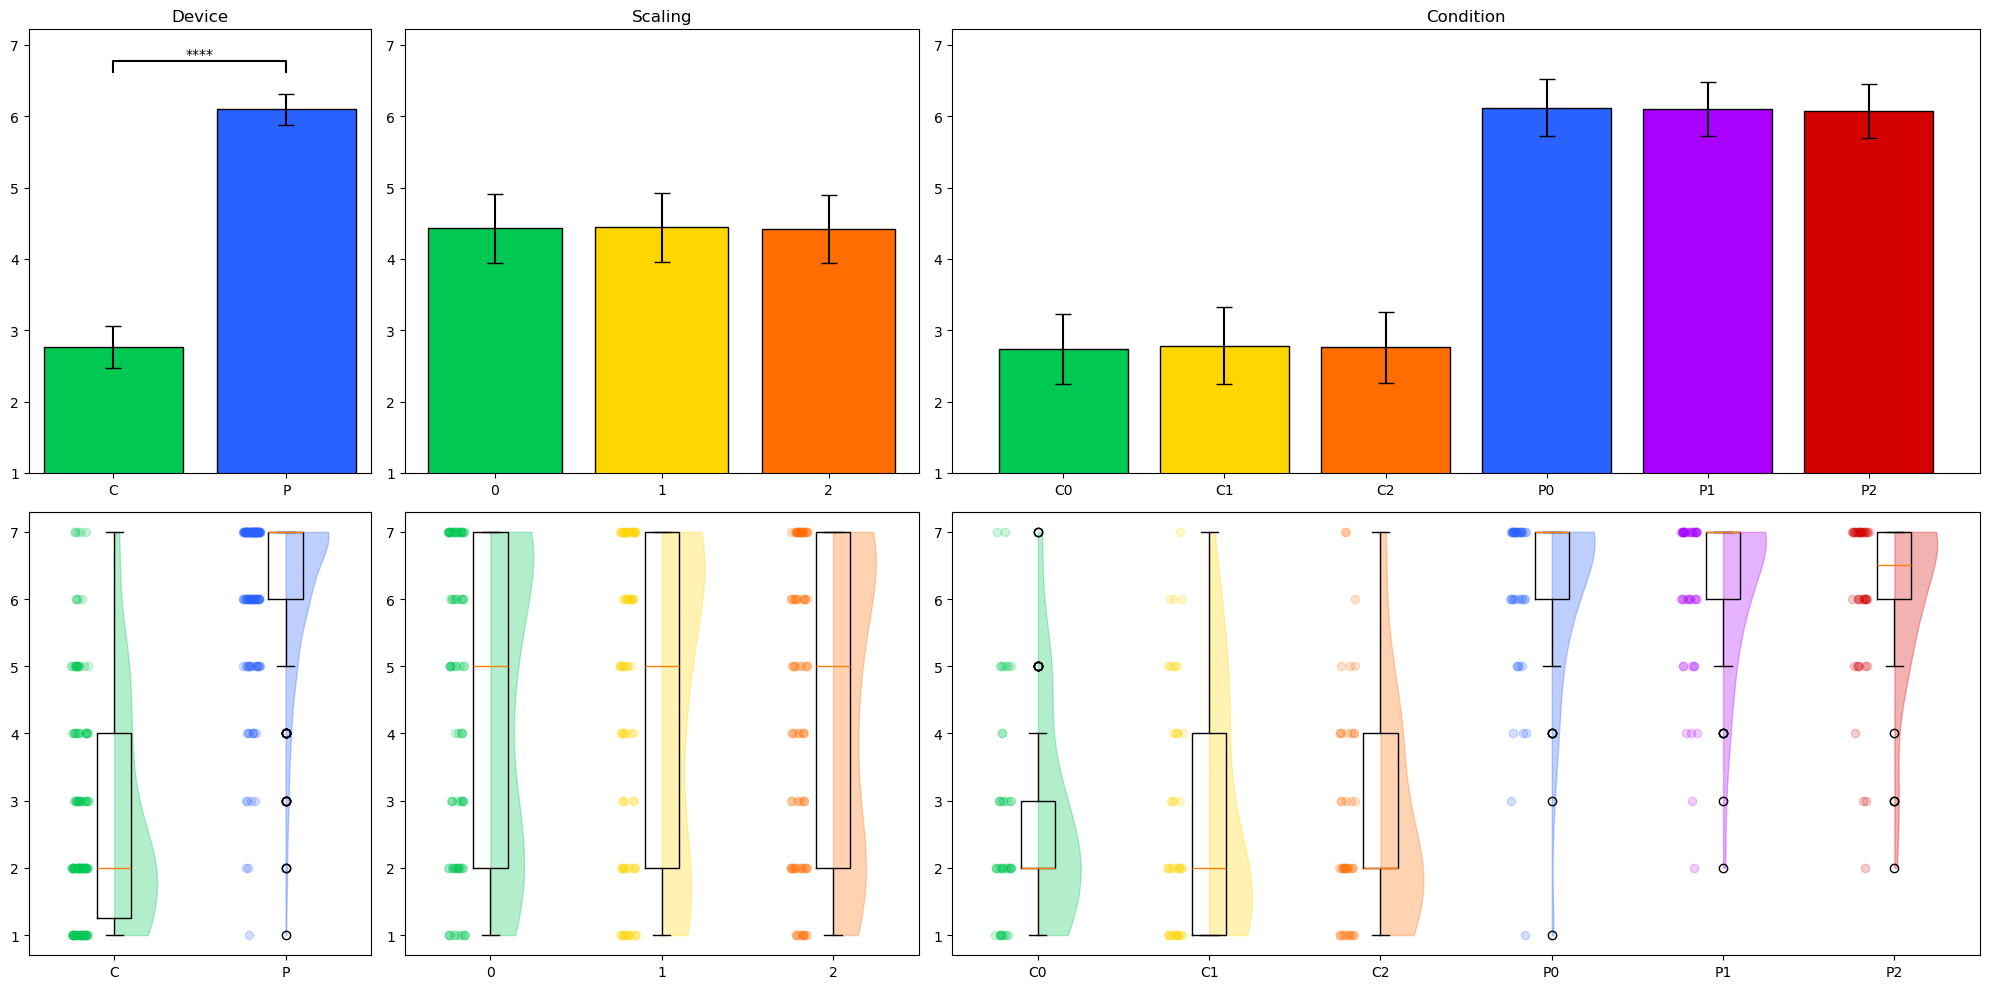

------ [Shovel] Perceived Weight Realism ------
Mean & 2.6 & 2.81 & 2.5 & 5.69 & 5.83 & 5.71 \\
Standard Deviation & 1.51 & 1.69 & 1.37 & 1.75 & 1.66 & 1.78 \\
Minimum & 1 & 1 & 1 & 1 & 1 & 1 \\
Maximum & 6 & 7 & 6 & 7 & 7 & 7 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,609.777778,1,41,609.777778,109.227184,3.954738e-13,3.954738e-13,0.475551,1.000000,✅
1,Scaling,2.214286,2,82,1.107143,1.501772,2.287965e-01,2.311220e-01,0.003282,0.805989,❌
2,Device * Scaling,0.388889,2,82,0.194444,0.261623,7.704416e-01,7.702826e-01,0.000578,0.999269,❌


Device & (1, 41) & 109.23 & \textbf{0.0} & 0.4756 \\
Scaling & (2, 82) & 1.5 & 0.231122 & 0.0033 \\
Device * Scaling & (2, 82) & 0.26 & 0.770283 & 0.0006 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-10.451181,41.0,two-sided,3.954738e-13,NaN,NaN,2.021e+10,-2.059554,✅


Device P-C & 41 & 10.45 & \textbf{0.0} & 2.0596 \\


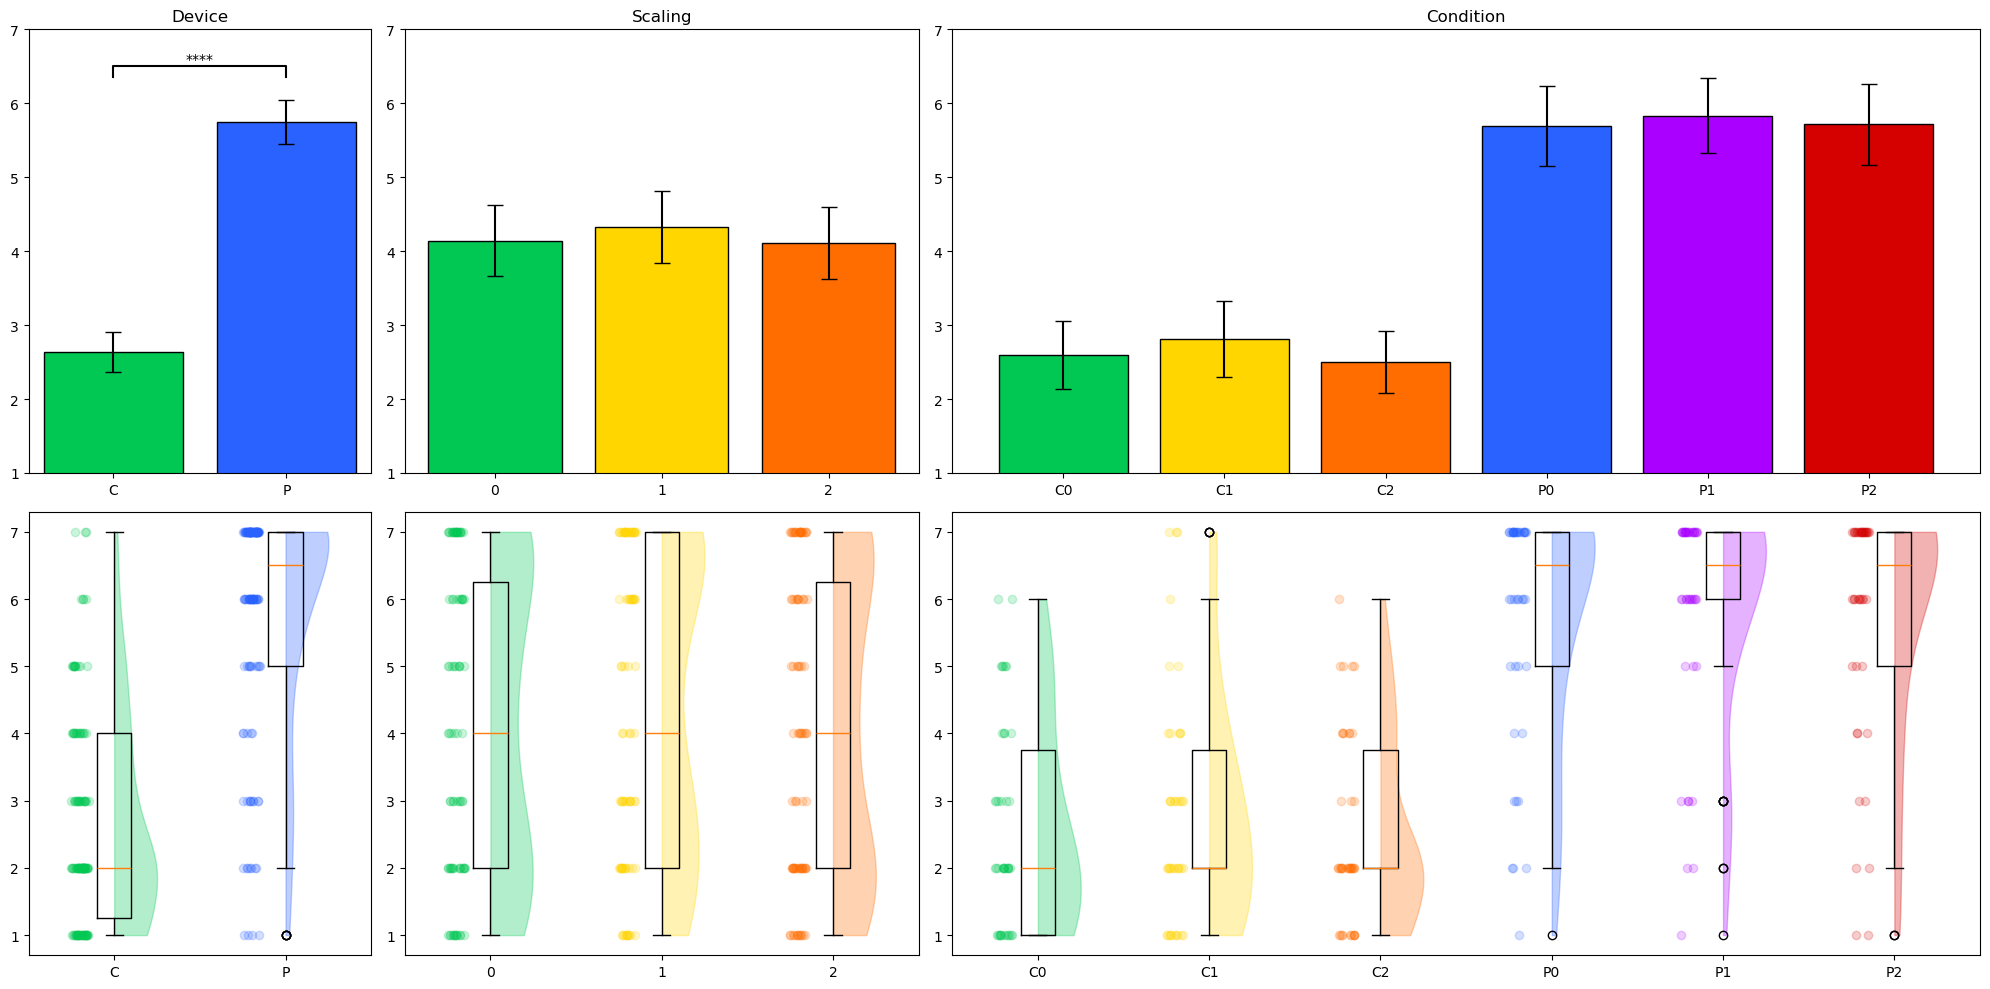

------ [Cube] Static Weight Perception ------
Mean & 2.77 & 2.73 & 2.75 & 6.13 & 6.19 & 6.14 \\
Standard Deviation & 1.54 & 1.64 & 1.56 & 1.28 & 1.14 & 1.04 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.5 & 3.0 \\
Maximum & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,730.321429,1,41,730.321429,193.270862,4.124797e-17,4.124797e-17,0.601188,1.000000,✅
1,Scaling,0.005952,2,82,0.002976,0.004320,9.956897e-01,9.946631e-01,0.000012,0.956101,❌
2,Device * Scaling,0.125000,2,82,0.062500,0.094253,9.101511e-01,8.814536e-01,0.000258,0.851850,❌


Device & (1, 41) & 193.27 & \textbf{0.0} & 0.6012 \\
Scaling & (2, 82) & 0.0 & 0.994663 & 0.0 \\
Device * Scaling & (2, 82) & 0.09 & 0.881454 & 0.0003 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-13.902189,41.0,two-sided,4.124797e-17,NaN,NaN,1.383e+14,-2.737436,✅


Device P-C & 41 & 13.9 & \textbf{0.0} & 2.7374 \\


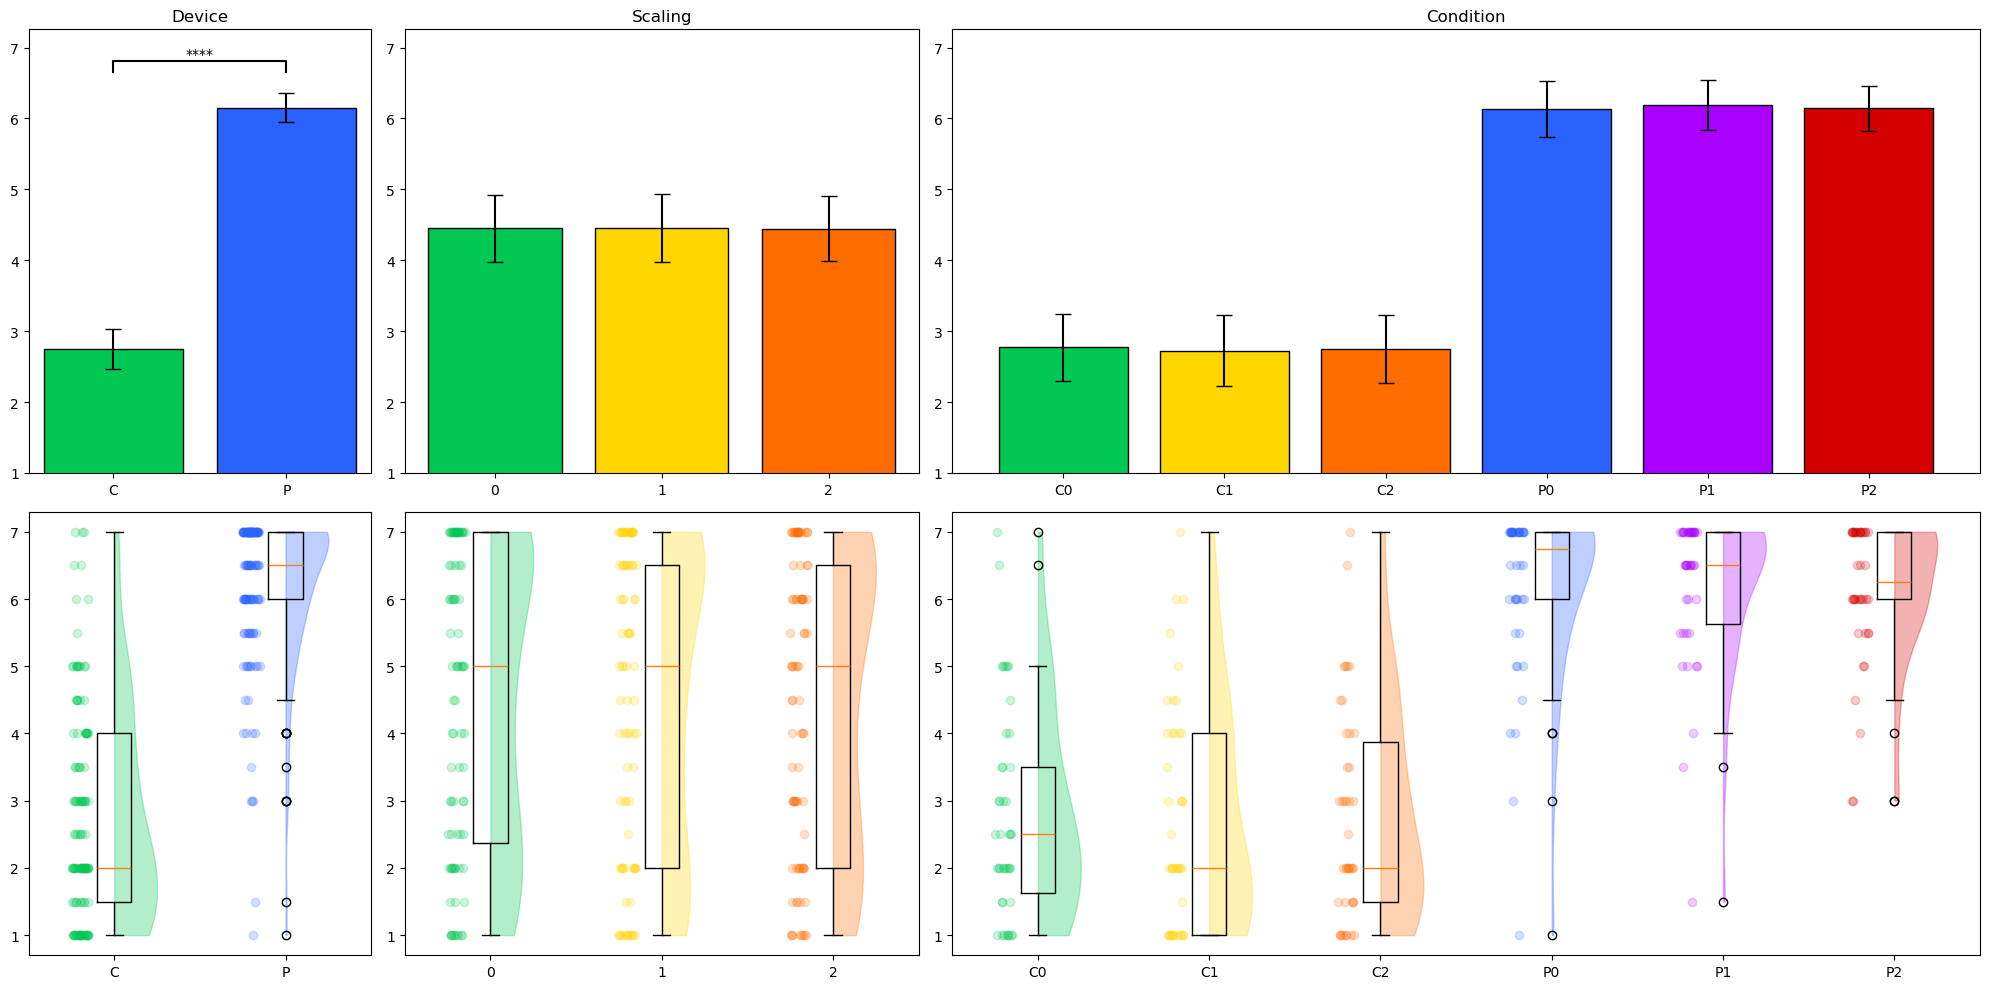

------ [Shovel] Static Weight Perception ------
Mean & 2.64 & 2.82 & 2.64 & 5.68 & 5.86 & 5.8 \\
Standard Deviation & 1.39 & 1.55 & 1.4 & 1.76 & 1.65 & 1.69 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 5.5 & 7.0 & 6.0 & 7.0 & 7.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,595.858135,1,41,595.858135,107.416806,5.081530e-13,5.081530e-13,0.486559,1.000000,✅
1,Scaling,1.388889,2,82,0.694444,1.183603,3.113492e-01,3.002442e-01,0.002204,0.719932,❌
2,Device * Scaling,0.198413,2,82,0.099206,0.160658,8.518504e-01,8.307459e-01,0.000315,0.903254,❌


Device & (1, 41) & 107.42 & \textbf{0.0} & 0.4866 \\
Scaling & (2, 82) & 1.18 & 0.300244 & 0.0022 \\
Device * Scaling & (2, 82) & 0.16 & 0.830746 & 0.0003 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-10.364208,41.0,two-sided,5.081530e-13,NaN,NaN,1.589e+10,-2.075937,✅


Device P-C & 41 & 10.36 & \textbf{0.0} & 2.0759 \\


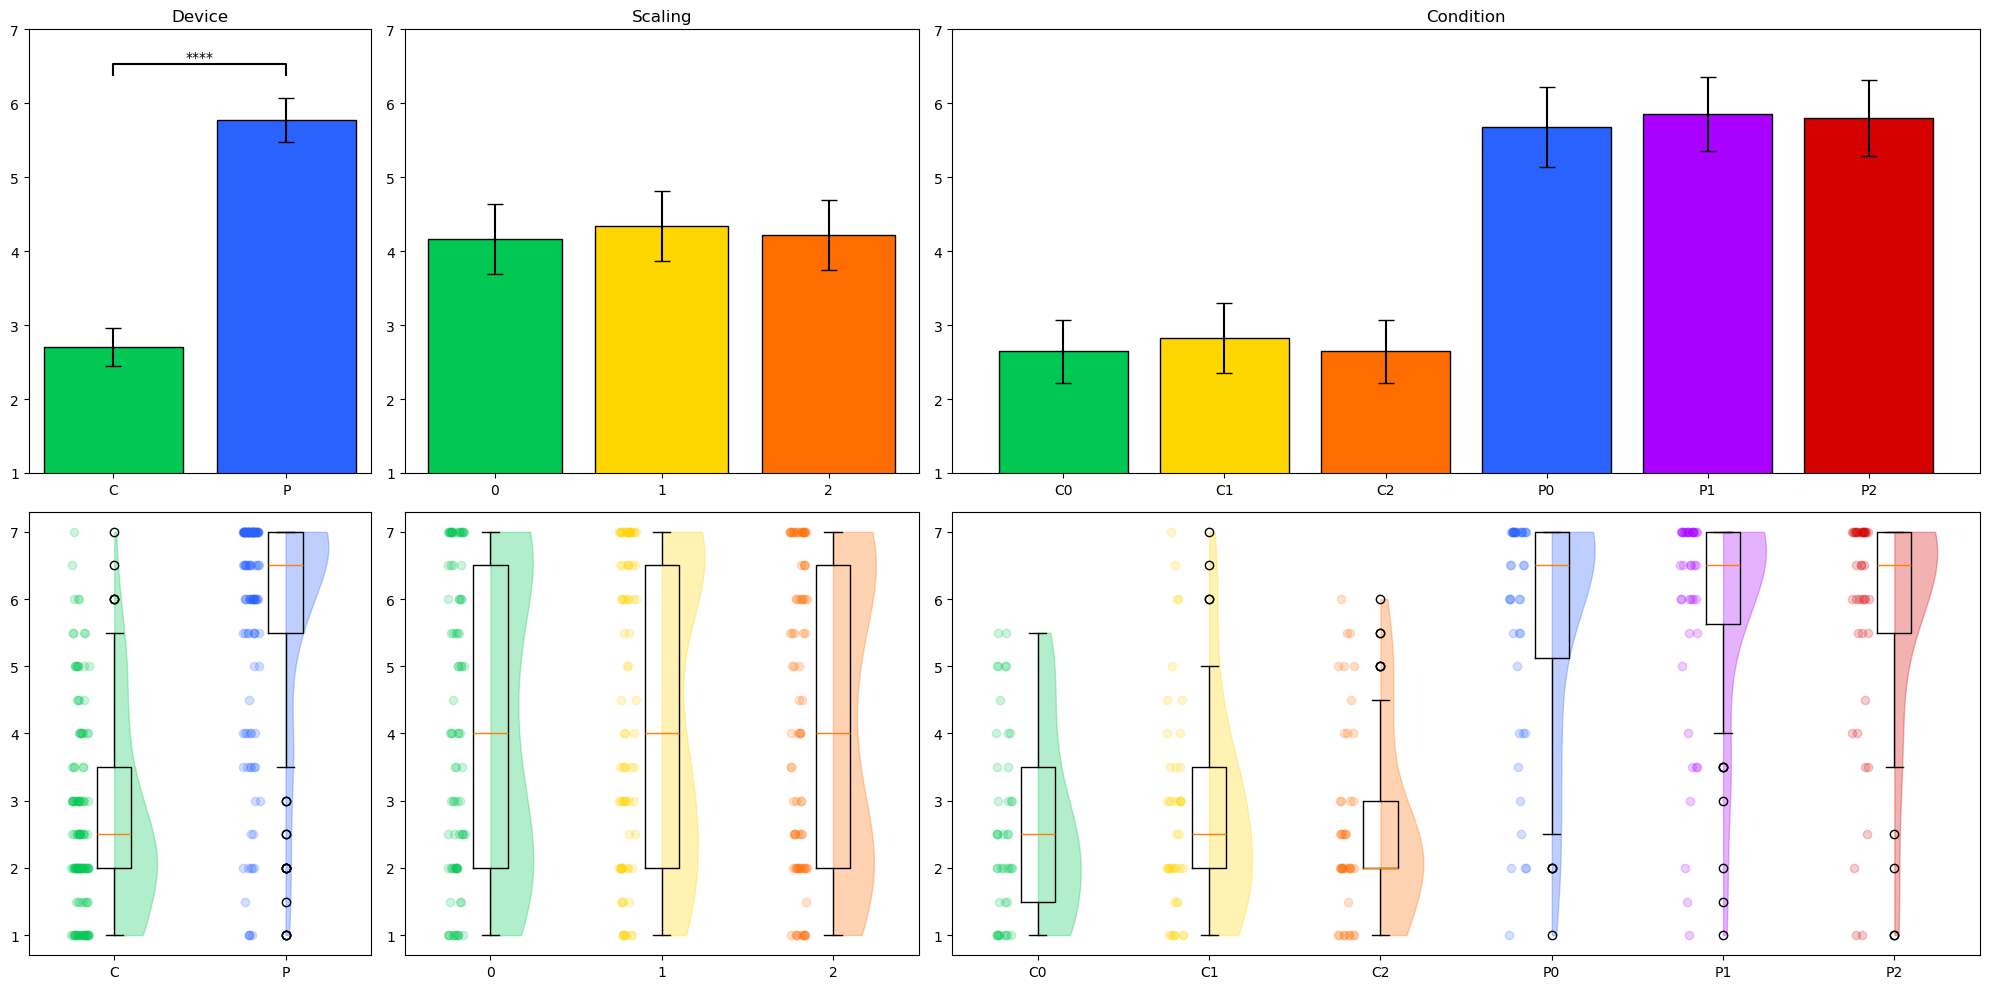

In [367]:
scale = [1,7]

general_perceived_weight = 'general_perceived_weight'
data[general_perceived_weight] = data[general_1]
title = 'Perceived Weight'
score = general_perceived_weight
cube_weight = report_exeriment(data, cube, score, title,scale)
shovel_weight = report_exeriment(data, shovel, score, title, scale)

general_perceived_weight_realism = 'general_perceived_weight_realism'
data[general_perceived_weight_realism] = data[general_2]
title = 'Perceived Weight Realism'
score = general_perceived_weight_realism
scale = [1,7]
cube_weight_realism = report_exeriment(data, cube, score, title,scale)
shovel_weight_realism = report_exeriment(data, shovel, score, title, scale)

static_weight = 'static_weight'
data[static_weight] = data.apply(lambda x: 
    (x[general_perceived_weight_realism] + x[general_perceived_weight]) / 2,
    axis = 1)
title = 'Static Weight Perception'
score = static_weight
cube_weight_total = report_exeriment(data, cube, score, title,scale)
shovel_weight_total =report_exeriment(data, shovel, score, title, scale)

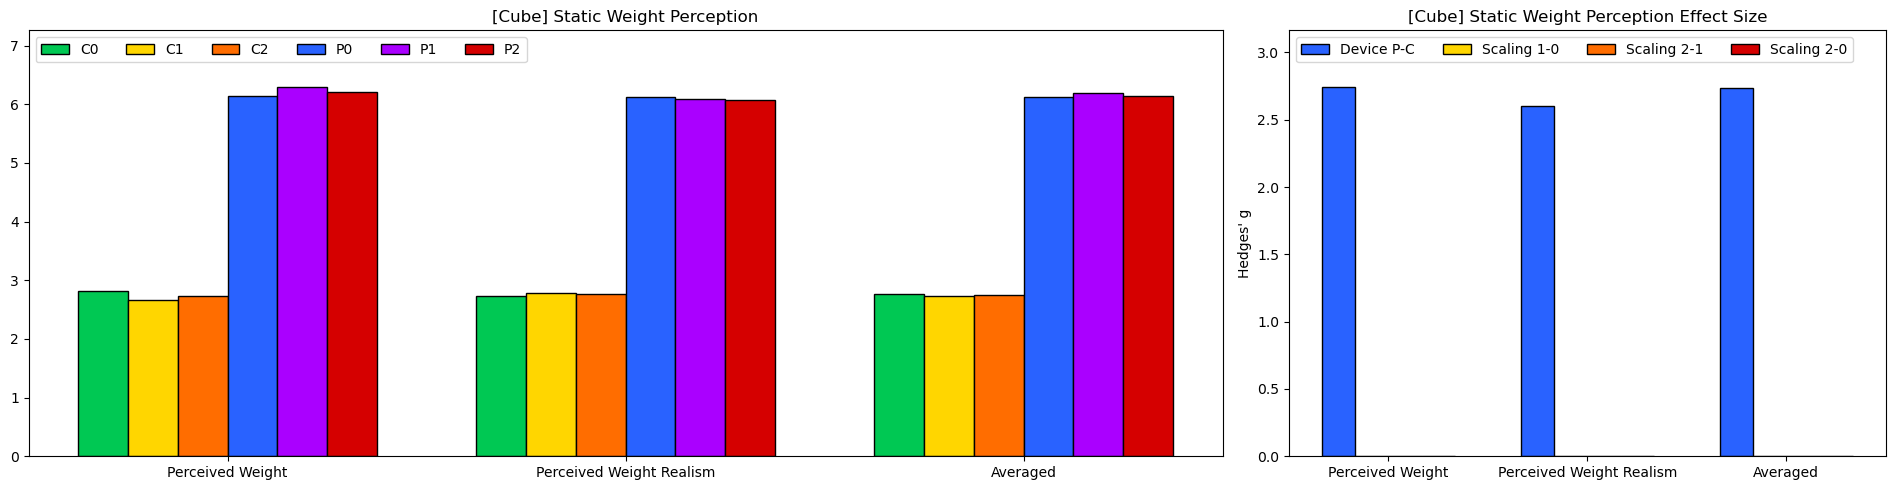

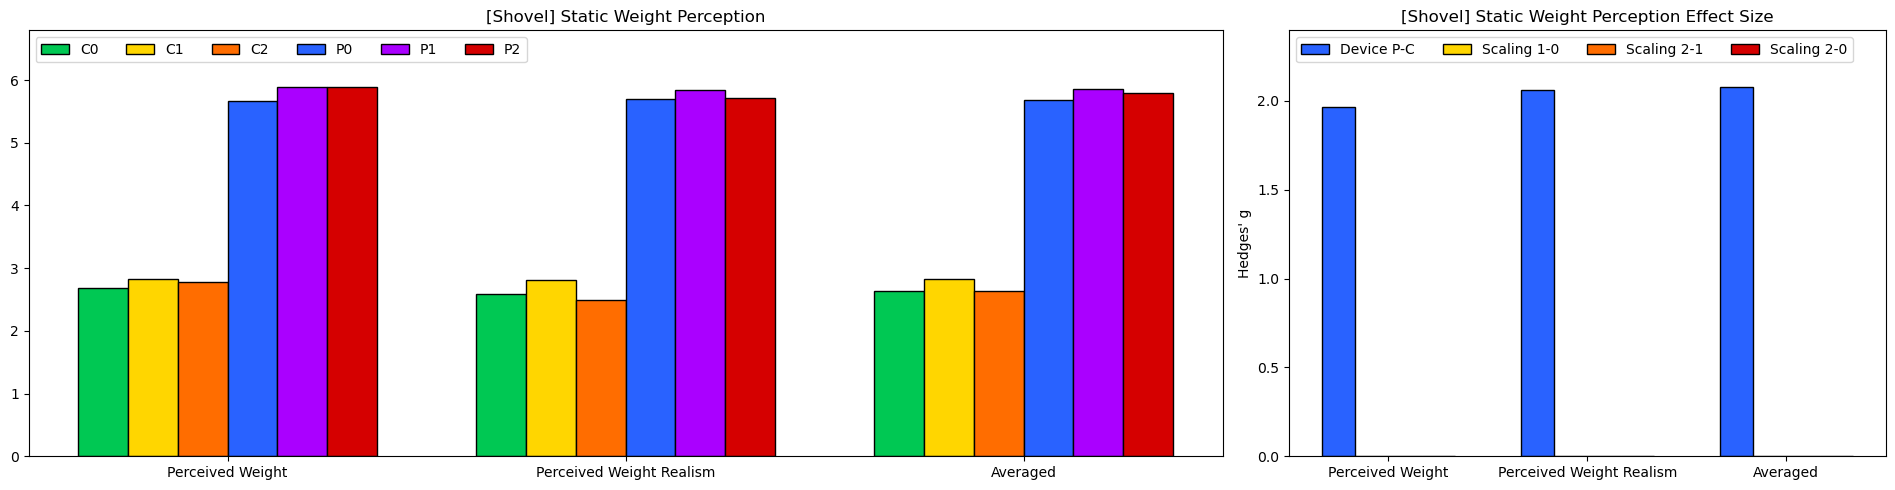

In [368]:
def get_static_weight_splits(data, e):
    exp_data = data[data[task] == e]
    weight = []
    weight_realism = []
    weight_total = []

    for c in conditions:
        condition_data = exp_data[exp_data[condition_key] == c]
        weight.append(np.mean(condition_data[general_perceived_weight]))
        weight_realism.append(np.mean(condition_data[general_perceived_weight_realism]))
        weight_total.append(np.mean(condition_data[static_weight]))

    return [weight, weight_realism, weight_total]

labels = ["Perceived Weight", "Perceived Weight Realism", "Averaged"]
ylabel = ''
cube_title = "[Cube] Static Weight Perception"
cube_static_weight_splits = get_static_weight_splits(data, cube)
cube_static_weight_aovs = [cube_weight, cube_weight_realism, cube_weight_total]
report_comparison(cube_static_weight_splits, cube_static_weight_aovs, labels, cube_title, ylabel)

shovel_title = "[Shovel] Static Weight Perception"
shovel_static_weight_splits = get_static_weight_splits(data, shovel)
shovel_static_weight_aovs = [shovel_weight, shovel_weight_realism, shovel_weight_total]
report_comparison(shovel_static_weight_splits, shovel_static_weight_aovs, labels, shovel_title, ylabel)

------ [Shovel] Perceived weight increase (Load) ------
Mean & 2.1 & 2.4 & 2.67 & 2.4 & 2.33 & 2.6 \\
Standard Deviation & 1.34 & 1.59 & 1.87 & 1.36 & 1.44 & 1.65 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 6.0 & 6.0 & 7.0 & 5.0 & 6.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.194444,1,41,0.194444,0.116714,0.734371,0.734371,0.000319,1.000000,❌
1,Scaling,6.380952,2,82,3.190476,5.380999,0.006371,0.013779,0.010375,0.720851,✅
2,Device * Scaling,2.031746,2,82,1.015873,1.773572,0.176174,0.180247,0.003327,0.895166,❌


Device & (1, 41) & 0.12 & 0.734371 & 0.0003 \\
Scaling & (2, 82) & 5.38 & \textbf{0.013779} & 0.0104 \\
Device * Scaling & (2, 82) & 1.77 & 0.180247 & 0.0033 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.238722,41.0,two-sided,0.222494,0.222494,holm,0.34,-0.089745,❌
2,Scaling,-,0,2,True,True,-2.518332,41.0,two-sided,0.015789,0.039761,holm,2.717,-0.262031,✅
3,Scaling,-,1,2,True,True,-2.589219,41.0,two-sided,0.013254,0.039761,holm,3.151,-0.174397,✅


Scaling 1-0 & 41 & 1.24 & 0.222494 & 0.0897 \\
Scaling 2-0 & 41 & 2.52 & \textbf{0.039761} & 0.262 \\
Scaling 2-1 & 41 & 2.59 & \textbf{0.039761} & 0.1744 \\


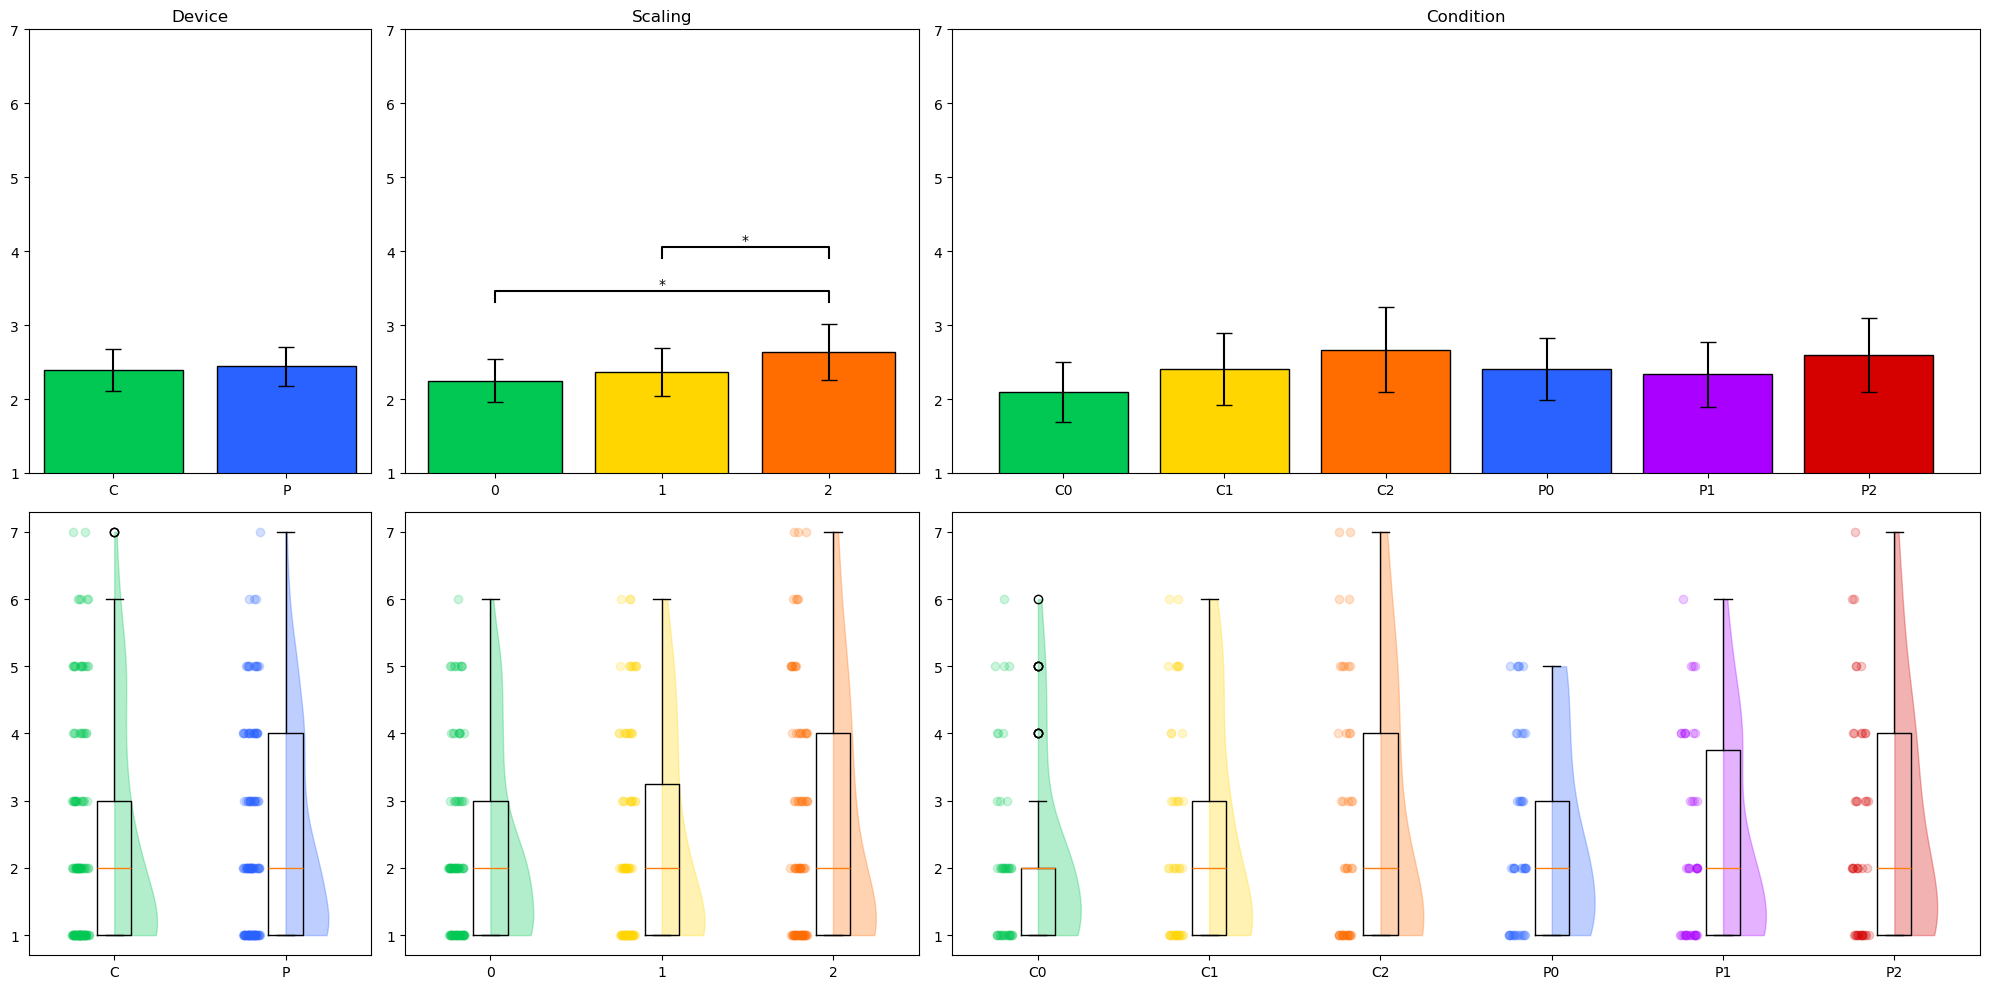

------ [Shovel] Perceived weight decrease (Unload) ------
Mean & 2.19 & 2.5 & 2.67 & 2.4 & 2.36 & 2.64 \\
Standard Deviation & 1.31 & 1.47 & 1.67 & 1.46 & 1.51 & 1.69 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 6.0 & 5.0 & 7.0 & 6.0 & 6.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.015873,1,41,0.015873,0.011625,0.914666,0.914666,0.000027,1.000000,❌
1,Scaling,5.484127,2,82,2.742063,4.799424,0.010688,0.016689,0.009276,0.808341,✅
2,Device * Scaling,1.388889,2,82,0.694444,1.023976,0.363710,0.360663,0.002366,0.948589,❌


Device & (1, 41) & 0.01 & 0.914666 & 0.0 \\
Scaling & (2, 82) & 4.8 & \textbf{0.016689} & 0.0093 \\
Device * Scaling & (2, 82) & 1.02 & 0.360663 & 0.0024 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.357271,41.0,two-sided,0.182120,0.182120,holm,0.391,-0.098663,❌
2,Scaling,-,0,2,True,True,-2.517977,41.0,two-sided,0.015803,0.047408,holm,2.715,-0.252327,✅
3,Scaling,-,1,2,True,True,-2.120067,41.0,two-sided,0.040098,0.080197,holm,1.254,-0.155182,🟨


Scaling 1-0 & 41 & 1.36 & 0.18212 & 0.0987 \\
Scaling 2-0 & 41 & 2.52 & \textbf{0.047408} & 0.2523 \\
Scaling 2-1 & 41 & 2.12 & 0.080197 & 0.1552 \\


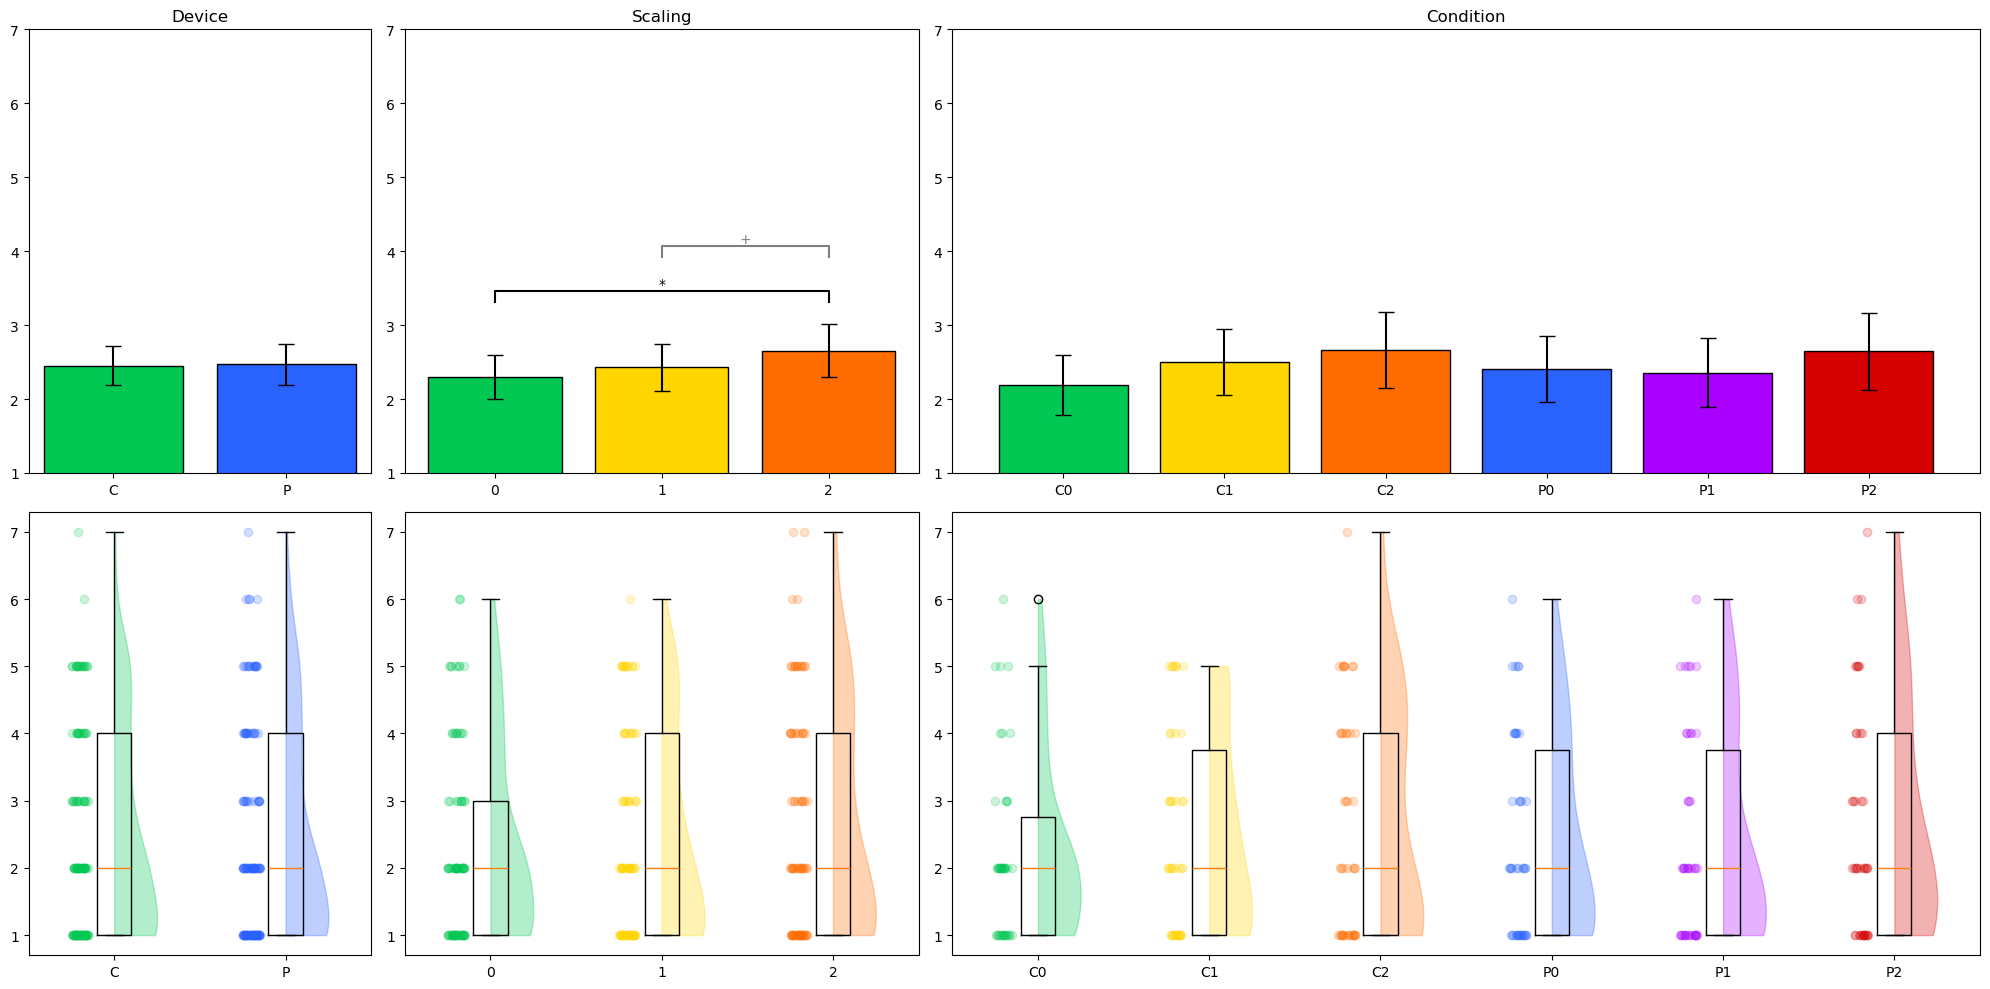

------ [Shovel] Perceived effort increase (Load) ------
Mean & 2.38 & 2.88 & 3.19 & 2.33 & 2.64 & 3.0 \\
Standard Deviation & 1.53 & 1.85 & 2.0 & 1.34 & 1.77 & 1.95 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 7.0 & 7.0 & 7.0 & 5.0 & 6.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.587302,1,41,1.587302,0.637537,0.429205,0.429205,0.002037,1.000000,❌
1,Scaling,22.952381,2,82,11.476190,7.926996,0.000712,0.001336,0.028665,0.865239,✅
2,Device * Scaling,0.412698,2,82,0.206349,0.188173,0.828828,0.802026,0.000530,0.882883,❌


Device & (1, 41) & 0.64 & 0.429205 & 0.002 \\
Scaling & (2, 82) & 7.93 & \textbf{0.001336} & 0.0287 \\
Device * Scaling & (2, 82) & 0.19 & 0.802026 & 0.0005 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.372547,41.0,two-sided,0.022439,0.044878,holm,2.023,-0.277102,✅
2,Scaling,-,0,2,True,True,-3.369682,41.0,two-sided,0.001649,0.004947,holm,19.29,-0.480742,✅
3,Scaling,-,1,2,True,True,-2.054407,41.0,two-sided,0.046348,0.046348,holm,1.115,-0.199723,✅


Scaling 1-0 & 41 & 2.37 & \textbf{0.044878} & 0.2771 \\
Scaling 2-0 & 41 & 3.37 & \textbf{0.004947} & 0.4807 \\
Scaling 2-1 & 41 & 2.05 & \textbf{0.046348} & 0.1997 \\


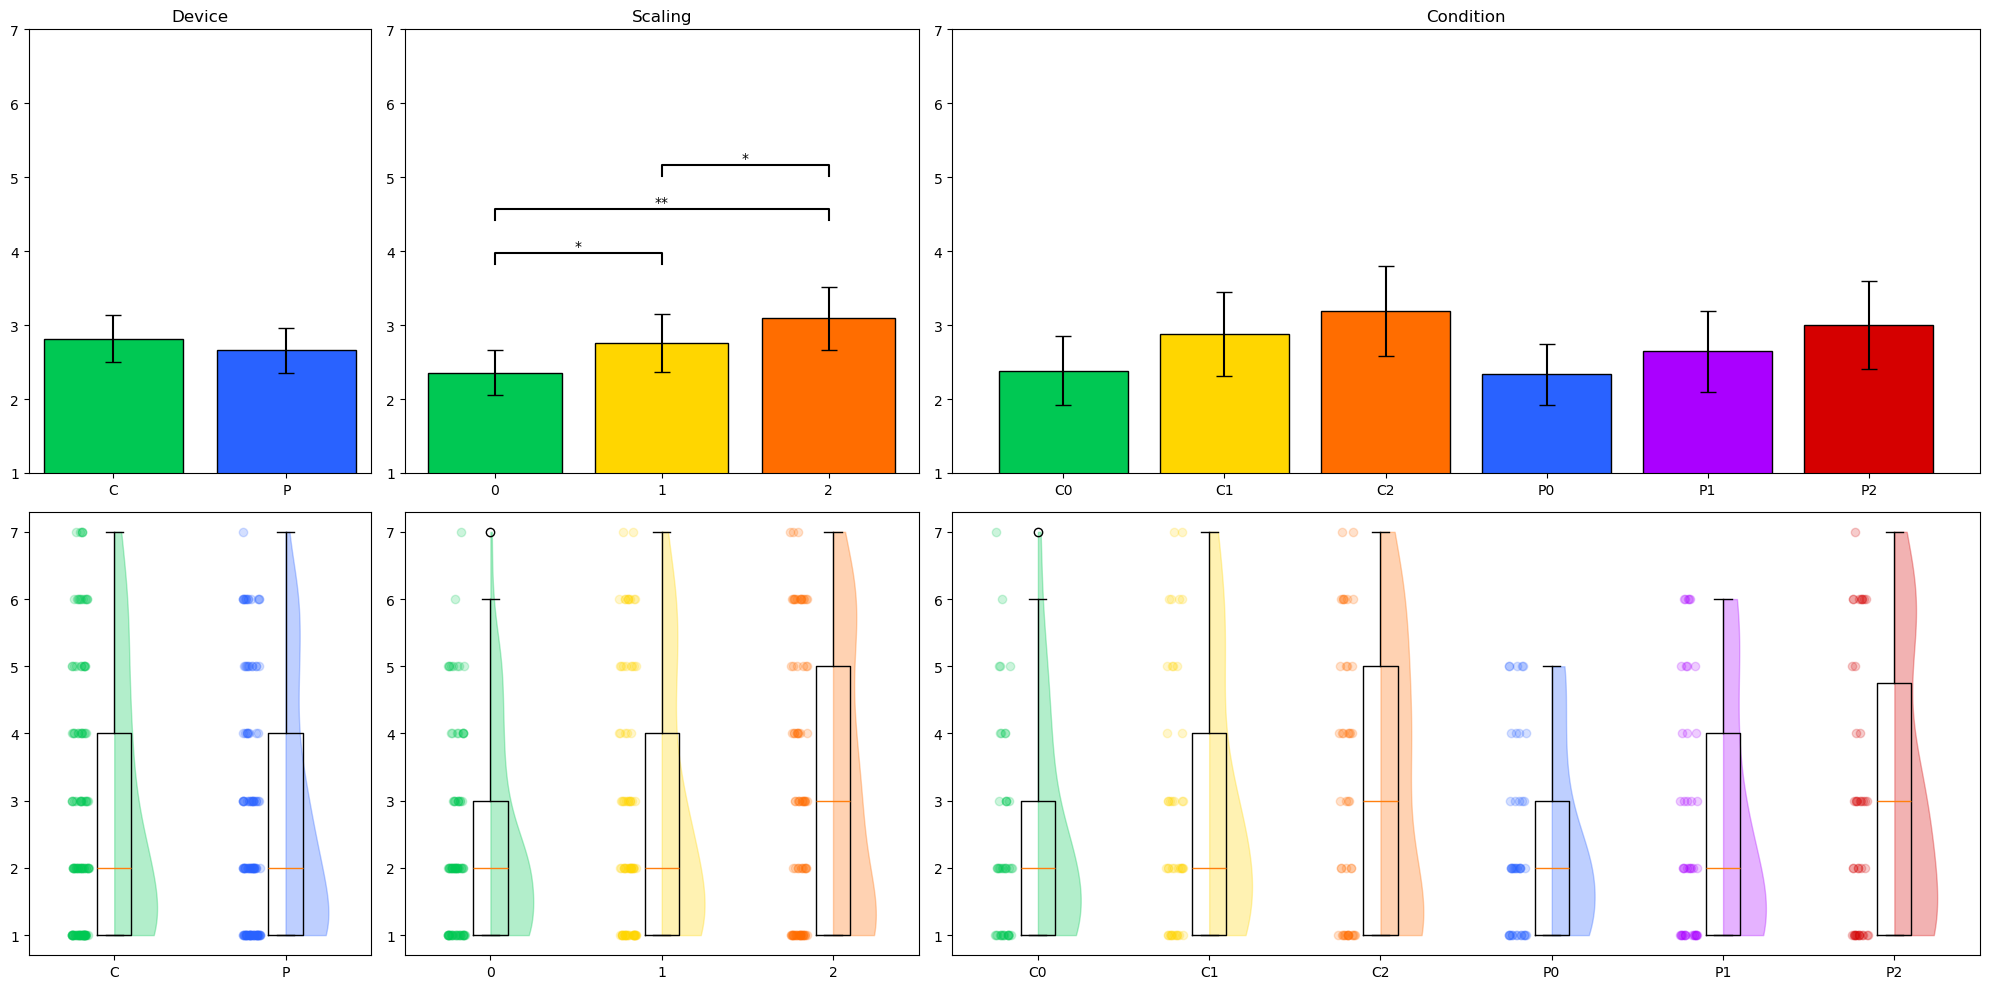

------ [Shovel] Perceived effort decrease (Unload) ------
Mean & 2.38 & 2.86 & 3.19 & 2.31 & 2.52 & 2.88 \\
Standard Deviation & 1.41 & 1.58 & 1.95 & 1.32 & 1.64 & 1.83 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 7.0 & 7.0 & 7.0 & 5.0 & 6.0 & 6.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.571429,1,41,3.571429,1.380162,0.246852,0.246852,0.005260,1.000000,❌
1,Scaling,20.023810,2,82,10.011905,7.182045,0.001336,0.003462,0.028794,0.768635,✅
2,Device * Scaling,0.880952,2,82,0.440476,0.432810,0.650157,0.639074,0.001303,0.945531,❌


Device & (1, 41) & 1.38 & 0.246852 & 0.0053 \\
Scaling & (2, 82) & 7.18 & \textbf{0.003462} & 0.0288 \\
Device * Scaling & (2, 82) & 0.43 & 0.639074 & 0.0013 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.363425,41.0,two-sided,0.022929,0.045858,holm,1.987,-0.267371,✅
2,Scaling,-,0,2,True,True,-3.054799,41.0,two-sided,0.003948,0.011844,holm,8.949,-0.477342,✅
3,Scaling,-,1,2,True,True,-2.095425,41.0,two-sided,0.042351,0.045858,holm,1.199,-0.228872,✅


Scaling 1-0 & 41 & 2.36 & \textbf{0.045858} & 0.2674 \\
Scaling 2-0 & 41 & 3.05 & \textbf{0.011844} & 0.4773 \\
Scaling 2-1 & 41 & 2.1 & \textbf{0.045858} & 0.2289 \\


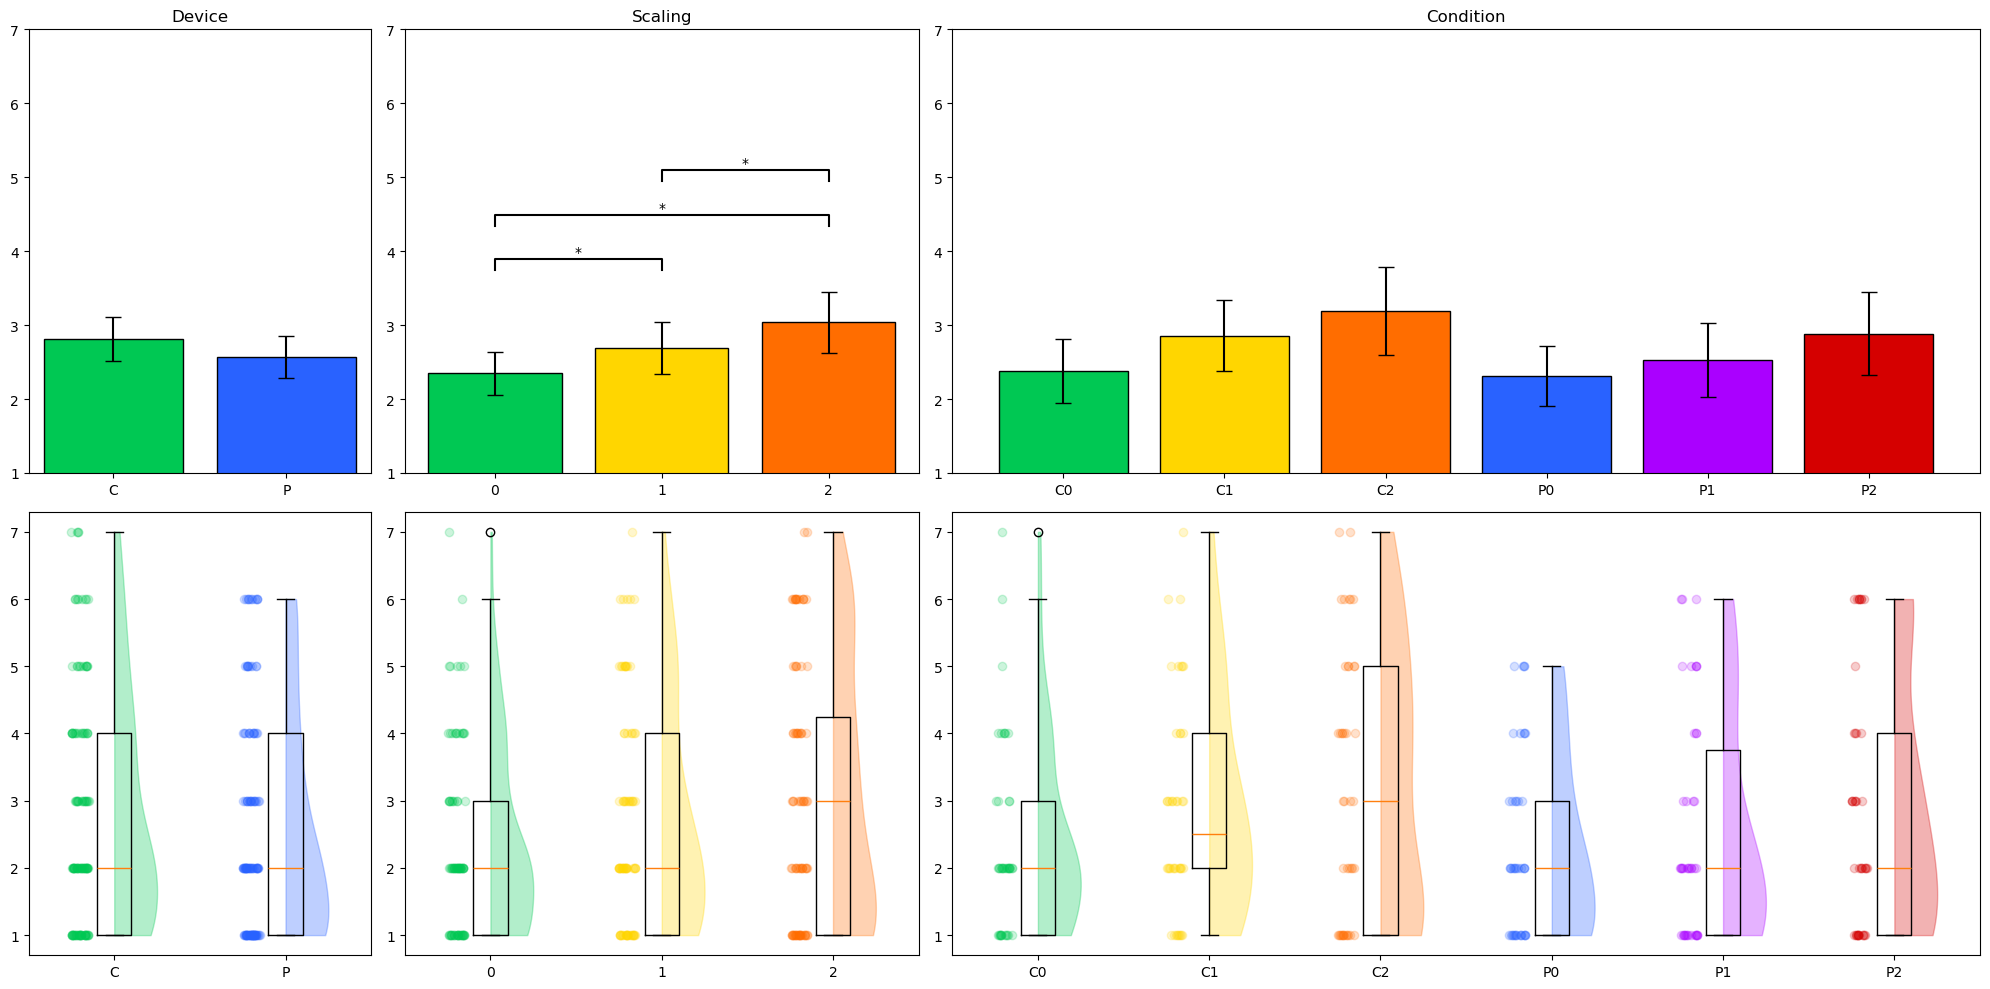

------ [Shovel] Dynamic Weight Perception ------
Mean & 2.14 & 2.45 & 2.67 & 2.4 & 2.35 & 2.62 \\
Standard Deviation & 1.3 & 1.49 & 1.73 & 1.37 & 1.46 & 1.65 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 5.5 & 5.5 & 7.0 & 5.5 & 6.0 & 7.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.080357,1,41,0.080357,0.057171,0.812216,0.812216,0.000140,1.000000,❌
1,Scaling,5.918651,2,82,2.959325,5.463614,0.005923,0.012352,0.010212,0.739790,✅
2,Device * Scaling,1.648810,2,82,0.824405,1.422648,0.246962,0.247456,0.002866,0.907945,❌


Device & (1, 41) & 0.06 & 0.812216 & 0.0001 \\
Scaling & (2, 82) & 5.46 & \textbf{0.012352} & 0.0102 \\
Device * Scaling & (2, 82) & 1.42 & 0.247456 & 0.0029 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.372598,41.0,two-sided,0.177339,0.177339,holm,0.398,-0.095782,❌
2,Scaling,-,0,2,True,True,-2.578316,41.0,two-sided,0.013618,0.040853,holm,3.08,-0.261269,✅
3,Scaling,-,1,2,True,True,-2.451821,41.0,two-sided,0.018562,0.040853,holm,2.371,-0.167558,✅


Scaling 1-0 & 41 & 1.37 & 0.177339 & 0.0958 \\
Scaling 2-0 & 41 & 2.58 & \textbf{0.040853} & 0.2613 \\
Scaling 2-1 & 41 & 2.45 & \textbf{0.040853} & 0.1676 \\


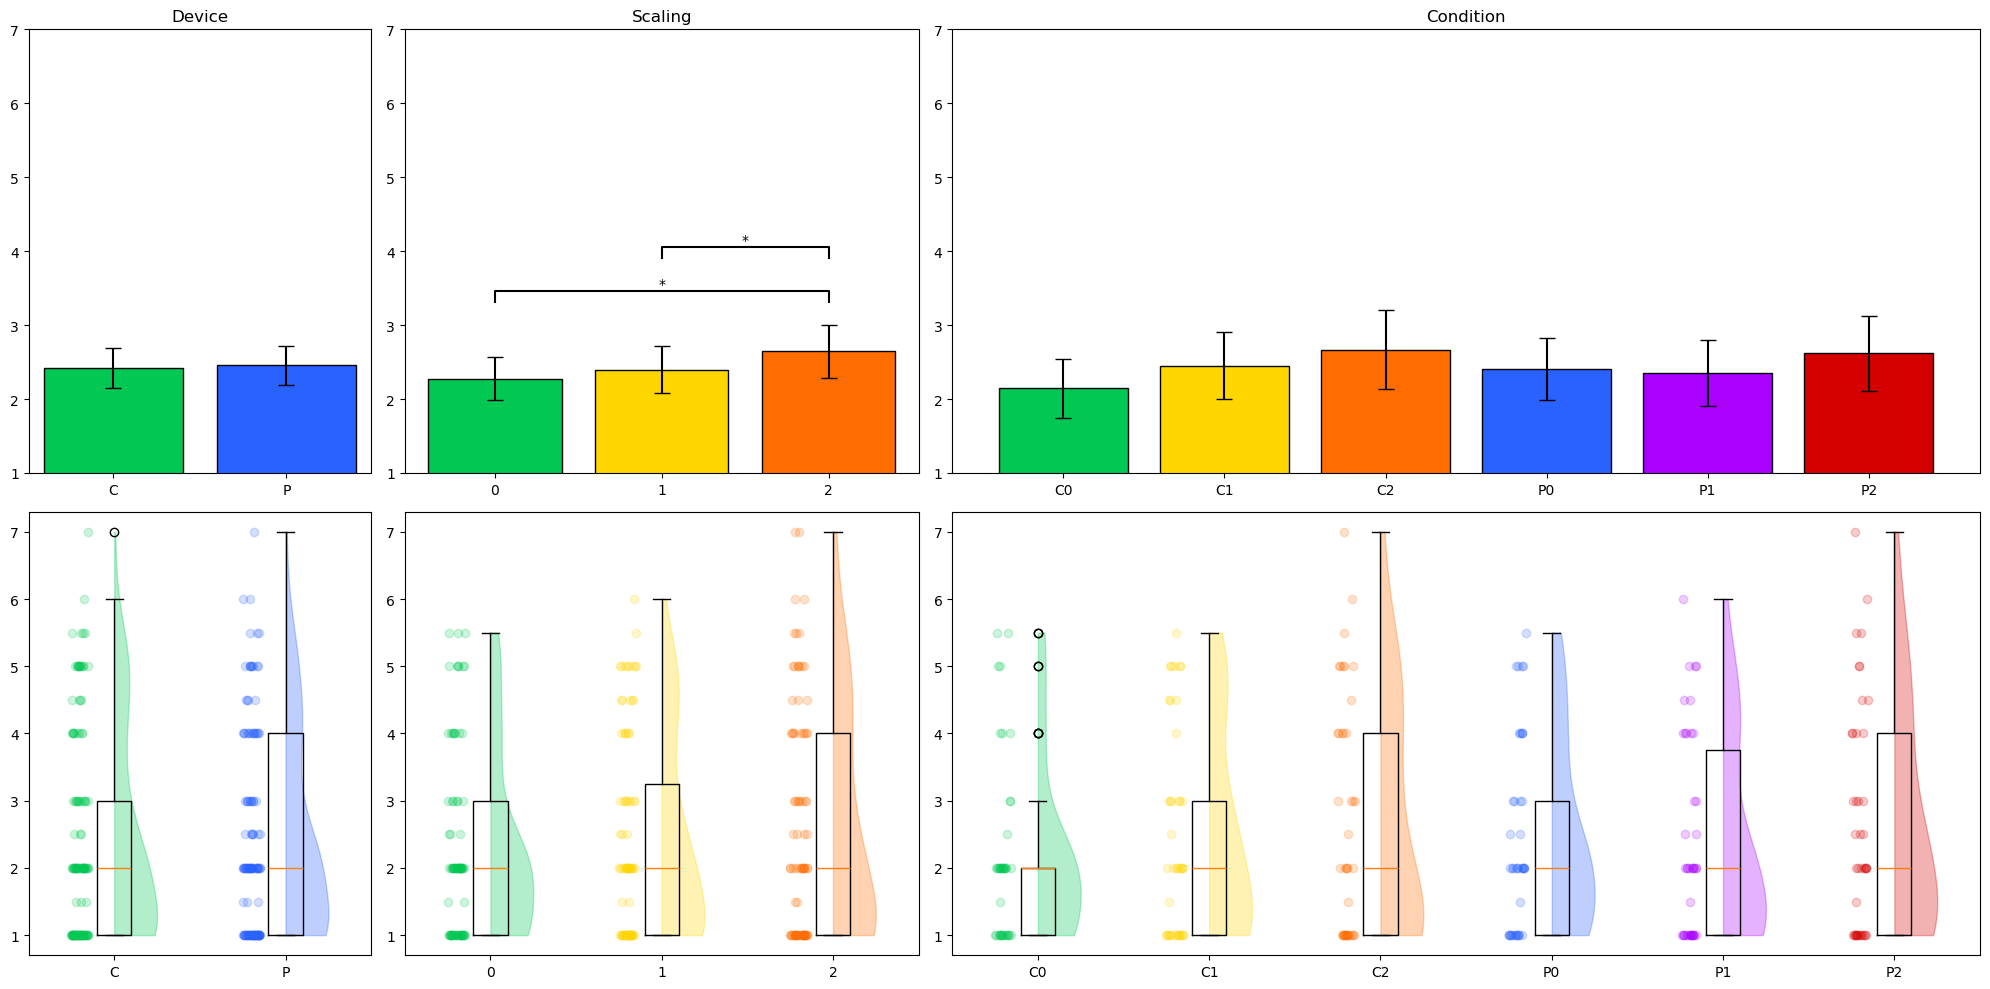

------ [Shovel] Dynamic Effort Perception ------
Mean & 2.38 & 2.87 & 3.19 & 2.32 & 2.58 & 2.94 \\
Standard Deviation & 1.45 & 1.7 & 1.92 & 1.3 & 1.65 & 1.88 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 7.0 & 7.0 & 7.0 & 5.0 & 6.0 & 6.5 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.480159,1,41,2.480159,1.009097,0.321011,0.321011,0.003536,1.000000,❌
1,Scaling,21.446429,2,82,10.723214,7.812312,0.000784,0.001810,0.029773,0.817496,✅
2,Device * Scaling,0.621032,2,82,0.310516,0.324861,0.723553,0.707788,0.000888,0.929458,❌


Device & (1, 41) & 1.01 & 0.321011 & 0.0035 \\
Scaling & (2, 82) & 7.81 & \textbf{0.00181} & 0.0298 \\
Device * Scaling & (2, 82) & 0.32 & 0.707788 & 0.0009 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.411059,41.0,two-sided,0.020472,0.040945,holm,2.184,-0.276119,✅
2,Scaling,-,0,2,True,True,-3.256996,41.0,two-sided,0.002264,0.006792,holm,14.578,-0.486003,✅
3,Scaling,-,1,2,True,True,-2.114084,41.0,two-sided,0.040635,0.040945,holm,1.24,-0.216691,✅


Scaling 1-0 & 41 & 2.41 & \textbf{0.040945} & 0.2761 \\
Scaling 2-0 & 41 & 3.26 & \textbf{0.006792} & 0.486 \\
Scaling 2-1 & 41 & 2.11 & \textbf{0.040945} & 0.2167 \\


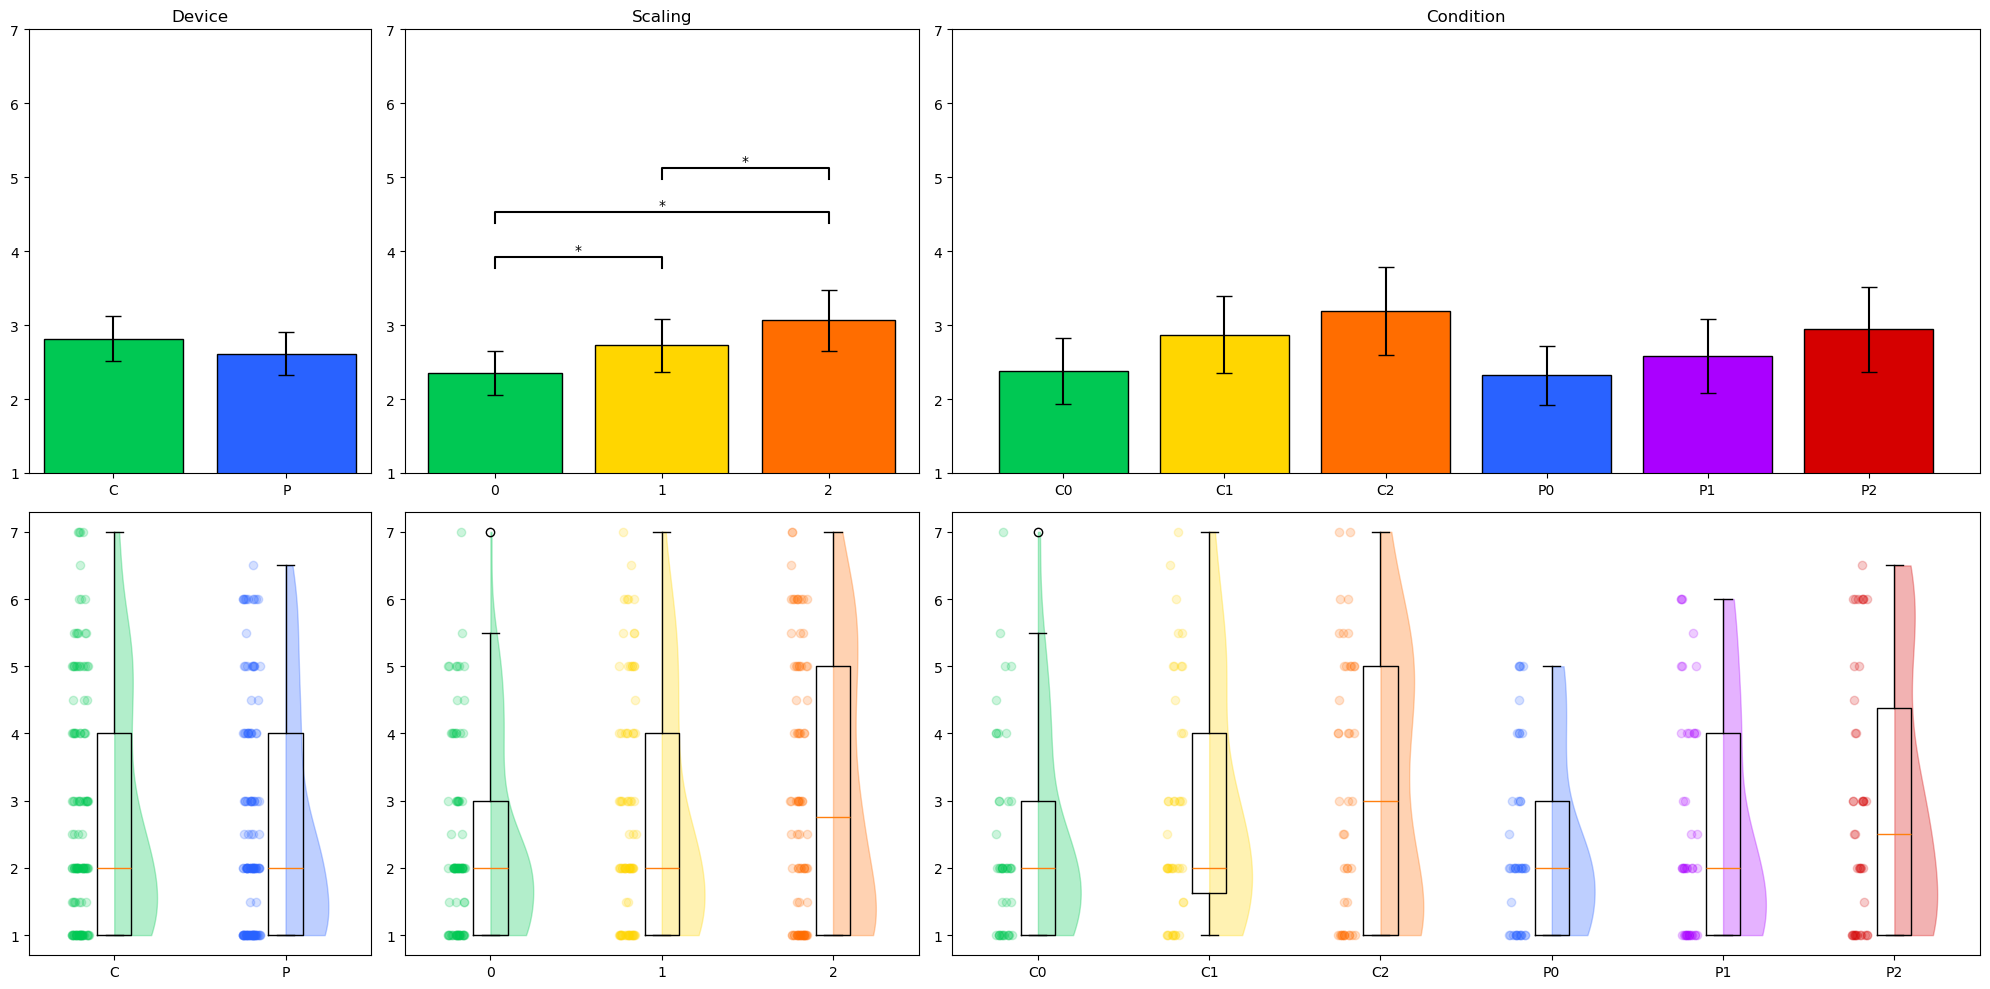

------ [Shovel] Dynamic Weight & Effort Perception ------
Mean & 2.26 & 2.66 & 2.93 & 2.36 & 2.46 & 2.78 \\
Standard Deviation & 1.26 & 1.43 & 1.65 & 1.29 & 1.48 & 1.67 \\
Minimum & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 & 1.0 \\
Maximum & 6.25 & 5.75 & 6.5 & 5.0 & 6.0 & 6.5 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.416915,1,41,0.416915,0.322204,0.573382,0.573382,0.000761,1.000000,❌
1,Scaling,12.347222,2,82,6.173611,8.699045,0.000375,0.001440,0.022045,0.743651,✅
2,Device * Scaling,1.073413,2,82,0.536706,0.806758,0.449813,0.441943,0.001956,0.928700,❌


Device & (1, 41) & 0.32 & 0.573382 & 0.0008 \\
Scaling & (2, 82) & 8.7 & \textbf{0.00144} & 0.022 \\
Device * Scaling & (2, 82) & 0.81 & 0.441943 & 0.002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.341811,41.0,two-sided,0.024129,0.025232,holm,1.904,-0.197624,✅
2,Scaling,-,0,2,True,True,-3.308891,41.0,two-sided,0.001958,0.005873,holm,16.573,-0.397598,✅
3,Scaling,-,1,2,True,True,-2.608999,41.0,two-sided,0.012616,0.025232,holm,3.286,-0.205661,✅


Scaling 1-0 & 41 & 2.34 & \textbf{0.025232} & 0.1976 \\
Scaling 2-0 & 41 & 3.31 & \textbf{0.005873} & 0.3976 \\
Scaling 2-1 & 41 & 2.61 & \textbf{0.025232} & 0.2057 \\


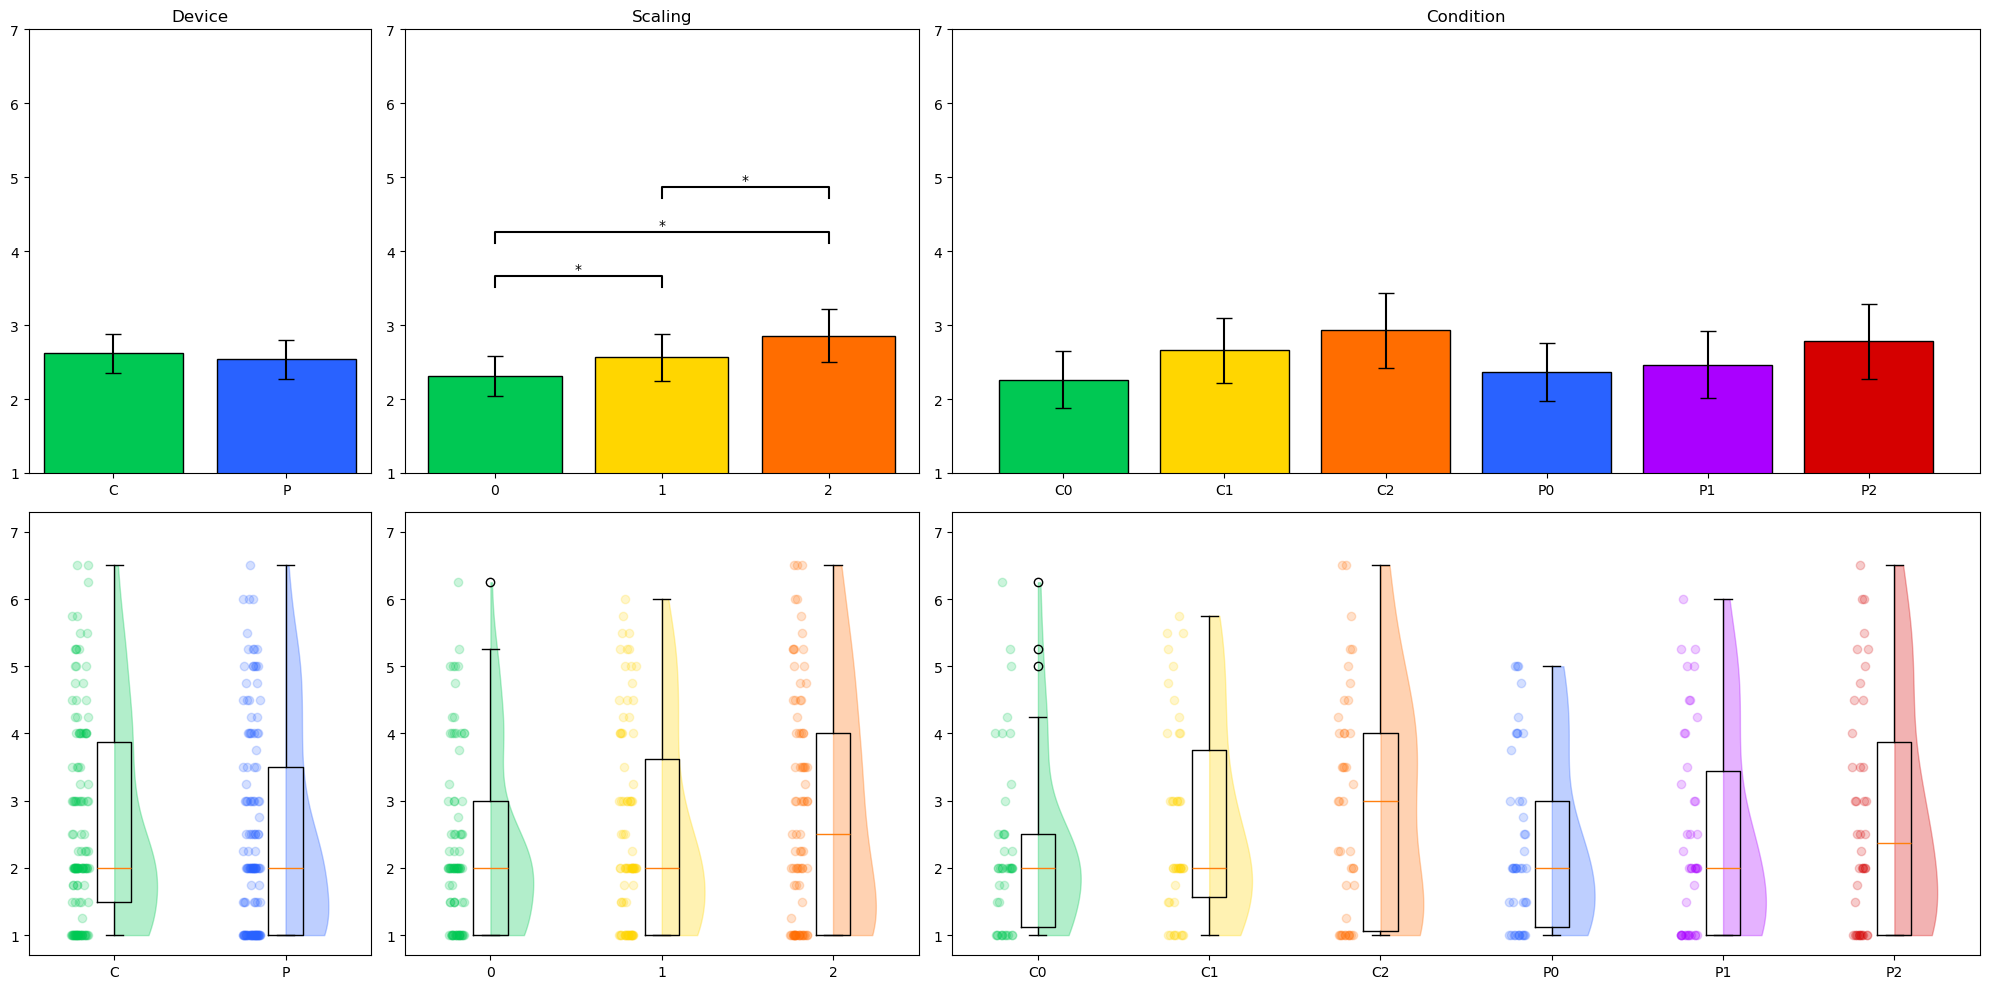

In [369]:
scale = [1,7]

shovel_load_weight = 'shovel_load_weight'
data[shovel_load_weight] = data[shovel_1]
load_weight_change = report_exeriment(data, shovel, shovel_load_weight, 'Perceived weight increase (Load)', scale)

shovel_unload_weight = 'shovel_unload_weight'
data[shovel_unload_weight] = data[shovel_2]
unload_weight_change = report_exeriment(data, shovel, shovel_unload_weight, 'Perceived weight decrease (Unload)', scale)

shovel_load_effort = 'shovel_load_effort'
data[shovel_load_effort] = data[shovel_3]
load_effort_change = report_exeriment(data, shovel, shovel_load_effort, 'Perceived effort increase (Load)', scale)

shovel_unload_effort = 'shovel_unload_effort'
data[shovel_unload_effort] = data[shovel_4]
unload_effort_change = report_exeriment(data, shovel, shovel_unload_effort, 'Perceived effort decrease (Unload)', scale)

dynamic_weight = 'dynamic_weight'
data[dynamic_weight] = data.apply(lambda x: 
    (x[shovel_load_weight] + x[shovel_unload_weight]) / 2,
    axis = 1)
dynamic_weight_change = report_exeriment(data, shovel, dynamic_weight, 'Dynamic Weight Perception', scale)

dynamic_effort = 'dynamic_effort'
data[dynamic_effort] = data.apply(lambda x: 
    (x[shovel_load_effort]+ x[shovel_unload_effort]) / 2,
    axis = 1)
dynamic_effort_change = report_exeriment(data, shovel, dynamic_effort, 'Dynamic Effort Perception', scale)


dynamic_combined = 'dynamic_combined'
data[dynamic_combined] = data.apply(lambda x: 
    (x[shovel_load_weight] + x[shovel_unload_weight]+ x[shovel_load_effort]+ x[shovel_unload_effort]) / 4,
    axis = 1)
dynamic_change = report_exeriment(data, shovel, dynamic_combined, 'Dynamic Weight & Effort Perception', scale)

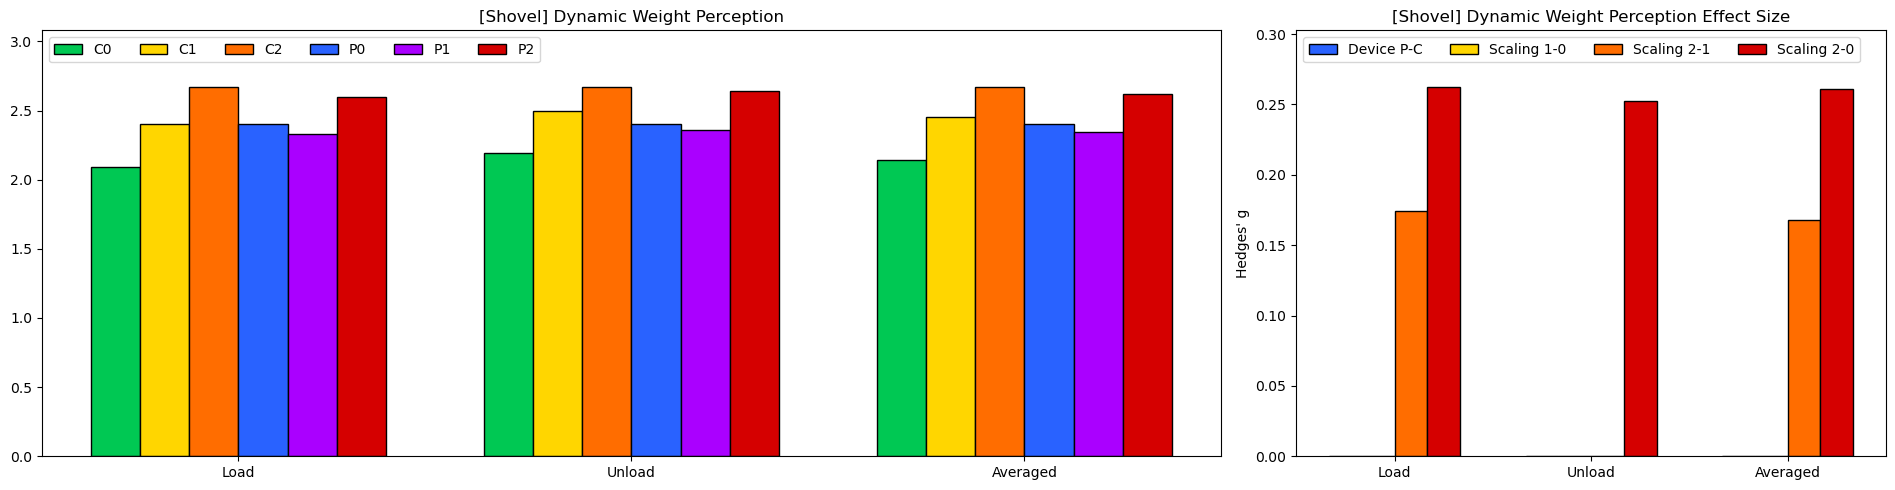

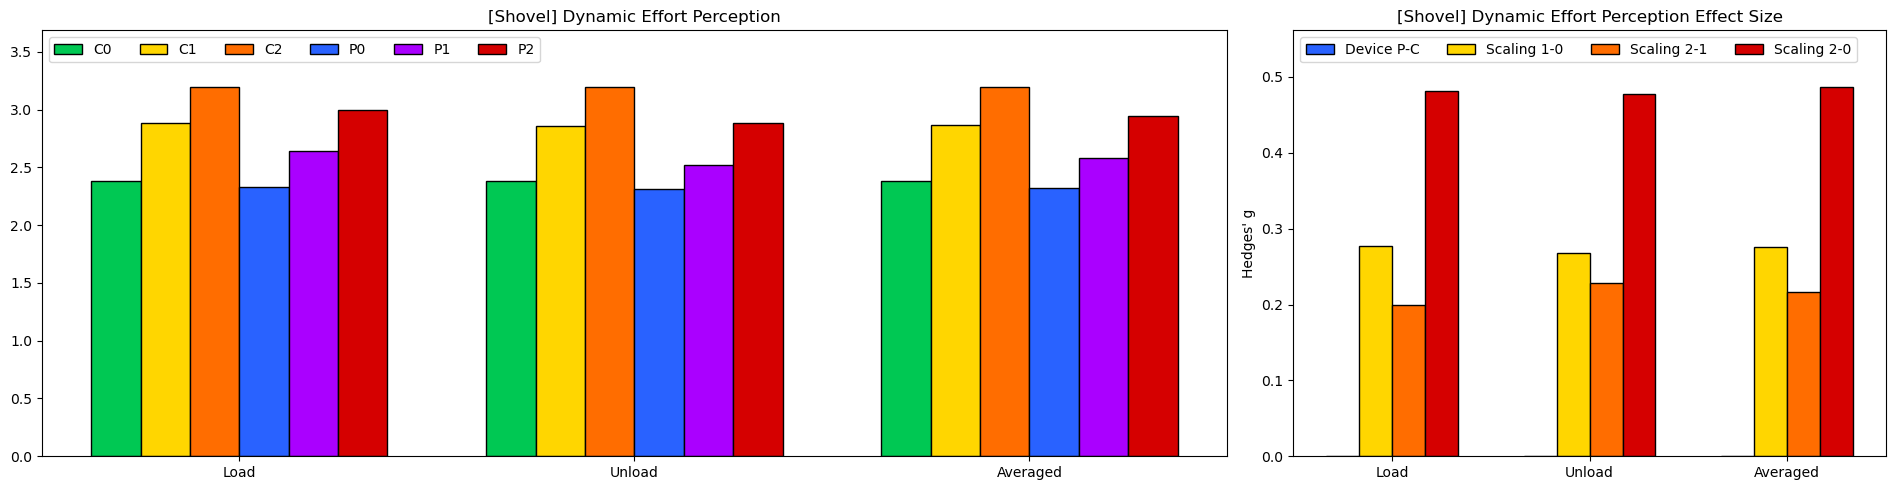

In [370]:
def get_dynamic_weight_splits(data, e):
    exp_data = data[data[task] == e]
    load = []
    unload = []
    total = []

    for c in conditions:
        condition_data = exp_data[exp_data[condition_key] == c]
        load.append(np.mean(condition_data[shovel_load_weight]))
        unload.append(np.mean(condition_data[shovel_unload_weight]))
        total.append(np.mean(condition_data[dynamic_weight]))

    return [load, unload, total]

def get_dynamic_effort_splits(data, e):
    exp_data = data[data[task] == e]
    load = []
    unload = []
    total = []

    for c in conditions:
        condition_data = exp_data[exp_data[condition_key] == c]
        load.append(np.mean(condition_data[shovel_load_effort]))
        unload.append(np.mean(condition_data[shovel_unload_effort]))
        total.append(np.mean(condition_data[dynamic_effort]))

    return [load, unload, total]

labels = ["Load", "Unload", "Averaged"]
ylabel = ''

weight_title = "[Shovel] Dynamic Weight Perception"
dynamic_weight_splits = get_dynamic_weight_splits(data, shovel)
dynamic_weight_aovs = [load_weight_change, unload_weight_change, dynamic_weight_change]
report_comparison(dynamic_weight_splits, dynamic_weight_aovs, labels, weight_title, ylabel)

effort_title = "[Shovel] Dynamic Effort Perception"
dynamic_effort_splits = get_dynamic_effort_splits(data, shovel)
dynamic_effort_aovs = [load_effort_change, unload_effort_change, dynamic_effort_change]
report_comparison(dynamic_effort_splits, dynamic_effort_aovs, labels, effort_title, ylabel)